# Rapport d'étude d'analyse de mesures qualitatives de reconstruction de vidéos - Tom LE BER (22308482) & Tony PEROTTINO (22303877)

In [ ]:
from getpass import getpass

# Raccourcis pour token Hugging Face :
    # Il faut avoir obtenu l'accès Hugging Face au modèle : facebook/sam-3d-body-dinov3
HUGGING_FACE_TOKEN = getpass("Token Hugging Face : ").strip()

# Raccourcis pour les importations vidéo :
IMPORT_TYPE = 0     # 0 = Depuis le GitHub.
VIDEO_GIT_INDEX = 1 # 1 = Première vidéo sur le GitHub.

Token Hugging Face : ··········


---

## I. Installation des bibliothèques

In [ ]:
import os
import sys

### 1. Télécharger NLF

#### A. Cloner le repo NLF (`https://github.com/isarandi/nlf.git`)

In [ ]:
NLF_DIR = "/content/nlf_repo"

# Cloner le repository (officiel) de NLF dans /content :
if not os.path.exists(NLF_DIR):
    !git clone https://github.com/isarandi/nlf.git "{NLF_DIR}"

Cloning into '/content/nlf_repo'...
remote: Enumerating objects: 304, done.
remote: Counting objects: 100% (52/52), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 304 (delta 32), reused 22 (delta 22), pack-reused 252 (from 1)
Receiving objects: 100% (304/304), 402.76 KiB | 10.60 MiB/s, done.
Resolving deltas: 100% (140/140), done.


#### B. Téléchargement du `TorchScript` associé

In [ ]:
%cd {NLF_DIR}

# Créer le dossier pour le modèle et télécharger le TorchScript :
!mkdir -p models
!wget -q -O models/nlf_l_multi.torchscript https://bit.ly/nlf_l_pt # Le lien pointe vers le modèle TorchScript NLF-L publié dans les releases du repo.

# On retourne dans "/content" à la fin de cette cellule (pour éviter des problèmes de chemins dans les prochaines cellules) :
%cd /content

/content/nlf_repo
/content


### 2. Télécharger `Segment Anything (V2)`

In [ ]:
SAM2_DIR = "/content/sam2_repo"

# Cloner le repository (officiel) de SAM2 dans /content :
if not os.path.exists(SAM2_DIR):
  !rm -rf "{SAM2_DIR}" 2>/dev/null
  !git clone https://github.com/facebookresearch/sam2.git "{SAM2_DIR}"

  !{sys.executable} -m pip uninstall -y -q SAM-2 sam-2 sam2 2>/dev/null
  !{sys.executable} -m pip install -q -e "{SAM2_DIR}" --config-settings editable_mode=compat

Cloning into '/content/sam2_repo'...
remote: Enumerating objects: 1096, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 1096 (delta 1), reused 0 (delta 0), pack-reused 1094 (from 2)
Receiving objects: 100% (1096/1096), 134.84 MiB | 18.84 MiB/s, done.
Resolving deltas: 100% (376/376), done.
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 16.9 MB/s eta 0:00:00
  Building editable for SAM-2 (pyproject.toml) ... done


### 3. Vérification de l'environnement

On importe `torch` et `torchvision` afin de vérifier s'il n'y a pas de conflits de versions à cause de `NLF` et `SAM 2`.

In [ ]:
import torch
import torchvision

print(f"torch = {torch.__version__}")
print(f"torchvision = {torchvision.__version__}")
print(f"cuda = {torch.cuda.is_available()}")
print(f"torch cuda = {torch.version.cuda}")

torch = 2.10.0+cu128
torchvision = 0.25.0+cu128
cuda = True
torch cuda = 12.8


---

## II. Chargement des données et import des bibliothèques

### 1. Montage du GitHub et extraction des images

#### A. Montage du GitHub

In [ ]:
GITHUB_REPOSITORY_DIR = "/content/stage-midl-2_repo"

# S'il n'a pas déjà été importé, clonage du dépôt GitHub :
if not os.path.exists(GITHUB_REPOSITORY_DIR):
    !git clone https://github.com/tominien/sports-digital-twin-irit-research-internship.git "{GITHUB_REPOSITORY_DIR}"

# Si le dépôt a déjà été importé, on le réinitialise et le met à jour :
else:
    !git -C "{GITHUB_REPOSITORY_DIR}" fetch --all
    !git -C "{GITHUB_REPOSITORY_DIR}" reset --hard origin/main
    !git -C "{GITHUB_REPOSITORY_DIR}" pull

Cloning into '/content/stage-midl-2_repo'...
remote: Enumerating objects: 1486, done.
remote: Total 1486 (delta 0), reused 0 (delta 0), pack-reused 1486 (from 2)
Receiving objects: 100% (1486/1486), 3.45 GiB | 13.81 MiB/s, done.
Resolving deltas: 100% (55/55), done.


#### B. Extraction des données et création des chemins

In [ ]:
WORKING_DIR = "/content/working_dir"

# Chemins de dossiers :
FRAMES_DIRECTORY  = os.path.join(WORKING_DIR, "frames")
MASKS_DIRECTORY   = os.path.join(WORKING_DIR, "masks")
RESULTS_DIRECTORY = os.path.join(WORKING_DIR, "results")

# Chemins de fichiers :
VIDEO_PATH          = os.path.join(WORKING_DIR, "video.mp4")
MASK_VIDEO_PATH     = os.path.join(WORKING_DIR, "video_masks.mp4")
NEW_BACKGROUND_PATH = os.path.join(WORKING_DIR, "new_background.png")
ANNOTATIONS_PATH    = os.path.join(WORKING_DIR, "annotations.csv")

In [ ]:
import glob
import gdown
import shutil
import subprocess
from PIL import Image
from google.colab import files, output

def download_file_from_drive(file_url : str, file_colab_path : str) -> bool:
    if "/folders/" in file_url:
        raise ValueError("Lien Google Drive détecté comme un dossier. Un lien de fichier est attendu.")

    # Téléchargement du fichier :
    res = gdown.download(url=file_url, output=file_colab_path, quiet=False, fuzzy=True)
    if not res or not os.path.exists(file_colab_path):
        raise ValueError("Téléchargement échoué (fichier introuvable ou inexistant).")

def create_default_background_from_video(video_path: str = VIDEO_PATH, new_background_path: str = NEW_BACKGROUND_PATH):
    """
    Crée une image blanche (PNG) aux dimensions de la vidéo originale.
    """
    if not os.path.isfile(video_path):
        raise ValueError(f"Vidéo source manquante.")

    # Récupération des dimensions de la vidéo :
    cmd = [
        "ffprobe", "-v", "error",
        "-select_streams", "v:0",
        "-show_entries", "stream=width,height",
        "-of", "csv=p=0:s=x",
        video_path
    ]
    try:
        dims = subprocess.check_output(cmd, text=True).strip()
        w_str, h_str = dims.split("x")
        w, h = int(w_str), int(h_str)
    except Exception as e:
        raise ValueError(f"Vidéo source indécoupable.")

    # Création du fond par défaut :
    os.makedirs(os.path.dirname(new_background_path), exist_ok=True)
    img = Image.new("RGB", (w, h), (255, 255, 255))
    img.save(new_background_path, format="PNG")

def load_resources_github(git_path : str = GITHUB_REPOSITORY_DIR, video_git_index : int = 1) -> bool:
    source_dir = os.path.join(git_path, "data", f"video_{video_git_index}")
    source_video = os.path.join(source_dir, "video.mp4")
    source_mask_video = os.path.join(source_dir, "video_masks.mp4")
    source_frames_zip = os.path.join(source_dir, "frames.zip")
    source_mask_zip = os.path.join(source_dir, "masks.zip")
    source_new_background_image = os.path.join(source_dir, "new_background.png")
    source_annotations = os.path.join(source_dir, "annotations.csv")

    warning_string = ""

    if os.path.exists(source_video):
        shutil.copy(source_video, VIDEO_PATH)
        print(f"Extraction des frames depuis : {source_video}")
        !ffmpeg -i "{source_video}" "{FRAMES_DIRECTORY}/%05d.png" -hide_banner -loglevel error -nostdin
    else:
        warning_string += f"\t- Video source introuvable a : {source_video}\n"

    if os.path.exists(source_frames_zip):
        print(f"Décompression des frames depuis : {source_frames_zip}")
        !unzip -jq "{source_frames_zip}" -d "{FRAMES_DIRECTORY}"
    else:
        warning_string += f"\t- Fichier frames.zip introuvable a : {source_frames_zip}\n"

    if os.path.exists(source_mask_zip):
        print(f"Décompression des masques depuis : {source_mask_zip}")
        !unzip -jq "{source_mask_zip}" -d "{MASKS_DIRECTORY}"
    else:
        warning_string += f"\t- Fichier masks.zip introuvable a : {source_mask_zip}\n"

    if os.path.exists(source_mask_video):
        shutil.copy(source_mask_video, MASK_VIDEO_PATH)
        print(f"Extraction des frames de masques depuis : {source_mask_video}")
        !ffmpeg -i "{source_mask_video}" "{MASKS_DIRECTORY}/%05d.png" -hide_banner -loglevel error -nostdin
    else:
        warning_string += f"\t- Video de masque introuvable : {source_mask_video}\n"

    if os.path.exists(source_new_background_image):
        shutil.copy(source_new_background_image, NEW_BACKGROUND_PATH)
        print(f"Nouvelle image de fond copiée vers : {NEW_BACKGROUND_PATH}.")
    else:
        create_default_background_from_video()
        warning_string += f"\t- Nouveau fond introuvable : {source_new_background_image}\n"

    if os.path.exists(source_annotations):
        shutil.copy(source_annotations, ANNOTATIONS_PATH)
        print(f"Fichier csv d'annotations copié dans : {ANNOTATIONS_PATH}.")
    else:
        warning_string += f"\t- Fichier csv d'annotations introuvable : {source_annotations}\n"

    if len(warning_string) > 0:
        print("WARNING éléments manquants dans le git :\n" + warning_string)
    else:
        print("Toutes les ressources Git ont été récupérées avec succes.")

    return True

def load_resources_local() -> bool:
    print(f"\nChoisissez la vidéo d'entrée (.mp4) :")
    uploaded_orig = files.upload()
    if uploaded_orig:
        temp_file = list(uploaded_orig.keys())[0]
        shutil.copy(temp_file, VIDEO_PATH)
        os.remove(temp_file)
        output.clear()

    print(f"\nChoisissez la vidéo des masques sur fond noir (si elle existe) :")
    uploaded_mask = files.upload()
    if uploaded_mask:
        temp_mask = list(uploaded_mask.keys())[0]
        shutil.copy(temp_mask, MASK_VIDEO_PATH)
        os.remove(temp_mask)
        output.clear()

    print(f"\nChoisissez le nouveau fond (.png) (si vous en avez un) :")
    uploaded_bg = files.upload()
    if uploaded_bg:
        temp_bg = list(uploaded_bg.keys())[0]
        shutil.copy(temp_bg, NEW_BACKGROUND_PATH)
        os.remove(temp_bg)
        output.clear()
    else:
        create_default_background_from_video()

    return True

def load_resources_drive(original_video_url : str, masks_video_url : str, new_background : str) -> bool:
    print("") # Formattage de l'affichage.

    # Téléchargement de la vidéo originale :
    download_file_from_drive(original_video_url, VIDEO_PATH)

    # Téléchargement de la vidéo des masques :
    if masks_video_url != "":
        download_file_from_drive(masks_video_url, MASK_VIDEO_PATH)

    # Téléchargement du nouveau fond :
    if new_background != "":
        download_file_from_drive(new_background, NEW_BACKGROUND_PATH)
    else:
        create_default_background_from_video()


    print("") # Formattage de l'affichage.
    return True

def load_resources(working_dir : str = WORKING_DIR, import_type : int = 0) -> bool:
    # 1. VÉRIFICATION DE L'OPERATION EN COURS (suppression du dossier de travail actuel s'il n'est pas vide) :
    if os.path.exists(working_dir) and os.listdir(working_dir):
        print(f"\nAttention : Le dossier '{working_dir}' n'est pas vide et va être effacé (sauvegardez vos résultat AVANT de continuer).")
        if input(f"Voulez-vous continuer ? (y/n) : ").strip().lower() != 'y':
            print("Opération annulée par l'utilisateur.")
            return False
        shutil.rmtree(working_dir)

    # 2. INITIALISATION DES DOSSIERS DE TRAVAIL :
    for folder in [FRAMES_DIRECTORY, MASKS_DIRECTORY, RESULTS_DIRECTORY]:
        os.makedirs(folder, exist_ok=True)

    # 3. EXTRACTION DES DONNEES :
    match import_type:
         # Import de vidéo depuis GitHub :
        case 0:
            try:
                if not isinstance(VIDEO_GIT_INDEX, int):
                    raise TypeError("VIDEO_GIT_INDEX doit être un entier")
                video_git_index = VIDEO_GIT_INDEX

            except (NameError, TypeError, ValueError):
                video_git_index = int(input("\nIndice de la vidéo dans le dossier 'data' sur GitHub : "))

            return load_resources_github(video_git_index = video_git_index)

        # Import de vidéo en local :
        case 1:
            return load_resources_local()

        # Import de vidéo depuis Google Drive :
        case 2:
            video_url = input("\nLien de téléchargement de la vidéo originale sur Google Drive : ")
            video_masks_url = input("\nLien de téléchargement de la vidéo des masques sur Google Drive (optionnel) : ").strip()
            new_background = input("\nLien de téléchargement du nouveau fond sur Google Drive (optionnel) : ").strip()
            return load_resources_drive(video_url, video_masks_url, new_background)

        case _:
            print(f"Type d'import '{import_type}' inconnu.")
            return False

In [ ]:
# CHARGEMENT :
try:
    if not isinstance(IMPORT_TYPE, int):
        raise TypeError("IMPORT_TYPE doit être un entier")
    import_type = IMPORT_TYPE

except (NameError, TypeError, ValueError):
    import_type = int(input("Entrez le type de la vidéo étudiée :\n\t0 = Upload depuis GitHub\n\t1 = Upload en local (depuis l'explorateur)\n\t2 = Upload depuis un lien Google Drive\n"))

success = load_resources(WORKING_DIR, import_type)

if success:
    print(f"\nDossier de travail prêt : {WORKING_DIR}")

Extraction des frames depuis : /content/stage-midl-2_repo/data/video_1/video.mp4
Décompression des masques depuis : /content/stage-midl-2_repo/data/video_1/masks.zip
Extraction des frames de masques depuis : /content/stage-midl-2_repo/data/video_1/video_masks.mp4
Nouvelle image de fond copiée vers : /content/working_dir/new_background.png.
Fichier csv d'annotations copié dans : /content/working_dir/annotations.csv.
WARNING éléments manquants dans le git :
	- Fichier frames.zip introuvable a : /content/stage-midl-2_repo/data/video_1/frames.zip


Dossier de travail prêt : /content/working_dir


#### C. Extraction en frames de la vidéo

Le code ci-dessous éxtrait chaque frame de la vidéo originale (et de la vidéo des masques si fournie), si leurs dossiers respectifs sont vides.

In [ ]:
# Extraire toutes les frames de la vidéo originale si le dossier (des frames) est vide :
if os.path.isdir(FRAMES_DIRECTORY):
    # Suppression de l'ancien contenu du dossier :
    shutil.rmtree(FRAMES_DIRECTORY, ignore_errors=True)
    os.makedirs(FRAMES_DIRECTORY, exist_ok=True)
    # Remplissage du dossier avec les nouvelles frames :
    !ffmpeg -i "{VIDEO_PATH}" -start_number 0 "{FRAMES_DIRECTORY}/%05d.png" -hide_banner -loglevel error

# Extraire toutes les frames de la vidéo des masques (si présente et) si le dossier (des frames) est vide :
if os.path.isdir(MASKS_DIRECTORY):
    # Suppression de l'ancien contenu du dossier :
    shutil.rmtree(MASKS_DIRECTORY, ignore_errors=True)
    os.makedirs(MASKS_DIRECTORY, exist_ok=True)
    # Remplissage du dossier avec les nouvelles frames :
    if os.path.isfile(MASK_VIDEO_PATH):
        !ffmpeg -i "{MASK_VIDEO_PATH}" -start_number 0 "{MASKS_DIRECTORY}/%05d.png" -hide_banner -loglevel error

### 2. Import de `NLF`

Dans cette partie, nous appliquons le modèle NLF à la vidéo de pole-dance.  
L’objectif est de :
1. Charger le modèle NLF (version TorchScript) sur GPU.
2. Définir une fonction d’inférence sur une image unique (frame).
3. Appliquer NLF à un sous-ensemble de frames de la vidéo.
4. Visualiser et analyser qualitativement les prédictions (joints 2D et 3D).

Ensuite, chargeons la version TorchScript du modèle NLF (`nlf_l_multi.torchscript`), qui a été téléchargée dans le dossier `/content/nlf/models/` depuis les Releases du dépôt GitHub.

#### A. Initialisation des paramètres

In [ ]:
import glob
import numpy as np

# Paramètres d'expérience pour NLF :
MAX_FRAMES = 5000 # Nombre maximum de frames à traiter (pour l'étude).
FRAME_STEP = 1 # 1 = toutes les frames, 2 = une frame sur deux, etc.

# FRAMES_DIRECTORY et BASE_DIRECTORY sont supposés définis dans la partie précédente :
frame_paths_all = sorted(glob.glob(os.path.join(FRAMES_DIRECTORY, "*.png")))

# Sous-échantillonnage éventuel (step et nombre de frames maximum) :
frame_paths = frame_paths_all[::FRAME_STEP]
frame_paths = frame_paths[:MAX_FRAMES]

print(f"Nombre total de frames extraites : {len(frame_paths_all)}")
print(f"Nombre de frames utilisées pour NLF : {len(frame_paths)}")

Nombre total de frames extraites : 1329
Nombre de frames utilisées pour NLF : 1329


#### B. Chargement du modèle

In [ ]:
from tqdm.auto import tqdm

%cd {NLF_DIR}

# Sélection du "device" :
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", device)

# Chemin vers le modèle TorchScript (doit déjà avoir été téléchargé) :
NLF_MODEL_PATH = "models/nlf_l_multi.torchscript"

# Chargement du modèle :
model = torch.jit.load(NLF_MODEL_PATH, map_location=device).eval()
print("Modèle NLF chargé avec succès.")

# On retourne dans "/content" à la fin de cette cellule (pour éviter des problèmes de chemins dans les prochaines cellules) :
%cd /content

/content/nlf_repo
Device utilisé : cuda
Modèle NLF chargé avec succès.
/content


### 3. Setup de `Segment Anything (V2)`

#### A. Importation de `SAM 2`

In [ ]:
# Ajout de SAM2 comme "bibliothèque lisible" pour Python :
if SAM2_DIR not in sys.path:
    sys.path.insert(0, SAM2_DIR)
sys.modules.pop("sam2", None)

# Test des imports :
from sam2.sam2_image_predictor import SAM2ImagePredictor
from sam2.sam2_video_predictor import SAM2VideoPredictor
print(f"Imports de SAM 2 fonctionnels.") # Si on n'a pas le print, c'est qu'on a eu une erreur avant.

Imports de SAM 2 fonctionnels.


#### B. Téléchargement des poids du modèle `SAM 2.1` (`Base Plus`)

In [ ]:
CKPT_DIR = f"{SAM2_DIR}/checkpoints"
SAM2_MODEL_URL = "https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_base_plus.pt"

!mkdir -p "{CKPT_DIR}"
!wget -q --show-progress -nc -P "{CKPT_DIR}/" "{SAM2_MODEL_URL}"

sam2.1_hiera_base_p 100%[===================>] 308.62M   130MB/s    in 2.4s    


---

## III. Exécution de `NLF`

### 1. Détection d'une personne dans une frame donnée

Nous définissons une fonction `run_nlf_on_image(img_path)` qui :
1. Charge une image de frame depuis son chemin.
2. La met au bon format pour NLF (batch de taille 1).
3. Appelle `model.detect_smpl_batched(...)`.
4. Récupère les joints 2D et 3D pour **la première personne** détectée.
5. Retourne un dictionnaire Python sérialisable (listes plutôt que tenseurs).

Nous considérons qu’il n’y a qu’une seule personne (la pole-danseuse) dans la scène.

In [ ]:
def run_nlf_on_image(img_path: str):
    """
    Applique NLF à une image unique.
    Retourne un dictionnaire contenant :
      - frame : nom de fichier de la frame,
      - has_person : booléen indiquant si une personne a été détectée,
      - joints2d : liste [J, 2] des coordonnées 2D des joints (en pixels),
      - joints3d : liste [J, 3] des coordonnées 3D des joints (repère caméra).
    """
    # Charger l'image (C,H,W), uint8 :
    image = torchvision.io.read_image(img_path).to(device)

    # Ajouter la dimension batch : [1, C, H, W]
    frame_batch = image.unsqueeze(0)

    # Inférence NLF :
    with torch.inference_mode():
        pred = model.detect_smpl_batched(frame_batch)

    # pred["joints2d"] et pred["joints3d"] sont des listes (une entrée par élément du batch) :
    joints2d_batch = pred["joints2d"][0]
    joints3d_batch = pred["joints3d"][0]

    # Si le modèle renvoie [num_persons, J, 2] ou [num_persons, J, 3] :
    if joints2d_batch.ndim == 3:
        # Si aucune personne détectée :
        if joints2d_batch.shape[0] == 0:
            return {
                "frame": os.path.basename(img_path),
                "has_person": False,
                "joints2d": None,
                "joints3d": None,
            }
        # On prend la première personne :
        j2d = joints2d_batch[0] # [J, 2]
        j3d = joints3d_batch[0] # [J, 3]
    else:
        # Cas où le modèle renvoie directement [J, 2] / [J, 3] :
        j2d = joints2d_batch
        j3d = joints3d_batch

    # Conversion en numpy, puis en listes Python :
    j2d_np = j2d.detach().cpu().numpy()
    j3d_np = j3d.detach().cpu().numpy()

    result = {
        "frame": os.path.basename(img_path),
        "has_person": True,
        "joints2d": j2d_np.tolist(), # [J, 2]
        "joints3d": j3d_np.tolist(), # [J, 3]
    }
    return result

### 2. Inférence sur un lot de frames

Nous appliquons maintenant `run_nlf_on_image` à un sous-ensemble de frames :
- Les chemins de frames sont définis dans la cellule de paramètres (`frame_paths`).
- Nous mesurons le **temps d'inférence** par frame.
- Nous stockons les résultats dans une liste `results`, chaque entrée correspondant à une frame.

À la fin, nous sauvegardons les résultats dans un fichier JSON situé dans `BASE_DIRECTORY`.

In [ ]:
import time
import json
import glob

results = []
times = []

print(f"Lancement de NLF sur {len(frame_paths)} frames.")

for img_path in tqdm(frame_paths, desc="NLF inference"):
    t0 = time.perf_counter()
    res = run_nlf_on_image(img_path)
    t1 = time.perf_counter()

    res["infer_time"] = t1 - t0 # Temps pour cette frame.
    results.append(res)
    times.append(t1 - t0)

times = np.array(times)

print(f"Nombre total de résultats : {len(results)}")
print(f"Temps moyen par frame : {times.mean()*1000:.1f} ms")
print(f"FPS approximatif : {1.0 / times.mean():.2f}")

# Sauvegarde des résultats dans un JSON :
output_path = os.path.join(RESULTS_DIRECTORY, "nlf_results.json")
with open(output_path, "w") as f:
    json.dump(results, f, indent=4)

print(f"Résultats sauvegardés dans : {output_path}")

Lancement de NLF sur 1329 frames.


NLF inference:   0%|          | 0/1329 [00:00<?, ?it/s]

Nombre total de résultats : 1329
Temps moyen par frame : 227.2 ms
FPS approximatif : 4.40
Résultats sauvegardés dans : /content/working_dir/results/nlf_results.json


### 3. Visualisation qualitative de NLF

Nous proposons plusieurs visualisations :
1. **Overlay 2D des joints sur une frame** (qualité instantanée de la pose).
2. **Mosaïque de plusieurs frames** avec leurs joints 2D.
3. **Évolution temporelle de la profondeur (Z) d’un joint donné**.
4. **Visualisation 3D d’une pose** à partir de `joints3d`.

Ces visualisations serviront de base à l’analyse qualitative de NLF dans la section suivante.

In [ ]:
import matplotlib.pyplot as plt

# Filtrer uniquement les frames où une personne a été détectée :
valid_results = [r for r in results if r["has_person"]]

print(f"Frames avec personne détectée : {len(valid_results)}")

if len(valid_results) == 0:
    raise ValueError("Aucune personne détectée dans les frames sélectionnées.")

Frames avec personne détectée : 1264


#### A. Overlay 2D sur une frame

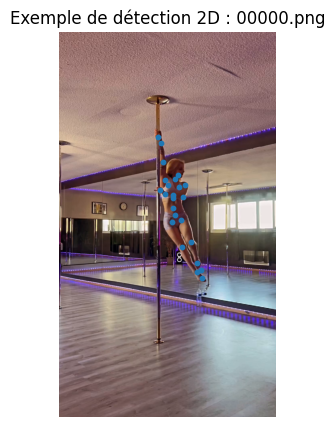

In [ ]:
# On prend un exemple (la première) :
sample = valid_results[0]
frame_name = sample["frame"]
j2d = np.array(sample["joints2d"]) # [J, 2]

img_path = os.path.join(FRAMES_DIRECTORY, frame_name)
img = torchvision.io.read_image(img_path).permute(1, 2, 0).cpu().numpy() # [H,W,C]

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.scatter(j2d[:, 0], j2d[:, 1], s=10)
plt.title(f"Exemple de détection 2D : {frame_name}")
plt.axis("off")
plt.show()

#### B. Mosaïque de plusieurs frames avec joints 2D

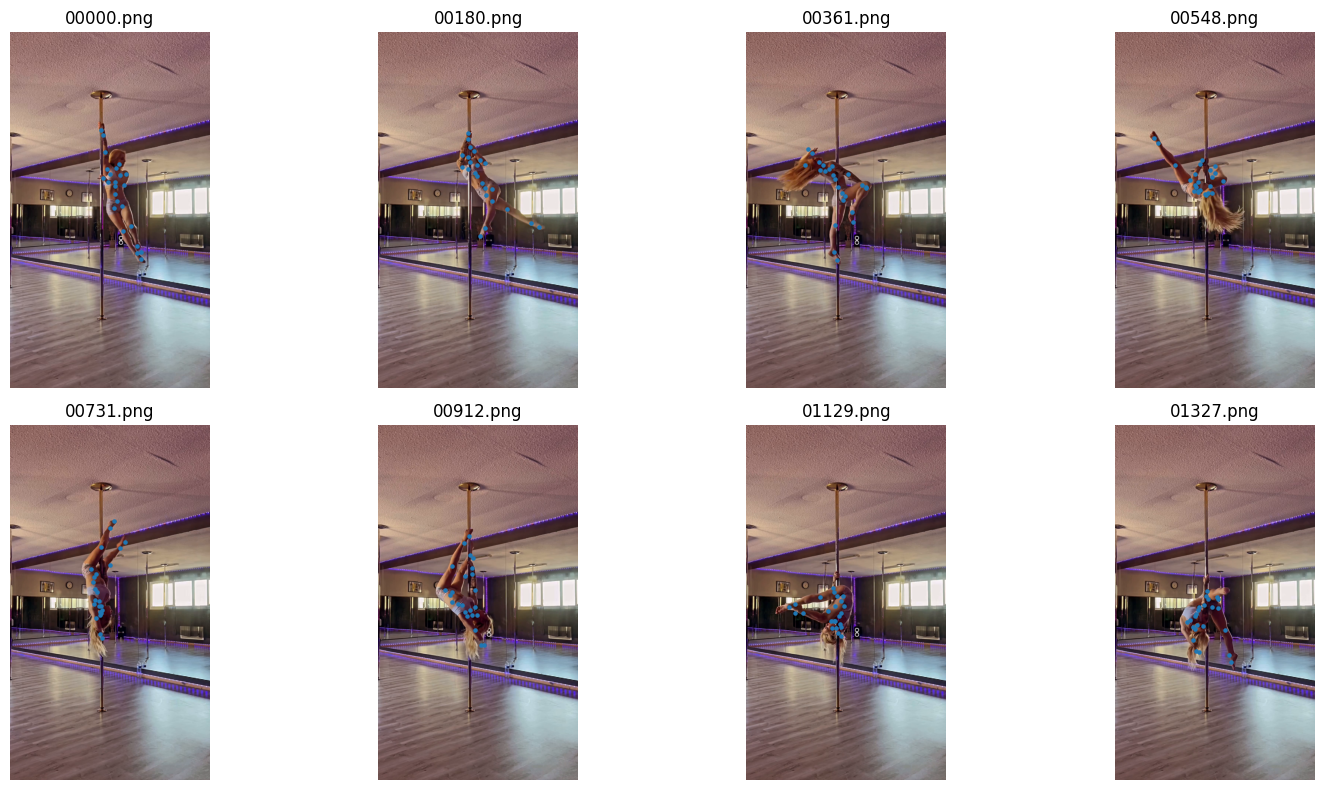

In [ ]:
# Nombre d'exemples à afficher dans la mosaïque :
num_examples = min(8, len(valid_results))

# On prend des indices uniformément répartis dans la séquence des frames :
indices = np.linspace(0, len(valid_results) - 1, num_examples, dtype=int)

cols = 4
rows = int(np.ceil(num_examples / cols))

plt.figure(figsize=(4 * cols, 4 * rows))

for i, idx in enumerate(indices, start=1):
    res = valid_results[idx]
    frame_name = res["frame"]
    j2d = np.array(res["joints2d"])

    img_path = os.path.join(FRAMES_DIRECTORY, frame_name)
    img = torchvision.io.read_image(img_path).permute(1, 2, 0).cpu().numpy()

    ax = plt.subplot(rows, cols, i)
    ax.imshow(img)
    ax.scatter(j2d[:, 0], j2d[:, 1], s=5)
    ax.set_title(frame_name)
    ax.axis("off")

plt.tight_layout()
plt.show()

#### C. Évolution de la profondeur Z d’un joint

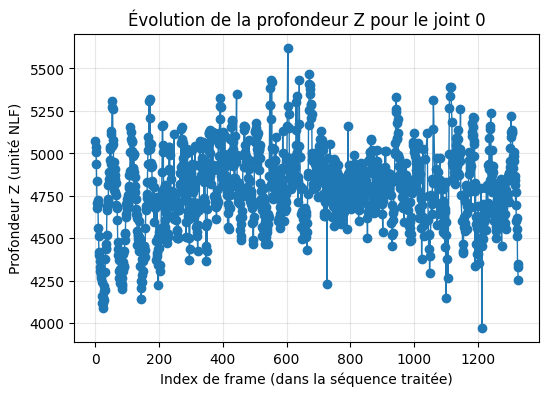

In [ ]:
# Indice du joint étudié :
JOINT_INDEX = 0 # 0 = tête.

z_vals = []
frames_idx = []

for i, res in enumerate(results):
    if not res["has_person"]:
        continue
    j3d = np.array(res["joints3d"]) # [J, 3]
    if j3d.shape[0] <= JOINT_INDEX:
        continue
    z_vals.append(j3d[JOINT_INDEX, 2])
    frames_idx.append(i)

plt.figure(figsize=(6, 4))
plt.plot(frames_idx, z_vals, marker="o", linestyle="-", linewidth=1)
plt.xlabel("Index de frame (dans la séquence traitée)")
plt.ylabel("Profondeur Z (unité NLF)")
plt.title(f"Évolution de la profondeur Z pour le joint {JOINT_INDEX}")
plt.grid(True, alpha=0.3)
plt.show()

#### D. Visualisation 3D d’une pose

Frames avec personne détectée : 1264


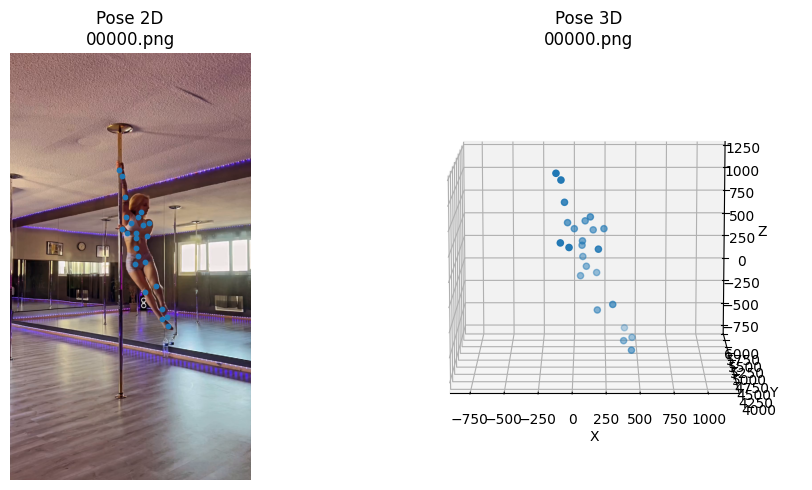

In [ ]:
from mpl_toolkits.mplot3d import Axes3D  # Affichage 3D.

# On vérifie qu'on a bien des résultats valides :
valid_results = [r for r in results if r["has_person"]]
print(f"Frames avec personne détectée : {len(valid_results)}")

if len(valid_results) == 0:
    raise ValueError("Aucune personne détectée dans les frames sélectionnées.")

# Choix de l'index de frame à visualiser :
FRAME_INDEX_FOR_3D_VIEW = 0

sample = valid_results[FRAME_INDEX_FOR_3D_VIEW]
frame_name = sample["frame"]
j2d = np.array(sample["joints2d"]) # [J, 2]
j3d = np.array(sample["joints3d"]) # [J, 3]

# Chargement de l'image correspondante :
img_path = os.path.join(FRAMES_DIRECTORY, frame_name)
img = torchvision.io.read_image(img_path).permute(1, 2, 0).cpu().numpy() # [H,W,C]

# Remapping des axes pour que la pose 3D "colle" mieux à l'image :
    # X_vis : gauche/droite
    # Y_vis : profondeur (distance caméra)
    # Z_vis : hauteur (haut/bas) -> on prend -Y pour que le haut soit "vers le haut"
X_vis = j3d[:, 0]
Y_vis = j3d[:, 2]
Z_vis = -j3d[:, 1]

# Petite fonction pour avoir des axes isotropes (squelette non écrasé) :
def set_axes_equal(ax):
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()

    x_range = abs(x_limits[1] - x_limits[0])
    y_range = abs(y_limits[1] - y_limits[0])
    z_range = abs(z_limits[1] - z_limits[0])

    max_range = max([x_range, y_range, z_range]) / 2.0

    mid_x = np.mean(x_limits)
    mid_y = np.mean(y_limits)
    mid_z = np.mean(z_limits)

    ax.set_xlim3d([mid_x - max_range, mid_x + max_range])
    ax.set_ylim3d([mid_y - max_range, mid_y + max_range])
    ax.set_zlim3d([mid_z - max_range, mid_z + max_range])

# Affichage des figures combinées en 2 colonnes :
fig = plt.figure(figsize=(10, 5))
    # Figure 1 (image + joints 2D) :
ax1 = fig.add_subplot(1, 2, 1)
ax1.imshow(img)
ax1.scatter(j2d[:, 0], j2d[:, 1], s=10)
ax1.set_title(f"Pose 2D\n{frame_name}")
ax1.axis("off")
    # Figure 2 (visualisation 3D) :
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.scatter(X_vis, Y_vis, Z_vis)
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.set_zlabel("Z")
ax2.set_title(f"Pose 3D\n{frame_name}")
ax2.view_init(elev=10, azim=-90) # Vue "de face" pour que ça ressemble à la projection de l'image.
ax2.grid(True, alpha=0.3) # Grille moins prononcée.
set_axes_equal(ax2)

plt.tight_layout()
plt.show()

---

## IV. Exécution de `Segment Anything (V2)`

### 1. Création de calques de la danseuse pour une frame unique

Image de test : /content/working_dir/frames/00000.png
BBox depuis NLF: [ 468.49119873  454.66991577  731.81385498 1297.60187378]


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


sam2.1_hiera_base_plus.pt:   0%|          | 0.00/324M [00:00<?, ?B/s]

scores: [0.96484375 0.8515625  0.95703125] best: 0.96484375


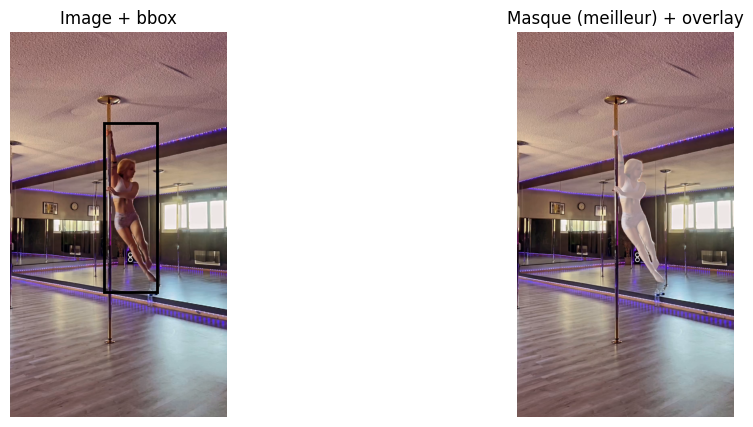

In [ ]:
import cv2
import glob

# Choix d'un modèle :
SAM2_MODEL_ID = "facebook/sam2.1-hiera-base-plus" # Bon compromis vitesse/qualité (checkpoints SAM2.1).

# (1) choisir une image (on prend la première valide) :
if "FRAMES_DIRECTORY" in globals():
    candidates = sorted(glob.glob(os.path.join(FRAMES_DIRECTORY, "*.png")) + glob.glob(os.path.join(FRAMES_DIRECTORY, "*.jpg")))
else:
    candidates = sorted(glob.glob("/content/*.png") + glob.glob("/content/*.jpg"))

test_img_path = candidates[0]
print(f"Image de test : {test_img_path}")

bgr = cv2.imread(test_img_path)
assert bgr is not None, "Impossible de lire l'image."
img = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
H, W = img.shape[:2]

# (2) bbox depuis NLF si possible (sinon fallback) :
bbox = None
if "run_nlf_on_image" in globals():
    try:
        pred = run_nlf_on_image(test_img_path)
        pts = np.array(pred.get("joints2d", []), dtype=float)
        if pts.ndim == 2 and pts.shape[0] > 0 and pts.shape[1] == 2:
            x1, y1 = pts.min(axis=0)
            x2, y2 = pts.max(axis=0)
            pad = 0.10
            bw, bh = (x2 - x1), (y2 - y1)
            bbox = np.array([x1 - pad*bw, y1 - pad*bh, x2 + pad*bw, y2 + pad*bh], dtype=float)
            print("BBox depuis NLF:", bbox)
    except Exception as e:
        print("NLF bbox fallback:", repr(e))

if bbox is None:
    bbox = np.array([0.25*W, 0.10*H, 0.75*W, 0.90*H], dtype=float)
    print("BBox fallback (centrée):", bbox)

bbox[0] = np.clip(bbox[0], 0, W-1)
bbox[2] = np.clip(bbox[2], 0, W-1)
bbox[1] = np.clip(bbox[1], 0, H-1)
bbox[3] = np.clip(bbox[3], 0, H-1)

# (3) SAM2 predictor :
predictor = SAM2ImagePredictor.from_pretrained(SAM2_MODEL_ID)
device = "cuda" if torch.cuda.is_available() else "cpu"
predictor.model.to(device)

with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16, enabled=torch.cuda.is_available()):
    predictor.set_image(img)
    masks, scores, _ = predictor.predict(box=bbox, multimask_output=True)

best_idx = int(np.argmax(scores))
best_mask = masks[best_idx].astype(bool)
print("scores:", scores, "best:", scores[best_idx])

# (4) Visualisation :
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.title("Image + bbox")
plt.imshow(img)
x1,y1,x2,y2 = bbox
plt.gca().add_patch(plt.Rectangle((x1,y1), x2-x1, y2-y1, fill=False, linewidth=2))
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Masque (meilleur) + overlay")
overlay = img.copy()
overlay[best_mask] = (0.5*overlay[best_mask] + 0.5*np.array([255,255,255])).astype(np.uint8)
plt.imshow(overlay)
plt.axis("off")
plt.show()

### 2. Obtention des calques sur une série de frames (vidéo)

La stratégie de cette partie repose sur l'utilisation alternée de l'ajout de calques grâces au points donnés par NLF et de la fonction de suivi de calques de SAM V2.

Depuis une série de frames d'entrée, on va définir une longueur de segment de frames fixe.
Chaque segment verra sa première frame analysée par NLF et ensuite confiée à SAM, ce qui nous permettra d'avoir le premier calque de la série étant donné la robustesse de NLF pour détecter les joints d'une personne.

A noter que si la détection échoue sur cette frame précise, l'algorithme cherche automatiquement la personne sur les images suivantes jusqu'à obtenir un ancrage valide.

Ensuite, les autres frames du segment sont traitées par la fonction de propagation de SAM 2, qui utilise la mémoire du premier calque pour prédire et maintenir le détourage sur le reste de la séquence.
Cette approche par blocs permet de réinitialiser régulièrement le tracking, évitant ainsi que le masque ne dérive.
Elle permet aussi de soulager la RAM qui ne peut pas supporter une trop grande analyse simultanée de frames en particulier sur google colab.

#### A. Initialisation et chargement du modèle `SAM 2`

On initialise et on charge le modèle SAM 2 en mémoire à partir des fichiers de configuration et des poids téléchargés.

In [ ]:
from sam2.build_sam import build_sam2_video_predictor

%cd {SAM2_DIR}

checkpoint = f"{SAM2_DIR}/checkpoints/sam2.1_hiera_base_plus.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_b+.yaml"

predictor = build_sam2_video_predictor(model_cfg, checkpoint)
print("Predictor SAM2 Video chargé.")

# On retourne dans "/content" à la fin de cette cellule (pour éviter des problèmes de chemins dans les prochaines cellules) :
%cd /content

/content/sam2_repo
Predictor SAM2 Video chargé.
/content


#### B. Obtention des calques pour chaque frame et reconstruction de la vidéo

Le code ci-dessous permet de générer les masques sur la vidéo, conformément à la stratégie plus haut.

In [ ]:
import shutil
import cv2
import gc
import numpy as np
from tqdm import tqdm

# Configuration / hyperparamètres :
FRAME_BEGIN = 0
FRAME_END = 1329 # Indice de la dernière frame de la vidéo de la danseuse.
CHUNK_SIZE = 50
TMP_DIR = "/content/sam2_sliding_window"
OUTPUT_CUTOUT_PATH = f"{RESULTS_DIRECTORY}/output_cutout.mp4"

def find_nlf_anchors(
    files: list[str],
    frames_dir: str = FRAMES_DIRECTORY,
    frame_begin: int = FRAME_BEGIN,
    frame_end: int = FRAME_END,
    chunk_size: int = CHUNK_SIZE
):
    """
    Cherche des "ancres" NLF : pour chaque chunk de frames, prend la 1ère frame où NLF renvoie joints2d non vide.
    """
    anchors = {}
    end_frame = min(frame_end, len(files))

    for start_idx in tqdm(range(frame_begin, end_frame, chunk_size)):
        anchor_found = None

        for current_idx in range(start_idx, min(start_idx + chunk_size, end_frame)):
            img_path = os.path.join(frames_dir, files[current_idx])

            try:
                pred = run_nlf_on_image(img_path)
            except RuntimeError as e:
                print(f"NLF error on frame {current_idx}: {e}")
                continue

            joints = np.asarray(pred.get("joints2d", []), dtype=np.float32)
            if joints.ndim == 0 or joints.size == 0:
                continue
            anchor_found = (current_idx, joints)
            break

        if anchor_found is not None:
            frame_idx, joints = anchor_found
            labels = np.ones(joints.shape[0], dtype=np.int32)
            anchors[frame_idx] = (joints, labels)
        else:
            print(f"WARNING - Aucun point trouvé entre {start_idx} et {min(start_idx + chunk_size - 1, end_frame - 1)}.")

    return anchors

def build_segments_from_anchors(anchors: dict, files: list[str], frame_end: int = FRAME_END):
    """
    Transforme anchors en une liste de segments contigus [start, end), où :
    - start = frame de l’ancre,
    - end = frame de l’ancre suivante, ou end_frame pour le dernier.
    """
    segments = []
    end_frame = min(frame_end, len(files))
    sorted_anchors = sorted(anchors.items(), key=lambda x: x[0])

    for i, (frame_idx, (pts, labels)) in enumerate(sorted_anchors):
        if i + 1 < len(sorted_anchors):
            next_start = sorted_anchors[i + 1][0]
        else:
            next_start = end_frame

        segments.append({
            "start": frame_idx,
            "end": next_start,
            "points": pts,
            "labels": labels
        })

    return segments

def init_video_writer(
    files: list[str],
    frames_dir: str = FRAMES_DIRECTORY,
    output_path: str = OUTPUT_CUTOUT_PATH,
    fps: float = 30.0,
    codec: str = "mp4v"
):
    """
    Initialise VideoWriter à la taille de la première image.
    """
    sample_frame_path = os.path.join(frames_dir, files[0])

    sample_img = cv2.imread(sample_frame_path)
    if sample_img is None:
        raise RuntimeError(f"Impossible de lire l'image: {sample_frame_path}.")

    h, w = sample_img.shape[:2]
    fourcc = cv2.VideoWriter_fourcc(*codec)
    writer = cv2.VideoWriter(output_path, fourcc, fps, (w, h))
    if not writer.isOpened():
        raise RuntimeError(f"VideoWriter impossible à ouvrir: {output_path}.")

    return writer

def process_segments(
    segments: list,
    writer: cv2.VideoWriter,
    files: list[str],
    frames_dir: str = FRAMES_DIRECTORY,
    tmp_dir: str = TMP_DIR,
    output_path: str = OUTPUT_CUTOUT_PATH,
    mask_dir: str = MASKS_DIRECTORY
):
    # Créer me dossier des masques, s'il n'existe pas déjà :
    if mask_dir is not None:
        os.makedirs(mask_dir, exist_ok=True)

    # Traitement des segments :
    for seg in segments:
        print(f"Segment {seg['start']} --> {seg['end']} en cours...")

        try:
            # Préparer le micro-dossier :
            if os.path.exists(tmp_dir):
                shutil.rmtree(tmp_dir)
            os.makedirs(tmp_dir)

            for i, f_idx in enumerate(range(seg["start"], seg["end"])):
                shutil.copy(
                    os.path.join(frames_dir, files[f_idx]),
                    os.path.join(tmp_dir, f"{i:04d}.jpg")
                )

            # Initialisation SAM 2 :
            inference_state = predictor.init_state(video_path=tmp_dir)
            predictor.reset_state(inference_state)

            predictor.add_new_points_or_box(
                inference_state=inference_state,
                frame_idx=0,
                obj_id=1,
                points=seg["points"],
                labels=seg["labels"]
            )

            # Propagation et écriture vidéo :
            with torch.no_grad():
                for out_frame_idx, _, out_mask_logits in predictor.propagate_in_video(inference_state):
                    real_idx = seg["start"] + out_frame_idx
                    mask = (out_mask_logits[0] > 0.0).cpu().numpy().squeeze()

                    # Sauvegarde du masque :
                    if mask_dir is not None:
                        cv2.imwrite(os.path.join(mask_dir, f"{real_idx:05d}.png"), mask * 255)

                    # Génération du cutout (calque sur fond noir) :
                    img = cv2.imread(os.path.join(frames_dir, files[real_idx]))
                    cutout = np.zeros_like(img)
                    cutout[mask] = img[mask]
                    writer.write(cutout)

            print(f"Segment {seg['start']} --> {seg['end']} terminé.")

        except Exception as e:
            print(f"ERREUR - Segment {seg['start']} échoué : {e}")

        finally:
            if "inference_state" in locals():
                del inference_state
            torch.cuda.empty_cache()
            gc.collect()

    # Finalisation :
    writer.release()

    if os.path.exists(tmp_dir):
        shutil.rmtree(tmp_dir)

    print(f"\nVidéo finale générée sous \"{output_path}\".")

#### C. Exécution de `SAM 2`

In [ ]:
# (1) Extraction de toutes les frames :
original_files = sorted([f for f in os.listdir(FRAMES_DIRECTORY) if f.lower().endswith(('.png', '.jpg'))])

# (2) Identification des points d'ancrages NLF :
print("Recherche des points d'ancrage NLF...")
anchors = find_nlf_anchors(original_files)

# (3) Construction explicite des segments :
print(f"Construction explicite de {len(anchors)} segments...")
segments = build_segments_from_anchors(anchors, original_files)

# (4) Initialisation du writer vidéo :
writer = init_video_writer(original_files)

# (5) Tracking vidéo SAM 2 sur chaque segment :
print(f"Propagation SAM 2 sur {len(anchors)} segments...")
process_segments(segments, writer, original_files)

Recherche des points d'ancrage NLF...


100%|██████████| 27/27 [00:05<00:00,  5.00it/s]


Construction explicite de 27 segments...
Propagation SAM 2 sur 27 segments...
Segment 0 --> 50 en cours...


frame loading (JPEG): 100%|██████████| 50/50 [00:05<00:00,  8.91it/s]
/content/sam2_repo/sam2/sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2' (/content/sam2_repo/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(
propagate in video: 100%|██████████| 50/50 [00:30<00:00,  1.61it/s]


Segment 0 --> 50 terminé.
Segment 50 --> 100 en cours...


...

Segment 1200 --> 1250 terminé.
Segment 1250 --> 1300 en cours...


propagate in video: 100%|██████████| 50/50 [00:30<00:00,  1.62it/s]


Segment 1250 --> 1300 terminé.
Segment 1300 --> 1329 en cours...


propagate in video: 100%|██████████| 29/29 [00:17<00:00,  1.68it/s]


Segment 1300 --> 1329 terminé.

Vidéo finale générée sous "/content/working_dir/results/output_cutout.mp4".


---

## V. Réinsertion dans un nouvel environnement

On a, pour chaque frame de la vidéo, une image + un masque (SAM 2) qui découpe la danseuse.  
Le nouveau fond n’a pas la même taille et la barre de pole n’est pas au même endroit : si on “colle” directement la danseuse, elle est mal alignée.

L’idée est donc d’utiliser la **barre** comme repère commun :
- On choisit **2 points** sur la barre dans la vidéo (haut / bas).
- On choisit les **2 mêmes points** sur la barre dans le nouveau fond.
- À partir de ces deux segments, on calcule une transformation **rotation + scale + translation** (similarity transform) qui envoie la barre de la vidéo sur la barre du fond.
- Pour chaque frame, on applique cette même transformation au **calque danseuse** (image) et à son **masque alpha**, puis on fait le **compositing** sur le nouveau fond :
  - `out = img_warp * alpha + bg * (1 - alpha)`.

Point important : les masques étant sauvegardés avec un index “liste” (`00000.png`, `00001.png`, ...), on associe correctement **frame i <=> masque i** (et pas via le numéro dans le nom `frame_0001.png`).

In [ ]:
import re

NEW_BG_PATH = f"{WORKING_DIR}/new_background.png"
OUTPUT_NEW_BACKGROUNG_PATH = f"{RESULTS_DIRECTORY}/output_with_new_background.mp4"

# Coordonnées de la barre sur la vidéo d'entrée (la barre est fixe) :
  # dataset_1 :
SRC_POLE_TOP = (492, 363)
SRC_POLE_BOTTOM = (496, 1544)
  # dataset_2 :
SRC_POLE_TOP = (669, 79)
SRC_POLE_BOTTOM = (656, 640)

# Coordonnées de la barre sur l'image de sortie :
DST_POLE_TOP = (470, 185)
DST_POLE_BOTTOM = (470, 828)

def similarity_affine_from_2pts(src_top: tuple, src_bottom: tuple, dst_top: tuple, dst_bottom: tuple):
    """
    Construit une matrice affine 2x3 (rotation+scale+translation) telle que :
      src_top --> (aille sur) dst_top
      src_bottom --> (aille sur) dst_bottom
    Les points sont en (x, y) pixels.
    """
    src_top = np.array(src_top, dtype=np.float32)
    src_bottom = np.array(src_bottom, dtype=np.float32)
    dst_top = np.array(dst_top, dtype=np.float32)
    dst_bottom = np.array(dst_bottom, dtype=np.float32)

    v_src = src_bottom - src_top
    v_dst = dst_bottom - dst_top

    norm_src = float(np.linalg.norm(v_src))
    norm_dst = float(np.linalg.norm(v_dst))
    if norm_src < 1e-6:
        raise ValueError("src_top et src_bottom sont trop proches (norme ~ 0).")

    # Scale :
    s = norm_dst / norm_src

    # Rotation :
    ang_src = np.arctan2(v_src[1], v_src[0])
    ang_dst = np.arctan2(v_dst[1], v_dst[0])
    theta = float(ang_dst - ang_src)

    c = np.cos(theta)
    sn = np.sin(theta)

    # M = s*R
    M2 = s * np.array([[c, -sn],
                       [sn,  c]], dtype=np.float32)

    # translation : dst_top = M2 @ src_top + t
    t = dst_top - (M2 @ src_top)

    # Matrice 2x3 pour cv2.warpAffine :
    A = np.array([[M2[0,0], M2[0,1], t[0]],
                  [M2[1,0], M2[1,1], t[1]]], dtype=np.float32)
    return A

def render_with_background_aligned_on_pole(
    files,
    src_pole_top = SRC_POLE_TOP,
    src_pole_bottom = SRC_POLE_BOTTOM,
    dst_pole_top = DST_POLE_TOP,
    dst_pole_bottom = DST_POLE_BOTTOM,
    bg_path = NEW_BG_PATH,
    frames_dir = FRAMES_DIRECTORY,
    mask_dir = MASKS_DIRECTORY,
    output_path = OUTPUT_NEW_BACKGROUNG_PATH,
    fps = 30.0,
    codec = "mp4v",
    feather_sigma = 2.0
):
    bg = cv2.imread(bg_path, cv2.IMREAD_COLOR)
    if bg is None:
        raise FileNotFoundError(f"Fond introuvable: {bg_path}")
    out_h, out_w = bg.shape[:2]

    A = similarity_affine_from_2pts(src_pole_top, src_pole_bottom, dst_pole_top, dst_pole_bottom)

    mask_offset = 0 if os.path.exists(os.path.join(mask_dir, "00000.png")) else 1

    fourcc = cv2.VideoWriter_fourcc(*codec)
    writer = cv2.VideoWriter(output_path, fourcc, fps, (out_w, out_h))
    if not writer.isOpened():
        raise RuntimeError(f"VideoWriter impossible à ouvrir: {output_path}")

    for i, f in enumerate(files):
        frame_path = os.path.join(frames_dir, f)
        img = cv2.imread(frame_path, cv2.IMREAD_COLOR)
        if img is None:
            raise FileNotFoundError(f"Frame introuvable: {frame_path}")

        mask_path = os.path.join(mask_dir, f"{i + mask_offset:05d}.png")
        m = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if m is None:
            raise FileNotFoundError(f"Masque introuvable: {mask_path}")

        alpha = (m.astype(np.float32) / 255.0)

        img_warp = cv2.warpAffine(
            img, A, (out_w, out_h),
            flags=cv2.INTER_LINEAR,
            borderMode=cv2.BORDER_CONSTANT,
            borderValue=(0, 0, 0)
        )
        alpha_warp = cv2.warpAffine(
            alpha, A, (out_w, out_h),
            flags=cv2.INTER_LINEAR,
            borderMode=cv2.BORDER_CONSTANT,
            borderValue=0
        )

        if feather_sigma and feather_sigma > 0:
            alpha_warp = cv2.GaussianBlur(alpha_warp, (0, 0), feather_sigma)
        alpha_warp = np.clip(alpha_warp, 0.0, 1.0)

        out = img_warp.astype(np.float32) * alpha_warp[..., None] + bg.astype(np.float32) * (1.0 - alpha_warp[..., None])
        out_u8 = out.astype(np.uint8)

        writer.write(out_u8)

    writer.release()
    print(f"Vidéo finale générée sous \"{output_path}\".")

In [ ]:
render_with_background_aligned_on_pole(original_files)

Vidéo finale générée sous "/content/working_dir/results/output_with_new_background.mp4".


---

## VI. Analyse de métriques pour évaluer la reconstruction vidéo

### 1. Métrique : aires

#### A. Fonctions utilitaires puis d'affichage :

In [ ]:
import cv2
import numpy as np
import glob

def get_mask_area(mask_path):
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return 0
    return int(np.sum(mask > 127))

def get_masks_areas(masks_dir):
    mask_files = sorted(glob.glob(os.path.join(masks_dir, "*.png")))
    areas = []
    for filepath in mask_files:
        area = get_mask_area(filepath)
        areas.append(area)
    return areas

def get_second_derivative_areas(areas):
    if len(areas) < 5:
        print("Série trop courte pour calculer une dérivée seconde.")
        return []
    second_deriv = np.gradient(np.gradient(areas))

    # Neutralisation des effets de bord
    second_deriv[0] = 0
    second_deriv[1] = 0
    second_deriv[2] = 0
    second_deriv[-1] = 0
    second_deriv[-2] = 0
    second_deriv[-3] = 0

    return second_deriv.tolist()

def get_peak_indices(second_deriv, threshold):
    peaks = []
    for i, val in enumerate(second_deriv):
        if abs(val) > threshold:
            peaks.append((i, val))
    return peaks

def get_areas_adaptive_threshold(areas, sensitivity_percent = 10):
    if not areas:
        print("La liste des aires est vide.")
        return 0
    avg_area = np.mean(areas)
    threshold = avg_area * (sensitivity_percent / 100)

    return threshold

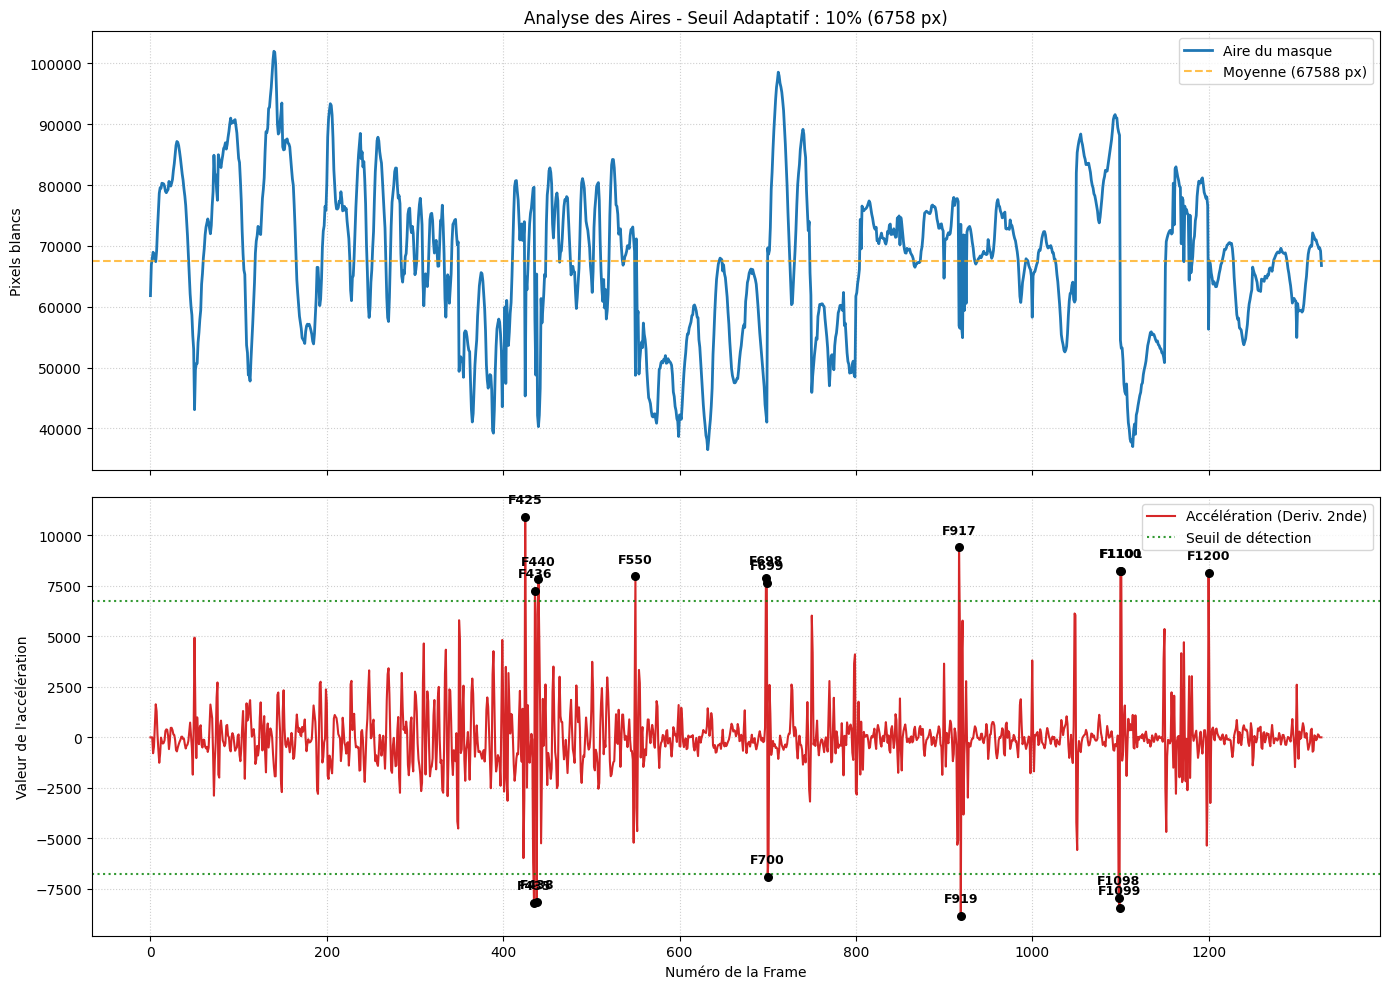

In [ ]:
import matplotlib.pyplot as plt

def plot_area_analysis(masks_dir, sensitivity_percent=10):
    # Récupération des données
    areas = get_masks_areas(masks_dir)
    if not areas:
        print("Erreur : Aucune donnée d'aire récupérée.")
        return []
    threshold = get_areas_adaptive_threshold(areas, sensitivity_percent)
    second_deriv = get_second_derivative_areas(areas)

    peaks = get_peak_indices(second_deriv, threshold)
    peak_indices = [p[0] for p in peaks]
    peak_values = [p[1] for p in peaks]

    # Graphiques
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    frames = range(len(areas))
    avg_area = np.mean(areas)

    # Graphique 1 : Aires
    ax1.plot(frames, areas, color='#1f77b4', linewidth=2, label="Aire du masque")
    ax1.axhline(y=avg_area, color='orange', linestyle='--', alpha=0.7, label=f"Moyenne ({int(avg_area)} px)")
    ax1.set_ylabel("Pixels blancs")
    ax1.set_title(f"Analyse des Aires - Seuil Adaptatif : {sensitivity_percent}% ({int(threshold)} px)")
    ax1.legend(loc='upper right')
    ax1.grid(True, linestyle=':', alpha=0.6)

    # Graphique 2 : Accélaration de l'aire
    ax2.plot(frames, second_deriv, color='#d62728', linewidth=1.5, label="Accélération (Deriv. 2nde)")
    ax2.axhline(y=threshold, color='green', linestyle=':', alpha=0.8, label="Seuil de détection")
    ax2.axhline(y=-threshold, color='green', linestyle=':', alpha=0.8)
    ax2.set_xlabel("Numéro de la Frame")
    ax2.set_ylabel("Valeur de l'accélération")
    ax2.legend(loc='upper right')
    ax2.grid(True, linestyle=':', alpha=0.6)

    if peak_indices: # Annotations des numéros de frames des pics
        ax2.scatter(peak_indices, peak_values, color='black', s=30, zorder=5, label="Pics (Anomalies)")
        for idx, val in peaks:
            ax2.annotate(f"F{idx}", (idx, val), textcoords="offset points", xytext=(0,10),ha='center', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.show()

    return peaks

pics_anomalies = plot_area_analysis(MASKS_DIRECTORY, sensitivity_percent=10)

### 2. Métrique : histogrammes des images et distance de Bhattacharyya

#### A. Fonctions utilitaires

In [ ]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

def get_bhattacharyya_distance_paths(mask1_path, mask2_path):
    m1_img = cv2.imread(mask1_path, cv2.IMREAD_GRAYSCALE)
    m2_img = cv2.imread(mask2_path, cv2.IMREAD_GRAYSCALE)
    if m1_img is None or m2_img is None: return 1.0

    # Conversion en matrices de floats 0.0 / 1.0 avant le calcul
    m1 = (m1_img > 127).astype(np.float32)
    m2 = (m2_img > 127).astype(np.float32)

    return get_bhattacharyya_distance(m1, m2)

def get_bhattacharyya_distance(m1, m2):
    """ Compare deux matrices de floats (0.0 à 1.0) via projections X et Y. """
    if m1 is None or m2 is None: return 1.0

    # Étape 1 : Calcul des projections (Profils d'intensité)
    h1x = np.sum(m1, axis=0).astype(np.float32)
    h1y = np.sum(m1, axis=1).astype(np.float32)
    h2x = np.sum(m2, axis=0).astype(np.float32)
    h2y = np.sum(m2, axis=1).astype(np.float32)

    # Étape 2 : Normalisation en distributions de probabilité
    for h in [h1x, h1y, h2x, h2y]:
        s = np.sum(h)
        if s > 0: h /= s

    # Étape 3 : Comparaison statistique
    dx = cv2.compareHist(h1x, h2x, cv2.HISTCMP_BHATTACHARYYA)
    dy = cv2.compareHist(h1y, h2y, cv2.HISTCMP_BHATTACHARYYA)

    return (dx + dy) / 2

def get_mask_overlay_in_folder(folder_path, mask_idx, window_size=2):
    """ Renvoie un combinaison des masques adjacents selon la taille du paramètre window_size.
        N'inclut pas la frame dont l'index est donné en paramètre.
        Les frames adjacentes qui n'existent pas (par exemple aux bords) son ignorées.
        Un masque vide est renvoyé si il n'existe pas de voisins valides. """
    mask_shape = cv2.imread(os.path.join(folder_path, f"{mask_idx:05d}.png"), cv2.IMREAD_GRAYSCALE).shape
    overlay = np.zeros(mask_shape, dtype=np.float32)
    if window_size <= 0: return overlay

    # Étape 1 : Récupération des paths des masques valides
    neighbor_paths = []
    valid_count = 0
    for i in range(mask_idx - window_size, mask_idx + window_size + 1):
        mask_path = os.path.join(folder_path, f"{i:05d}.png")
        if i != mask_idx and os.path.exists(mask_path):
            neighbor_paths.append(mask_path)

    # Étape 2 : Combinaison en une distribution unique et coefficientée
    for path in neighbor_paths:
        image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if image is not None:
            mask = (image > 127).astype(np.float32)
            overlay += mask

    return overlay / len(neighbor_paths) if len(neighbor_paths) > 0 else overlay

#### B. Fonctions d'affichage

In [ ]:
def plot_battacharyya_analysis(distances, threshold=0.25):
    """ Génère les graphiques : distribution et courbe temporelle empilés verticalement. """
    if not distances:
        print("Aucune distance à traiter.")
        return []

    mean_distance = np.mean(distances)
    stability_score = (1 - mean_distance) * 100

    print(f"Nombre de transitions : {len(distances)}")
    print(f"Distance moyenne entre les frames : {mean_distance:.6f}")
    print(f"Score de stabilité : {stability_score:.2f}%")

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

    # 1. Histogramme (Distribution des distances)
    ax1.hist(distances, bins=50, color='#3498db', edgecolor='black', alpha=0.7)
    ax1.set_title("Distribution de l'instabilité")
    ax1.set_xlabel("Distance (0=Stable, 1=Incohérent)")
    ax1.set_ylabel("Nombre de transitions")

    # 2. Courbe temporelle (le graphique amélioré)
    ax2.plot(distances, color='#3498db', linewidth=0.8, label="Distance de Bhattacharyya")
    ax2.axhline(y=threshold, color='#e74c3c', linestyle='--', label=f'Seuil ({threshold})')

    # Remplissage des zones d'erreur au-dessus du seuil
    ax2.fill_between(range(len(distances)), distances, threshold,
                     where=(np.array(distances) > threshold),
                     color='#e74c3c', alpha=0.3, label="Incohérence détectée")
    ax2.set_title("Évolution de la stabilité temporelle", fontsize=12)
    ax2.set_xlabel("Temps (Index de la frame t -> t+1)")
    ax2.set_ylabel("Amplitude de la modification")
    ax2.set_ylim(0, max(distances) + 0.05 if distances else 1)
    ax2.legend(loc='upper right')
    ax2.grid(axis='y', alpha=0.3)
    plt.tight_layout() # Évite que les titres ne chevauchent les axes
    plt.show()

    return [idx for idx, val in enumerate(distances) if val > threshold]

def battacharrya_analysis_in_folder(input_path, threshold=0.25, window_size=0):
    """ Analyse les masques dans un dossier contenant uniquement ces masques avec
        la distance de Battacharyya.
        - Si window_size=0, calcule la distance sur la prochaine frame uniquement
        - Si window_size>0, soit une frame d'index i, réalise un overlay (fusion)
        sur les masques adjacents correspondant à [i-window_size; i+window_size]\{i},
        puis compare la frame i à toutes celles de l'overlay"""
    files = sorted([f for f in os.listdir(input_path) if f.lower().endswith('.png')])
    distances = []

    iterations = range(len(files) - 1) if window_size == 0 else range(len(files))
    for i in tqdm(iterations):
        if window_size == 0: # Mode sans overlay : comparaison frame i/i+1
            path1 = os.path.join(input_path, files[i])
            path2 = os.path.join(input_path, files[i+1])
            distances.append(get_bhattacharyya_distance_paths(path1, path2))
        else: # Mode avec overlay : t contre moyenne du voisinage
            img = cv2.imread(os.path.join(input_path, files[i]), cv2.IMREAD_GRAYSCALE)
            mask = (img > 127).astype(np.float32) if img is not None else None
            overlay = get_mask_overlay_in_folder(input_path, i, window_size)
            distances.append(get_bhattacharyya_distance(mask, overlay))

    bad_indexes = plot_battacharyya_analysis(distances, threshold)
    return distances, bad_indexes

def display_frames_in_window(folder_path, frame_index, window_size=2):
    files = os.listdir(folder_path)
    if not files: return None
    reference_image = cv2.imread(os.path.join(folder_path,  files[0]))
    height, width, _ = reference_image.shape

    film = []
    for i in range(frame_index - window_size, frame_index + window_size + 1):
        frame_path = os.path.join(folder_path, f"{i:05d}.png")

        if os.path.exists(frame_path):
            current_frame = cv2.imread(frame_path)
            current_frame = cv2.cvtColor(current_frame, cv2.COLOR_BGR2RGB)
        else:
            current_frame = np.zeros((height, width, 3), dtype=np.uint8)

        separator = np.zeros((height, 5, 3), dtype=np.uint8)
        separator[:, :, 0] = 255 # Coloration en rouge

        film.append(current_frame)
        film.append(separator)

    plt.figure(figsize=(20, 6))
    plt.imshow(np.hstack(film[:-1])) # On montre les images côtes à côtes
    plt.title(f"Séquence de frames centrée sur la frame n°{frame_index}", fontsize=14)
    plt.axis('off')
    plt.show()

def visualize_top_anomalies(folder_path, distances_result, bad_frames, number_frames=5, window_size=2):
    bad_frames_with_scores = [(idx, distances_result[idx]) for idx in bad_frames]
    bad_frames_sorted = sorted(bad_frames_with_scores, key=lambda x: x[1], reverse=True)

    print(f"Nombre d'anomalies détectées : {len(bad_frames_sorted)}")
    for i in range(min(number_frames, len(bad_frames_sorted))):
        frame_idx, score = bad_frames_sorted[i]
        print(f"\nAnomalie n°{i+1}")
        print(f"Frame Index: {frame_idx} | Score d'incohérence: {score:.4f}")

        display_frames_in_window(folder_path, frame_idx, window_size)

<>:46: SyntaxWarning: invalid escape sequence '\{'
<>:46: SyntaxWarning: invalid escape sequence '\{'
/tmp/ipykernel_4092/3478227964.py:46: SyntaxWarning: invalid escape sequence '\{'
  sur les masques adjacents correspondant à [i-window_size; i+window_size]\{i},


#### C. Execution de la métrique seule

##### <u>Exécution 1 :</u>

Battachryya simple (on analyse avec la frame suivante).

  0%|          | 0/1328 [00:00<?, ?it/s]

Nombre de transitions : 1328
Distance moyenne entre les frames : 0.074400
Score de stabilité : 92.56%


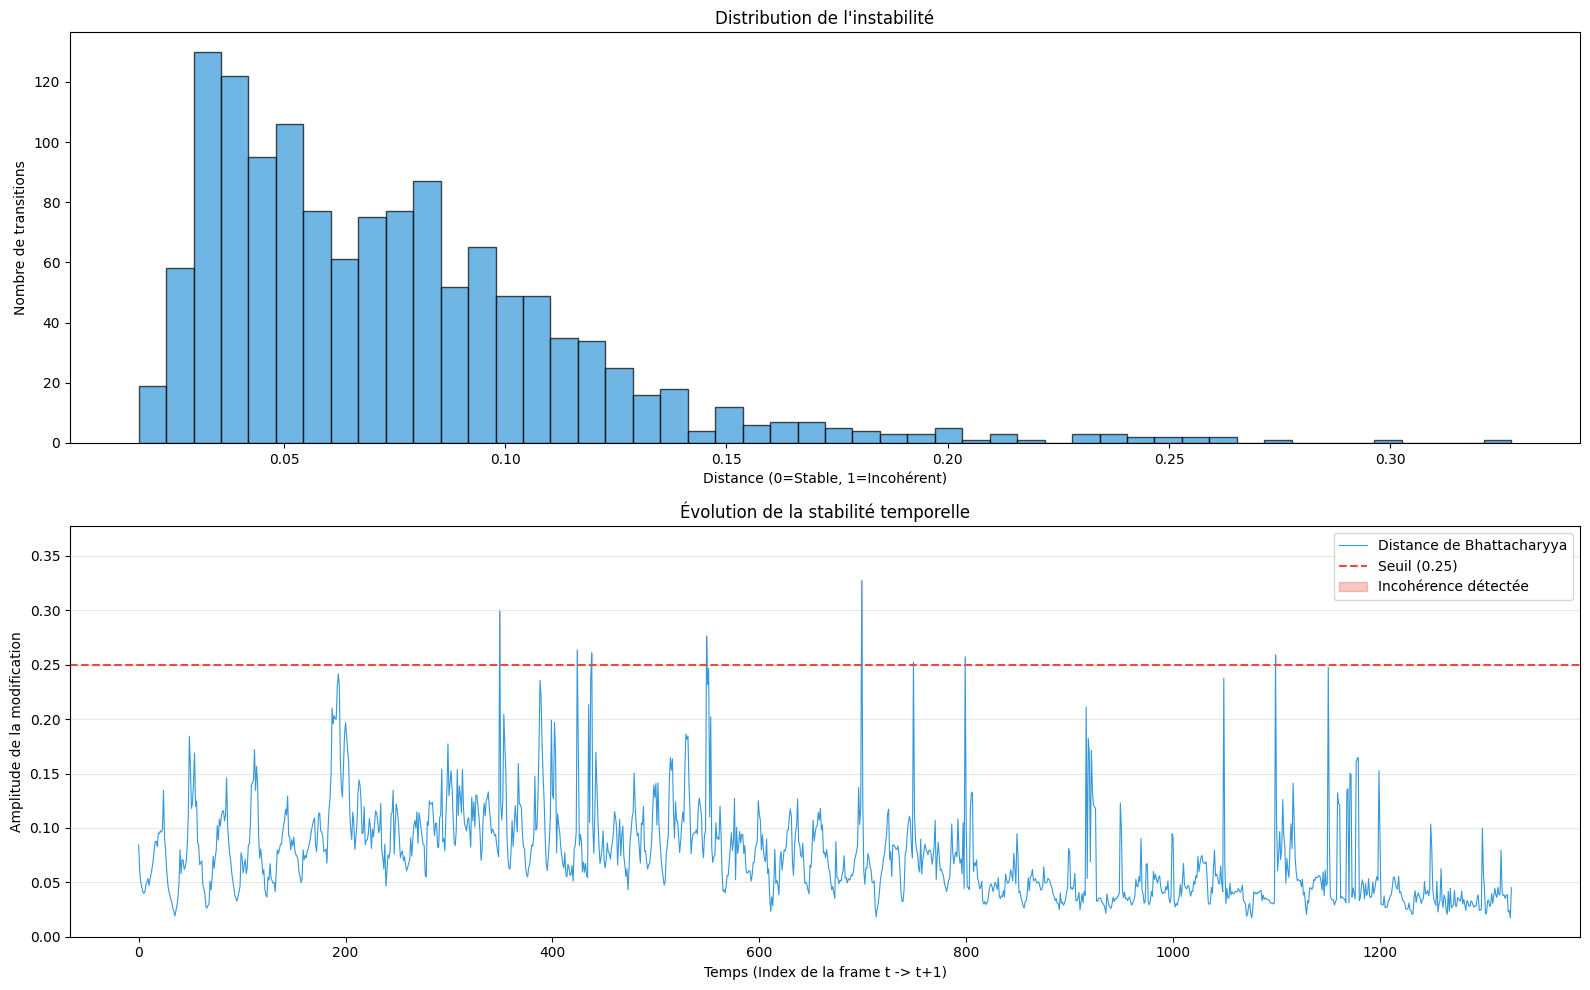

In [ ]:
threshold = 0.25
distances_simple, bad_frames_simple = battacharrya_analysis_in_folder(MASKS_DIRECTORY, threshold);

Nombre d'anomalies détectées : 8

Anomalie n°1
Frame Index: 699 | Score d'incohérence: 0.3274


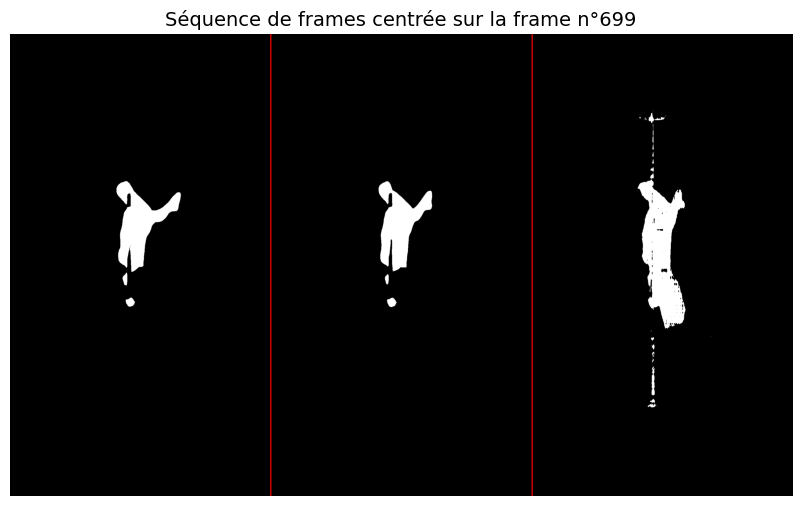


Anomalie n°2
Frame Index: 349 | Score d'incohérence: 0.2993


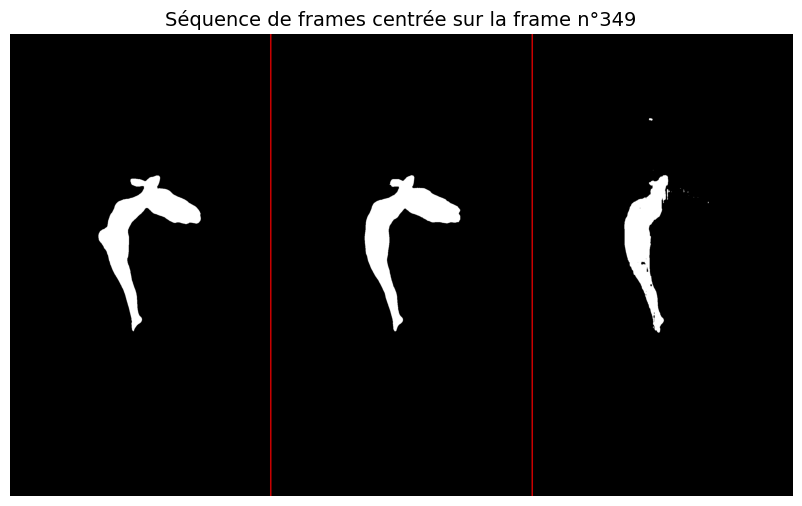


Anomalie n°3
Frame Index: 549 | Score d'incohérence: 0.2765


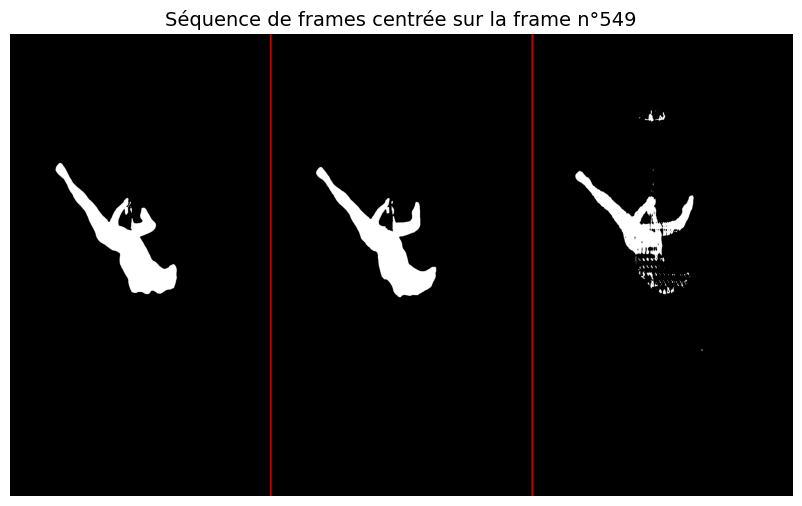


Anomalie n°4
Frame Index: 424 | Score d'incohérence: 0.2636


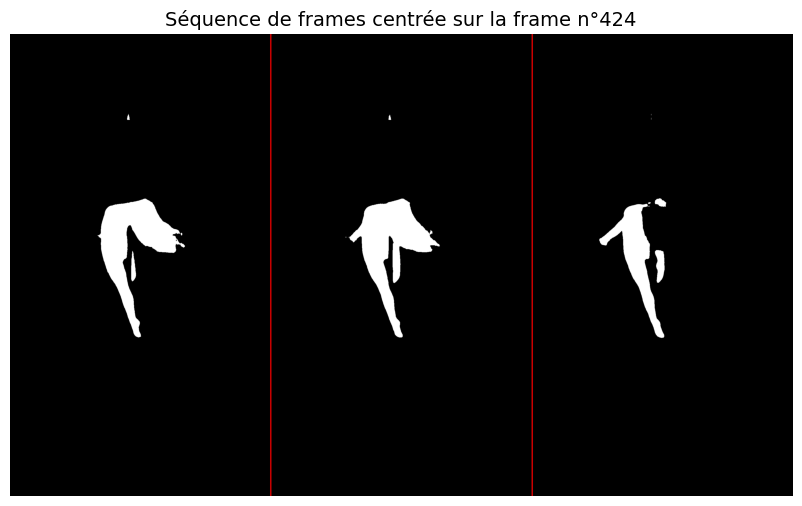


Anomalie n°5
Frame Index: 438 | Score d'incohérence: 0.2611


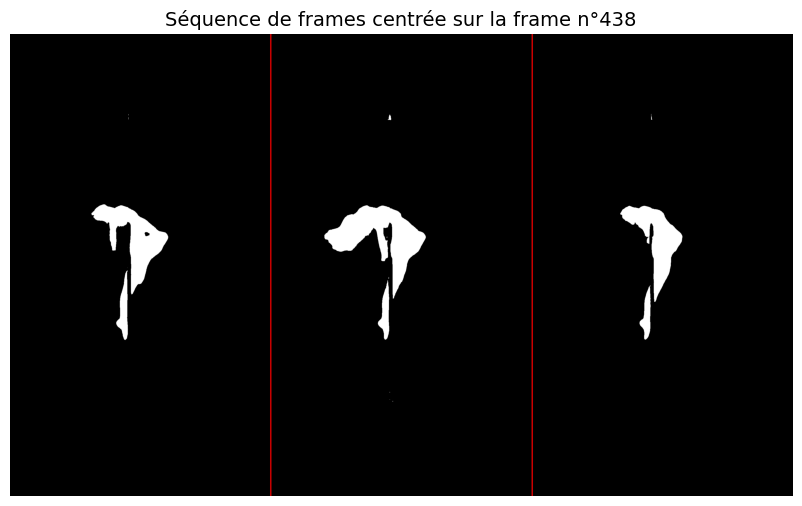


Anomalie n°6
Frame Index: 1099 | Score d'incohérence: 0.2591


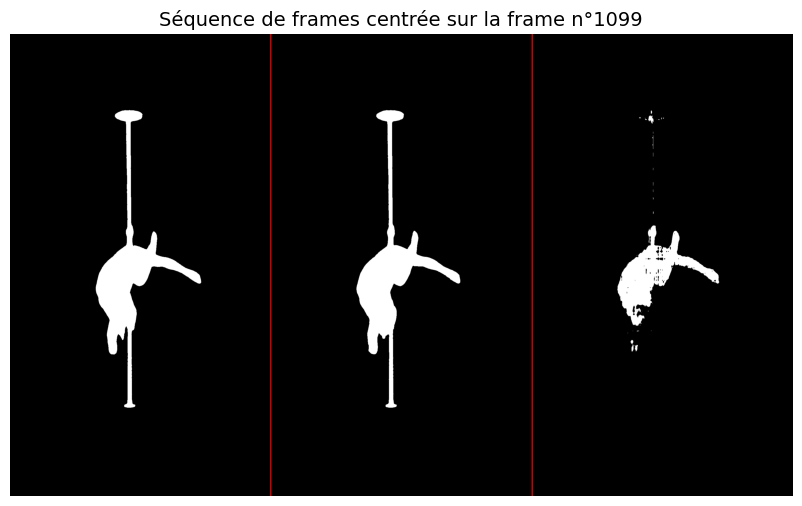


Anomalie n°7
Frame Index: 799 | Score d'incohérence: 0.2573


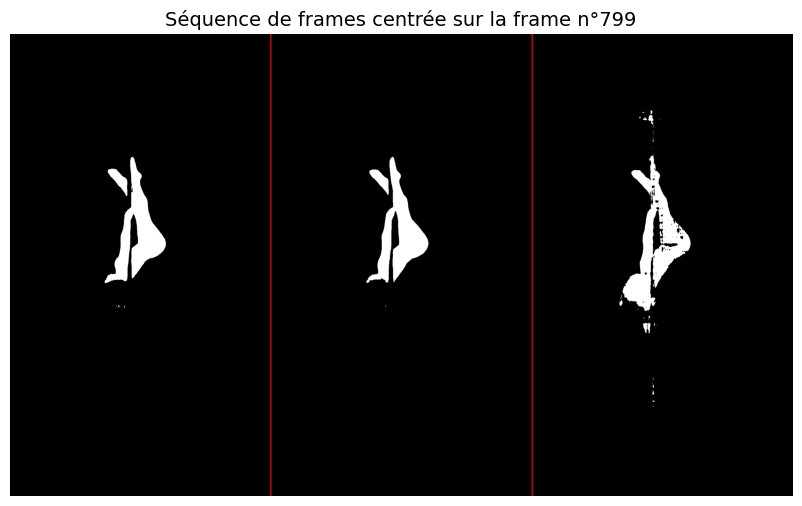


Anomalie n°8
Frame Index: 749 | Score d'incohérence: 0.2525


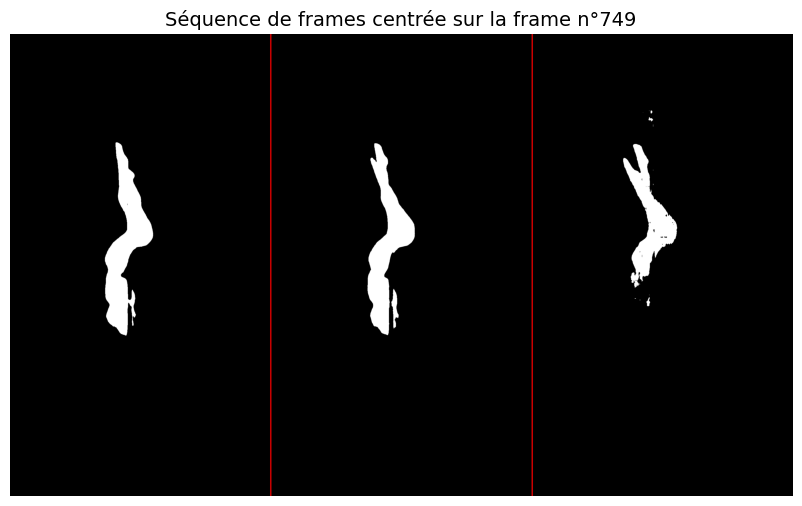

In [ ]:
frames_to_visualize = 10
visualize_top_anomalies(MASKS_DIRECTORY, distances_simple, bad_frames_simple, frames_to_visualize, 1)

##### <u>Exécution 2 :</u>

Avec overlay.

  0%|          | 0/1329 [00:00<?, ?it/s]

Nombre de transitions : 1329
Distance moyenne entre les frames : 0.065486
Score de stabilité : 93.45%


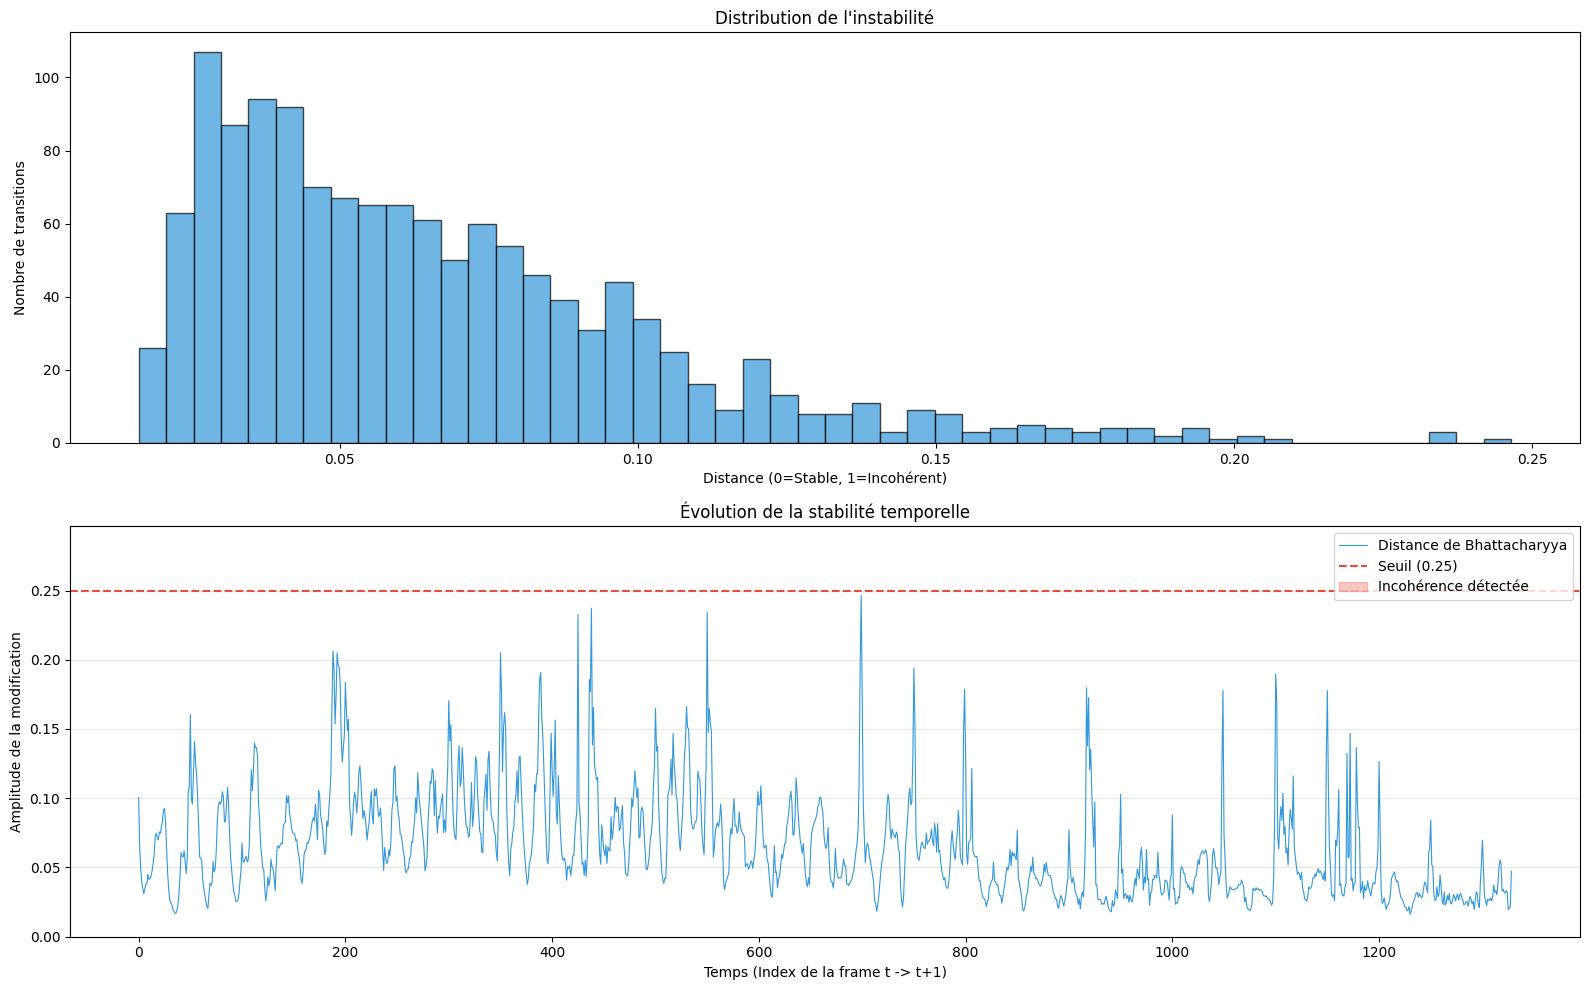

In [ ]:
window_size_overlay = 2
distances_overlay, bad_frames_overlay = battacharrya_analysis_in_folder(MASKS_DIRECTORY, threshold, window_size_overlay)

In [ ]:
frames_to_visualize = 15
visualize_top_anomalies(MASKS_DIRECTORY, distances_overlay, bad_frames_overlay, frames_to_visualize, window_size_overlay)

Nombre d'anomalies détectées : 0


#### D. Matrices de confusion

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def load_annotations_csv(csv_path):
    """ Charge le CSV d'annotations (frame->label avec 1 pour ko et 0 pour ok dans label) """
    try:
        df = pd.read_csv(csv_path)
        df = df.sort_values(by='frame')
        print(f"Succès : {len(df)} frames annotées chargées.")
        return df['label'].values
    except Exception as e:
        print(f"Erreur lors du chargement du CSV : {e}")
        return None

def plot_confusion_matrix(y_true, bad_frames, total_frames):
    y_pred = np.ones(total_frames)
    y_pred[bad_frames] = 0

    # Synchronisation des longueurs
    min_len = min(len(y_true), len(y_pred))
    y_true_sync = y_true[:min_len]
    y_pred_sync = y_pred[:min_len]

    cm = confusion_matrix(y_true_sync, y_pred_sync, labels=[1, 0])

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
                xticklabels=['Prédit OK (1)', 'Prédit BUG (0)'],
                yticklabels=['Réel OK (1)', 'Réel BUG (0)'])
    plt.title('Matrice de Confusion')
    plt.ylabel('Vérité Terrain')
    plt.xlabel('Prédiction')
    plt.show()

    print(classification_report(y_true_sync, y_pred_sync, target_names=['BUG (0)', 'OK (1)']))

def plot_change_confusion_matrix(y_true, bad_frames):
    """ Matrice de confusion uniquement sur les changements d'états """
    total_frames = len(y_true)
    y_true_change = [0] * (total_frames - 1)
    y_pred_change = [0] * (total_frames - 1)

    for i in range(total_frames - 1):
        if y_true[i] != y_true[i+1]:
            y_true_change[i] = 1

    for index in bad_frames:
        y_pred_change[index] = 1

    y_true_final = np.array(y_true_change)
    y_pred_final = np.array(y_pred_change)

    # 4. Matrice de Confusion 2x2
    # labels=[0, 1] pour avoir Stable (0) en premier et Changement (1) en deuxième
    cm = confusion_matrix(y_true_final, y_pred_final, labels=[0, 1])

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
                xticklabels=['Stable (0)', 'Alerte (1)'],
                yticklabels=['Stable (0)', 'Changement (1)'])

    plt.title('Matrice de Confusion : Événements (Changement = 1)')
    plt.ylabel('Vérité Terrain (Humain)')
    plt.xlabel('Prédiction (Algorithme)')
    plt.show()
    print(classification_report(y_true_final, y_pred_final, target_names=['STABLE (0)', 'CHANGEMENT (1)']))

Succès : 1329 frames annotées chargées.
Méthode SANS overlay


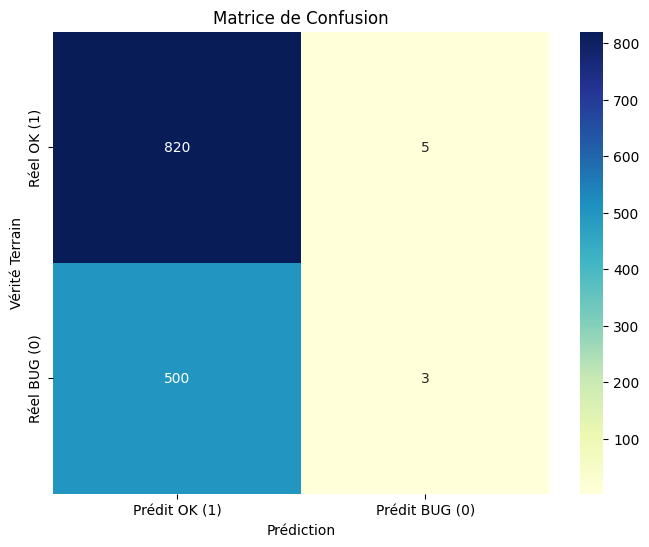

              precision    recall  f1-score   support

     BUG (0)       0.38      0.01      0.01       503
      OK (1)       0.62      0.99      0.76       825

    accuracy                           0.62      1328
   macro avg       0.50      0.50      0.39      1328
weighted avg       0.53      0.62      0.48      1328

Méthode AVEC overlay


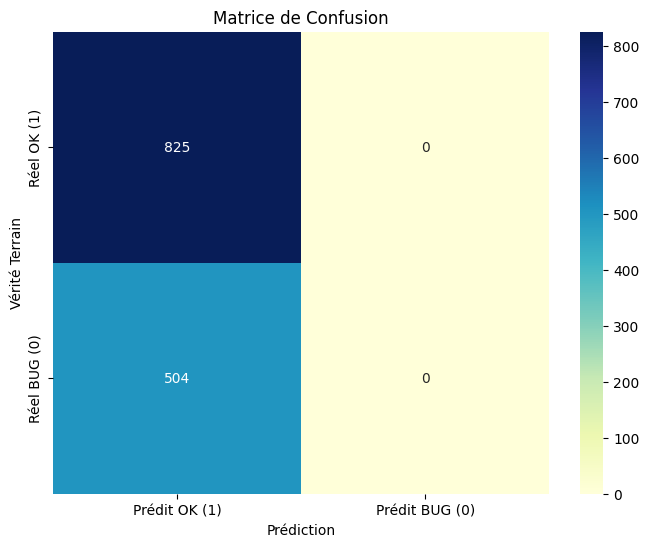

              precision    recall  f1-score   support

     BUG (0)       0.00      0.00      0.00       504
      OK (1)       0.62      1.00      0.77       825

    accuracy                           0.62      1329
   macro avg       0.31      0.50      0.38      1329
weighted avg       0.39      0.62      0.48      1329



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
ground_truth = load_annotations_csv(ANNOTATIONS_PATH)
if ground_truth is not None:
    print("Méthode SANS overlay")
    plot_confusion_matrix(ground_truth, bad_frames_simple, len(distances_simple))

    print("Méthode AVEC overlay")
    plot_confusion_matrix(ground_truth, bad_frames_overlay, len(distances_overlay))

Succès : 1329 frames annotées chargées.
Méthode SANS overlay


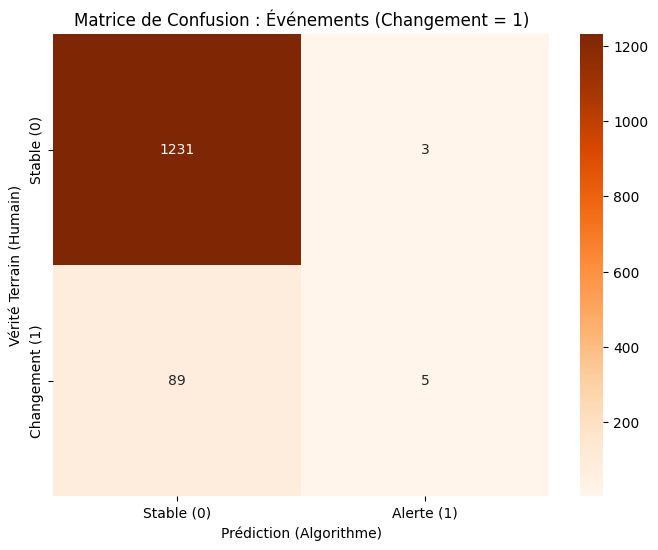

                precision    recall  f1-score   support

    STABLE (0)       0.93      1.00      0.96      1234
CHANGEMENT (1)       0.62      0.05      0.10        94

      accuracy                           0.93      1328
     macro avg       0.78      0.53      0.53      1328
  weighted avg       0.91      0.93      0.90      1328


Méthode AVEC overlay


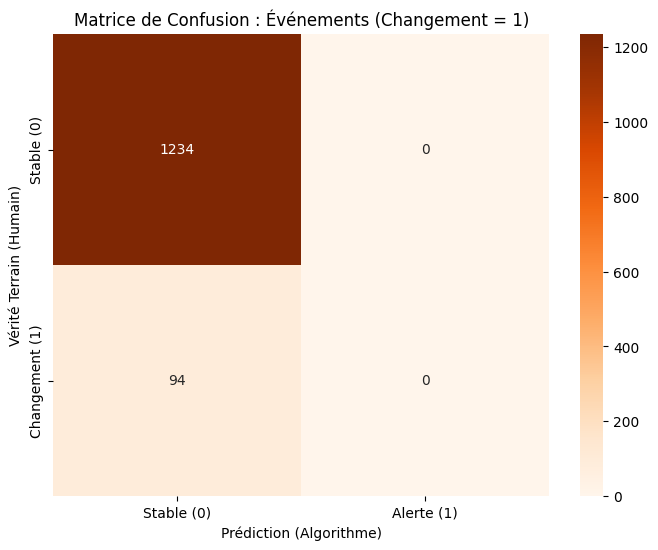

                precision    recall  f1-score   support

    STABLE (0)       0.93      1.00      0.96      1234
CHANGEMENT (1)       0.00      0.00      0.00        94

      accuracy                           0.93      1328
     macro avg       0.46      0.50      0.48      1328
  weighted avg       0.86      0.93      0.90      1328



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
ground_truth = load_annotations_csv(ANNOTATIONS_PATH)
if ground_truth is not None:
    print("Méthode SANS overlay")
    plot_change_confusion_matrix(ground_truth, bad_frames_simple)

    print("\nMéthode AVEC overlay")
    plot_change_confusion_matrix(ground_truth, bad_frames_overlay)

### 3. Métrique : variation du squelette via `SAM 3D Body`

Il existe deux versions alternantives pour la métrique `Aidemos` : une version rapide (partie `C`) et une plus lente mais plus précise (partie `D`).

Ces deux versions ont le même objectif : mesurer la variation du squelette reconstruit entre deux frames consécutives, sur des runs d'erreurs.

La différence principale de la version rapide par rapport à la lente est une analyse simplifiée :
- Pas de jeu témoin,
- Pas de comparaison erreur / témoin,
- Moins de colonnes intermédiaires,
- Moins de visualisations,
- Code plus court.

On recommande donc de lancer :
- <u>**La version rapide**</u> : Si on souhaite débugger / obtenir des résultats généraux rapidement,
- <u>**La version lente**</u> : Si on souhaite des analyses plus poussées.

#### A. Installation et chargement de l'outil

In [ ]:
# CELLULE À EXÉCUTER UNE SEULE FOIS :
#   Cette cellule adapte le setup officiel de SAM 3D Body à Colab.
#   Elle peut prendre un peu de temps.
#   Il faut avoir obtenu l'accès Hugging Face au modèle :
#     facebook/sam-3d-body-dinov3

import os
import sys
import subprocess

SAM3D_BODY_DIR = "/content/sam-3d-body"

if not os.path.exists(SAM3D_BODY_DIR):
    !git clone https://github.com/facebookresearch/sam-3d-body.git "{SAM3D_BODY_DIR}"

# Dépendances utiles à l'inférence :
!pip -q install pytorch-lightning pyrender opencv-python yacs scikit-image einops timm dill pandas rich hydra-core hydra-submitit-launcher hydra-colorlog pyrootutils webdataset chump networkx==3.2.1 roma joblib seaborn appdirs cython jsonlines xtcocotools loguru optree fvcore pycocotools tensorboard huggingface_hub

# Détecteur / dépendances recommandées par le repo :
!pip -q install 'git+https://github.com/facebookresearch/detectron2.git@a1ce2f9' --no-build-isolation --no-deps
!pip -q install git+https://github.com/microsoft/MoGe.git

Cloning into '/content/sam-3d-body'...
remote: Enumerating objects: 184, done.
remote: Counting objects: 100% (114/114), done.
remote: Compressing objects: 100% (100/100), done.
remote: Total 184 (delta 38), reused 14 (delta 14), pack-reused 70 (from 1)
Receiving objects: 100% (184/184), 22.39 MiB | 13.89 MiB/s, done.
Resolving deltas: 100% (40/40), done.
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 5.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 102.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 91.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 68.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 84.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61

In [ ]:
# Authentification Hugging Face + chargement du modèle :

from getpass import getpass
from huggingface_hub import login, whoami

try:
    if not isinstance(HUGGING_FACE_TOKEN, str):
        raise TypeError("HUGGING_FACE_TOKEN doit être une chaîne")

    HF_TOKEN = HUGGING_FACE_TOKEN.strip()
    if not HF_TOKEN:
        raise ValueError("HUGGING_FACE_TOKEN ne doit pas être vide")

except (NameError, TypeError, ValueError):
    HF_TOKEN = getpass("Token Hugging Face : ").strip()

if len(HF_TOKEN) == 0:
    raise RuntimeError("Le token Hugging Face est vide.")

login(token=HF_TOKEN, add_to_git_credential=False)
print("Authentification Hugging Face effectuée.")
print(whoami())

Authentification Hugging Face effectuée.
{'type': 'user', 'id': '69cb6b70209141131a40ccf8', 'name': 'tominien', 'fullname': 'Tom Le Ber', 'email': 'tom.leber.toulouse@gmail.com', 'emailVerified': True, 'canPay': False, 'billingMode': 'prepaid', 'periodEnd': 1777593600, 'isPro': False, 'avatarUrl': '/avatars/abbaa66f4e60ad1ad6aebd480034b834.svg', 'orgs': [], 'auth': {'type': 'access_token', 'accessToken': {'displayName': 'ter_irit', 'role': 'read', 'createdAt': '2026-03-31T06:55:29.307Z'}}}


In [ ]:
# Chargement de l'estimateur officiel SAM 3D Body :

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from IPython.display import display

%cd {SAM3D_BODY_DIR}

from notebook.utils import setup_sam_3d_body

SAM3D_BODY_HF_REPO = "facebook/sam-3d-body-dinov3"

estimator = setup_sam_3d_body(hf_repo_id=SAM3D_BODY_HF_REPO)
print("Estimateur SAM 3D Body chargé avec succès.")

%cd /content

/content/sam-3d-body


/content/sam-3d-body/sam_3d_body/models/heads/mhr_head.py:33: UserWarning: Momentum is not enabled
  warnings.warn("Momentum is not enabled")


Loading SAM 3D Body model from facebook/sam-3d-body-dinov3...


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading SAM 3D Body model...
Downloading: "https://github.com/facebookresearch/dinov3/zipball/main" to /root/.cache/torch/hub/main.zip


...

Loading human detector from vitdet...
########### Using human detector: ViTDet...


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
model_final_f05665.pkl: 2.77GB [01:10, 39.5MB/s]                           


Loading FOV estimator from moge2...
########### Using fov estimator: MoGe2...


model.pt:   0%|          | 0.00/1.32G [00:00<?, ?B/s]

Mask-condition inference is not supported...
Setup complete!
  Human detector: ✓
  Human segmentor: ✗ (mask inference disabled)
  FOV estimator: ✓
Estimateur SAM 3D Body chargé avec succès.
/content


#### B. Fonctions utilitaires

In [ ]:
import os
import io
import re
import cv2
import pickle
import warnings
import contextlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# (1) Utilitaires sur les runs d'erreurs :

def build_consecutive_runs(indices):
    """
    Transforme une liste d'indices triés en runs consécutifs.
    Ex :
      [5,6,7,10,11] -> [(5,7), (10,11)]
    """
    if indices is None:
        return []

    indices = sorted(set(int(x) for x in indices))
    if len(indices) == 0:
        return []

    runs = []
    start = indices[0]
    prev = indices[0]

    for idx in indices[1:]:
        if idx == prev + 1:
            prev = idx
        else:
            runs.append((start, prev))
            start = idx
            prev = idx

    runs.append((start, prev))
    return runs

def frame_runs_from_transition_indices(bad_transition_indices):
    """
    Convertit des indices de transitions en runs de frames.
    Ex :
      transitions [5,6,7,8,9] -> frames [5,6,7,8,9,10] -> run (5,10)
    """
    frames = []
    for t in bad_transition_indices:
        frames.append(int(t))
        frames.append(int(t) + 1)

    return build_consecutive_runs(frames)

def frame_runs_from_frame_indices(bad_frame_indices):
    """
    Si la liste fournie correspond déjà à des frames erronées,
    on la regroupe directement en runs.
    """
    return build_consecutive_runs(bad_frame_indices)

def frame_runs_from_annotations(y_true, error_value=0):
    """
    Construit les runs de frames erronées depuis un vecteur d'annotations.
    Dans ce notebook :
      label 0 = erreur
      label 1 = pas d'erreur
    """
    y_true = np.asarray(y_true)
    bad_indices = np.where(y_true == error_value)[0].tolist()
    return build_consecutive_runs(bad_indices)

def transition_indices_from_runs(error_runs, min_run_length=2):
    """
    Extrait les transitions t -> t+1 à partir de runs de frames.
    Renvoie aussi un dictionnaire transition -> run_id.
    """
    transition_indices = []
    run_lookup = {}

    for run_id, (start, end) in enumerate(error_runs):
        if end - start + 1 < min_run_length:
            continue

        for t in range(start, end):
            transition_indices.append(int(t))
            run_lookup[int(t)] = int(run_id)

    return transition_indices, run_lookup

# (2) Utilitaires image / masque / calque :

def list_original_frames(frames_dir=FRAMES_DIRECTORY):
    files = sorted(
        [f for f in os.listdir(frames_dir) if f.lower().endswith((".png", ".jpg", ".jpeg"))]
    )
    if len(files) == 0:
        raise ValueError(f"Aucune frame trouvée dans : {frames_dir}")
    return files

ORIGINAL_FRAME_FILES = list_original_frames()

def read_original_frame_by_index(frame_idx, frames_dir=FRAMES_DIRECTORY, frame_files=ORIGINAL_FRAME_FILES):
    if not (0 <= frame_idx < len(frame_files)):
        return None
    img_path = os.path.join(frames_dir, frame_files[frame_idx])
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        return None
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

def resolve_mask_path(frame_idx, masks_dir=MASKS_DIRECTORY):
    """
    Gère à la fois les cas 0-based et 1-based par prudence.
    """
    candidates = [
        os.path.join(masks_dir, f"{frame_idx:05d}.png"),
        os.path.join(masks_dir, f"{frame_idx + 1:05d}.png"),
    ]
    for path in candidates:
        if os.path.exists(path):
            return path
    return None

def read_mask_by_index(frame_idx, masks_dir=MASKS_DIRECTORY):
    mask_path = resolve_mask_path(frame_idx, masks_dir)
    if mask_path is None:
        return None
    mask_gray = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask_gray is None:
        return None
    return (mask_gray > 127)

def build_cutout_crop_from_index(frame_idx, margin_ratio=0.10):
    """
    Construit un calque RGB recadré autour de la danseuse à partir :
      - de la frame originale
      - du masque binaire reconstruit
    """
    img_rgb = read_original_frame_by_index(frame_idx)
    mask = read_mask_by_index(frame_idx)

    if img_rgb is None or mask is None:
        return None, None

    ys, xs = np.where(mask)
    if len(xs) == 0 or len(ys) == 0:
        return None, None

    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()

    h, w = mask.shape
    bw = x2 - x1 + 1
    bh = y2 - y1 + 1

    pad_x = int(margin_ratio * bw)
    pad_y = int(margin_ratio * bh)

    x1 = max(0, x1 - pad_x)
    x2 = min(w - 1, x2 + pad_x)
    y1 = max(0, y1 - pad_y)
    y2 = min(h - 1, y2 + pad_y)

    cutout_rgb = np.zeros_like(img_rgb)
    cutout_rgb[mask] = img_rgb[mask]

    crop_rgb = cutout_rgb[y1:y2+1, x1:x2+1]

    if crop_rgb.size == 0:
        return None, None

    meta = {
        "frame_idx": int(frame_idx),
        "crop_box_xyxy": (int(x1), int(y1), int(x2), int(y2)),
        "crop_shape_hw": crop_rgb.shape[:2],
        "mask_area_px": int(mask.sum()),
    }

    return crop_rgb, meta

# (3) Utilitaires sorties SAM 3D Body + cache disque :

SAM3D_BODY_CACHE_DIR = os.path.join(RESULTS_DIRECTORY, "sam3d_body_cache")
os.makedirs(SAM3D_BODY_CACHE_DIR, exist_ok=True)

def to_numpy_safe(x):
    if x is None:
        return None
    if isinstance(x, np.ndarray):
        return x
    try:
        import torch
        if torch.is_tensor(x):
            return x.detach().cpu().numpy()
    except Exception:
        pass
    return np.asarray(x)

def select_primary_person(outputs):
    """
    Sélectionne la personne principale dans la sortie du modèle.
    Sur les calques reconstruits, il ne devrait y avoir qu'une seule personne.
    """
    if outputs is None:
        return None

    if isinstance(outputs, dict) and "pred_keypoints_3d" in outputs:
        return outputs

    if isinstance(outputs, dict):
        values = [v for v in outputs.values() if isinstance(v, dict)]
        if len(values) == 0:
            return None
        outputs = values

    if isinstance(outputs, (list, tuple)):
        if len(outputs) == 0:
            return None

        def person_score(p):
            k2 = to_numpy_safe(p.get("pred_keypoints_2d", None))
            if k2 is None:
                return -1.0
            k2 = np.squeeze(k2)
            if k2.ndim != 2 or k2.shape[0] == 0:
                return -1.0
            xy = k2[:, :2]
            valid = np.isfinite(xy).all(axis=1)
            if not np.any(valid):
                return -1.0
            mins = xy[valid].min(axis=0)
            maxs = xy[valid].max(axis=0)
            area = float(np.prod(np.maximum(maxs - mins, 1e-6)))
            return area

        return max(outputs, key=person_score)

    return None

def get_sam3d_body_cache_path(frame_idx, cache_dir=SAM3D_BODY_CACHE_DIR):
    return os.path.join(cache_dir, f"{int(frame_idx):05d}.pkl")

def save_sam3d_body_cache(frame_idx, payload, cache_dir=SAM3D_BODY_CACHE_DIR):
    with open(get_sam3d_body_cache_path(frame_idx, cache_dir), "wb") as f:
        pickle.dump(payload, f)

def load_sam3d_body_cache(frame_idx, cache_dir=SAM3D_BODY_CACHE_DIR):
    path = get_sam3d_body_cache_path(frame_idx, cache_dir)
    if not os.path.exists(path):
        return None
    with open(path, "rb") as f:
        return pickle.load(f)

def extract_boxes_from_sam3d_log(log_text):
    """
    Extrait les bounding boxes depuis les logs textuels SAM 3D Body.
    Retourne un tableau [N, 4] si possible, sinon None.
    """
    if log_text is None or len(log_text) == 0:
        return None

    matches = re.findall(r"Found boxes:\s*\[\[(.*?)\]\]", log_text, flags=re.DOTALL)
    if len(matches) == 0:
        return None

    last_match = matches[-1]
    nums = re.findall(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", last_match)

    if len(nums) < 4:
        return None

    vals = np.array([float(x) for x in nums], dtype=np.float32)
    n = (len(vals) // 4) * 4
    vals = vals[:n]

    if len(vals) == 0:
        return None

    return vals.reshape(-1, 4)

def format_boxes_for_log(boxes):
    """
    Formatte proprement les boxes pour affichage compact.
    """
    if boxes is None or len(boxes) == 0:
        return "no box detected"

    return np.array2string(
        np.asarray(boxes, dtype=np.float32),
        precision=2,
        suppress_small=True,
    )

def print_compact_sam3d_log(frame_idx, log_text, cached=False):
    """
    Affiche une ligne condensée par frame.
    """
    prefix = f"frame_{int(frame_idx):05d}"

    if cached:
        print(f"{prefix} = cache hit")
        return

    boxes = extract_boxes_from_sam3d_log(log_text)

    if boxes is None:
        print(f"{prefix} = no box detected")
    else:
        print(f"{prefix} = Found boxes: {format_boxes_for_log(boxes)}")

def infer_skeleton_on_cutout_rgb(
    cutout_rgb,
    frame_idx=None,
    use_cache=True,
    force_recompute=False,
    compact_logs=True,
):
    """
    Applique SAM 3D Body à un calque RGB recadré.
    Un petit cache disque est utilisé pour éviter de relancer l'inférence
    sur les mêmes frames à chaque exécution de la métrique.

    Si compact_logs=True, on remplace les sorties verbeuses internes
    par une ligne condensée par frame.
    """
    if cutout_rgb is None:
        return None

    if frame_idx is not None and use_cache and not force_recompute:
        cached = load_sam3d_body_cache(frame_idx)
        if cached is not None:
            if compact_logs:
                print_compact_sam3d_log(frame_idx, log_text="", cached=True)
            return cached

    # Sécurisation du format d'entrée :
    cutout_rgb = np.asarray(cutout_rgb)

    if cutout_rgb.ndim == 2:
        cutout_rgb = np.stack([cutout_rgb] * 3, axis=-1)

    if cutout_rgb.ndim != 3 or cutout_rgb.shape[2] < 3:
        return None

    cutout_rgb = np.ascontiguousarray(cutout_rgb[..., :3]).astype(np.uint8)

    # Capture des logs internes SAM 3D Body :
    buf_out = io.StringIO()
    buf_err = io.StringIO()

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        with contextlib.redirect_stdout(buf_out), contextlib.redirect_stderr(buf_err):
            outputs = estimator.process_one_image(cutout_rgb)

    raw_log_text = buf_out.getvalue() + "\n" + buf_err.getvalue()

    if compact_logs and frame_idx is not None:
        print_compact_sam3d_log(frame_idx, raw_log_text, cached=False)

    person = select_primary_person(outputs)

    if person is None:
        result = None
    else:
        result = {}
        for key in [
            "pred_vertices",
            "pred_keypoints_3d",
            "pred_keypoints_2d",
            "pred_cam_t",
            "focal_length",
            "body_pose_params",
            "hand_pose_params",
            "shape_params",
        ]:
            if key in person:
                result[key] = to_numpy_safe(person[key])

    if frame_idx is not None and use_cache:
        save_sam3d_body_cache(frame_idx, result)

    return result

# (4) Distances "squelettiques" :

def procrustes_distance_3d(keypoints_a, keypoints_b):
    """
    Distance moyenne entre deux squelettes 3D après :
      - centrage
      - normalisation d'échelle
      - alignement rigide (Kabsch)
    """
    if keypoints_a is None or keypoints_b is None:
        return np.nan, None

    A = np.squeeze(np.asarray(keypoints_a, dtype=np.float64))
    B = np.squeeze(np.asarray(keypoints_b, dtype=np.float64))

    if A.ndim != 2 or B.ndim != 2:
        return np.nan, None

    A = A[:, :3]
    B = B[:, :3]

    J = min(len(A), len(B))
    if J < 3:
        return np.nan, None

    A = A[:J]
    B = B[:J]

    valid = np.isfinite(A).all(axis=1) & np.isfinite(B).all(axis=1)
    A = A[valid]
    B = B[valid]

    if len(A) < 3:
        return np.nan, None

    A0 = A - A.mean(axis=0, keepdims=True)
    B0 = B - B.mean(axis=0, keepdims=True)

    scale_A = np.sqrt((A0 ** 2).sum() / len(A0))
    scale_B = np.sqrt((B0 ** 2).sum() / len(B0))

    if scale_A < 1e-8 or scale_B < 1e-8:
        return np.nan, None

    A0 /= scale_A
    B0 /= scale_B

    H = A0.T @ B0
    U, S, Vt = np.linalg.svd(H)
    R = Vt.T @ U.T

    if np.linalg.det(R) < 0:
        Vt[-1, :] *= -1
        R = Vt.T @ U.T

    A_aligned = A0 @ R
    per_joint = np.linalg.norm(A_aligned - B0, axis=1)

    return float(np.mean(per_joint)), per_joint

def normalized_distance_2d(keypoints_a, keypoints_b):
    """
    Distance 2D normalisée (centrage + échelle) entre deux squelettes projetés.
    Sert de secours / comparaison.
    """
    if keypoints_a is None or keypoints_b is None:
        return np.nan, None

    A = np.squeeze(np.asarray(keypoints_a, dtype=np.float64))
    B = np.squeeze(np.asarray(keypoints_b, dtype=np.float64))

    if A.ndim != 2 or B.ndim != 2:
        return np.nan, None

    A = A[:, :2]
    B = B[:, :2]

    J = min(len(A), len(B))
    if J < 3:
        return np.nan, None

    A = A[:J]
    B = B[:J]

    valid = np.isfinite(A).all(axis=1) & np.isfinite(B).all(axis=1)
    A = A[valid]
    B = B[valid]

    if len(A) < 3:
        return np.nan, None

    A0 = A - A.mean(axis=0, keepdims=True)
    B0 = B - B.mean(axis=0, keepdims=True)

    scale_A = np.sqrt((A0 ** 2).sum() / len(A0))
    scale_B = np.sqrt((B0 ** 2).sum() / len(B0))

    if scale_A < 1e-8 or scale_B < 1e-8:
        return np.nan, None

    A0 /= scale_A
    B0 /= scale_B

    per_joint = np.linalg.norm(A0 - B0, axis=1)
    return float(np.mean(per_joint)), per_joint

def valid_joint_ratio(keypoints):
    if keypoints is None:
        return np.nan

    K = np.squeeze(np.asarray(keypoints, dtype=np.float64))
    if K.ndim != 2:
        return np.nan

    D = min(3, K.shape[1])
    valid = np.isfinite(K[:, :D]).all(axis=1)
    return float(valid.mean())

def draw_keypoints_2d(ax, image_rgb, keypoints_2d, title=""):
    ax.imshow(image_rgb)
    if keypoints_2d is not None:
        pts = np.squeeze(np.asarray(keypoints_2d, dtype=np.float64))
        if pts.ndim == 2 and pts.shape[0] > 0:
            xy = pts[:, :2]
            valid = np.isfinite(xy).all(axis=1)
            if np.any(valid):
                ax.scatter(xy[valid, 0], xy[valid, 1], s=8)
    ax.set_title(title)
    ax.axis("off")

def to_display_xyz(points_3d):
    """
    Réoriente les points 3D pour un affichage plus naturel.
    """
    P = np.asarray(points_3d, dtype=np.float64)
    X = P[:, 0]
    Y = P[:, 2]
    Z = -P[:, 1]
    return np.stack([X, Y, Z], axis=1)

def set_axes_equal_3d(ax, pts_3d):
    """
    Donne la même échelle aux 3 axes pour éviter un rendu déformé.
    """
    if pts_3d is None or len(pts_3d) == 0:
        return

    mins = np.nanmin(pts_3d, axis=0)
    maxs = np.nanmax(pts_3d, axis=0)

    center = (mins + maxs) / 2.0
    radius = np.max(maxs - mins) / 2.0

    if not np.isfinite(radius) or radius <= 0:
        radius = 1.0

    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_zlim(center[2] - radius, center[2] + radius)

def style_3d_axis(ax, dark=True):
    """
    Améliore la lisibilité du subplot 3D.
    """
    if dark:
        bg = "#0f1117"
        pane = (0.10, 0.11, 0.14, 1.0)
        edge = (0.35, 0.35, 0.40, 1.0)

        ax.set_facecolor(bg)

        for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
            axis.pane.set_facecolor(pane)
            axis.pane.set_edgecolor(edge)

        ax.xaxis.label.set_color("white")
        ax.yaxis.label.set_color("white")
        ax.zaxis.label.set_color("white")

        ax.tick_params(colors="white")
        ax.grid(False)
    else:
        ax.grid(True, alpha=0.2)

def draw_skeleton_3d(
    ax,
    skeleton,
    title="",
    show_vertices=True,
    max_vertices=9000,
    dark=True,
    elev=18,
    azim=-60,
):
    """
    Affiche un corps 3D plus visible :
    - fond sombre
    - vertices plus denses et plus visibles
    - joints contrastés
    - angle de vue fixe
    """
    if skeleton is None:
        ax.set_title(title + "\nAucun squelette")
        ax.axis("off")
        return

    style_3d_axis(ax, dark=dark)

    keypoints_3d = skeleton.get("pred_keypoints_3d", None)
    vertices = skeleton.get("pred_vertices", None)

    pts_display = None

    # (1) Nuage de vertices plus visible
    if show_vertices and vertices is not None:
        V = np.squeeze(np.asarray(vertices, dtype=np.float64))

        if V.ndim == 2 and V.shape[1] >= 3:
            V = V[:, :3]

            if len(V) > max_vertices:
                # échantillonnage aléatoire pour garder une bonne densité visuelle
                rng = np.random.default_rng(0)
                idx = rng.choice(len(V), size=max_vertices, replace=False)
                V = V[idx]

            Vd = to_display_xyz(V)

            ax.scatter(
                Vd[:, 0],
                Vd[:, 1],
                Vd[:, 2],
                s=1.2,
                alpha=0.18,
                c="#74d3ff",
                depthshade=False,
            )

    # (2) Joints 3D très contrastés
    if keypoints_3d is not None:
        K = np.squeeze(np.asarray(keypoints_3d, dtype=np.float64))

        if K.ndim == 2 and K.shape[1] >= 3:
            K = K[:, :3]
            valid = np.isfinite(K).all(axis=1)

            if np.any(valid):
                Kd = to_display_xyz(K)
                pts_display = Kd[valid]

                ax.scatter(
                    Kd[valid, 0],
                    Kd[valid, 1],
                    Kd[valid, 2],
                    s=30,
                    c="#ff9f43",
                    edgecolors="white",
                    linewidths=0.35,
                    alpha=0.95,
                    depthshade=False,
                )

    ax.set_title(title, color="white" if dark else "black")
    ax.set_xlabel("X")
    ax.set_ylabel("Z")
    ax.set_zlabel("-Y")

    if pts_display is not None:
        set_axes_equal_3d(ax, pts_display)

    ax.view_init(elev=elev, azim=azim)

#### C. Calcul et visualisation de la variation du squelette sur des runs d'erreurs (version rapide)

##### <u>Fonctions utilitaires :</u>

In [ ]:
FAST_SKELETON_COLUMNS = [
    "run_id",
    "run_start",
    "run_end",
    "frame_t",
    "frame_t1",
    "skeleton_jump_3d",
    "skeleton_jump_2d",
]

def compute_skeleton_metric_on_runs_fast(
    error_runs,
    min_run_length=2,
    use_cache=True,
    force_recompute=False,
):
    """
    Version rapide :
    - ne garde que les informations essentielles
    - calcule la métrique uniquement sur les runs donnés
    - réutilise les helpers de VI.3
    """
    frame_indices = set()

    for start, end in error_runs:
        if end - start + 1 >= min_run_length:
            for idx in range(start, end + 1):
                frame_indices.add(idx)

    frame_indices = sorted(frame_indices)

    cache = {}

    print(f"Nombre total de frames à traiter par SAM 3D Body : {len(frame_indices)}")

    for frame_idx in tqdm(frame_indices, desc="SAM 3D Body inference (fast)"):
        crop_rgb, meta = build_cutout_crop_from_index(frame_idx)

        if crop_rgb is None:
            cache[frame_idx] = {
                "crop_rgb": None,
                "meta": meta,
                "skeleton": None,
            }
            continue

        try:
            skeleton = infer_skeleton_on_cutout_rgb(
                crop_rgb,
                frame_idx=frame_idx,
                use_cache=use_cache,
                force_recompute=force_recompute,
            )
        except Exception as e:
            print(f"Erreur d'inférence sur la frame {frame_idx} : {e}")
            skeleton = None

        cache[frame_idx] = {
            "crop_rgb": crop_rgb,
            "meta": meta,
            "skeleton": skeleton,
        }

    rows = []

    for run_id, (start, end) in enumerate(error_runs):
        if end - start + 1 < min_run_length:
            continue

        for t in range(start, end):
            s_t = cache.get(t, {}).get("skeleton", None)
            s_t1 = cache.get(t + 1, {}).get("skeleton", None)

            k3d_t = None if s_t is None else s_t.get("pred_keypoints_3d", None)
            k3d_t1 = None if s_t1 is None else s_t1.get("pred_keypoints_3d", None)

            k2d_t = None if s_t is None else s_t.get("pred_keypoints_2d", None)
            k2d_t1 = None if s_t1 is None else s_t1.get("pred_keypoints_2d", None)

            score_3d, _ = procrustes_distance_3d(k3d_t, k3d_t1)
            score_2d, _ = normalized_distance_2d(k2d_t, k2d_t1)

            rows.append({
                "run_id": int(run_id),
                "run_start": int(start),
                "run_end": int(end),
                "frame_t": int(t),
                "frame_t1": int(t + 1),
                "skeleton_jump_3d": score_3d,
                "skeleton_jump_2d": score_2d,
            })

    transitions_df = pd.DataFrame(rows, columns=FAST_SKELETON_COLUMNS)
    return transitions_df, cache


def summarize_skeleton_metric_fast(transitions_df):
    """
    Résumé court par run.
    """
    out_cols = [
        "run_id",
        "run_start",
        "run_end",
        "n_transitions",
        "mean_jump_3d",
        "max_jump_3d",
        "mean_jump_2d",
        "max_jump_2d",
        "peak_transition_starts_at",
    ]

    if transitions_df is None or len(transitions_df) == 0:
        return pd.DataFrame(columns=out_cols)

    grouped = transitions_df.groupby("run_id", as_index=False)

    summary = grouped.agg(
        run_start=("run_start", "min"),
        run_end=("run_end", "max"),
        n_transitions=("frame_t", "count"),
        mean_jump_3d=("skeleton_jump_3d", "mean"),
        max_jump_3d=("skeleton_jump_3d", "max"),
        mean_jump_2d=("skeleton_jump_2d", "mean"),
        max_jump_2d=("skeleton_jump_2d", "max"),
    )

    peak_frames = []
    for run_id, group in transitions_df.groupby("run_id"):
        g = group.dropna(subset=["skeleton_jump_3d"]).copy()
        if len(g) == 0:
            peak_frames.append(np.nan)
        else:
            g = g.sort_values("skeleton_jump_3d", ascending=False)
            peak_frames.append(int(g.iloc[0]["frame_t"]))

    summary["peak_transition_starts_at"] = peak_frames
    return summary


def plot_skeleton_metric_fast(transitions_df):
    """
    Affichage rapide :
    - histogramme global 3D
    - courbes par run (3D + 2D)
    """
    if transitions_df is None or len(transitions_df) == 0:
        print("Aucune transition disponible.")
        return

    vals = transitions_df["skeleton_jump_3d"].dropna().to_numpy(dtype=float)

    if len(vals) > 0:
        plt.figure(figsize=(10, 4))
        plt.hist(vals, bins=25, edgecolor="black")
        plt.title("Distribution du score de variation squelettique 3D (rapide)")
        plt.xlabel("Distance Procrustes 3D normalisée")
        plt.ylabel("Nombre de transitions")
        plt.grid(True, alpha=0.25)
        plt.show()

    run_groups = list(transitions_df.groupby("run_id"))
    if len(run_groups) == 0:
        return

    fig, axes = plt.subplots(len(run_groups), 1, figsize=(14, 4 * len(run_groups)), squeeze=False)

    for ax, (run_id, group) in zip(axes[:, 0], run_groups):
        group = group.sort_values("frame_t")

        ax.plot(group["frame_t"], group["skeleton_jump_3d"], marker="o", label="Jump 3D")
        ax.plot(group["frame_t"], group["skeleton_jump_2d"], marker="x", alpha=0.7, label="Jump 2D")

        ax.set_title(
            f"Run #{int(run_id)} | frames {int(group['run_start'].iloc[0])} à {int(group['run_end'].iloc[0])}"
        )
        ax.set_xlabel("Transition démarrant à la frame t")
        ax.set_ylabel("Amplitude de variation")
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()


def visualize_top_skeletal_jumps_fast(transitions_df, cache, top_k=3):
    """
    Version rapide :
    - garde seulement les visualisations 2D des top transitions
    - pas de comparaison témoin
    """
    if transitions_df is None or len(transitions_df) == 0:
        print("Aucune transition à visualiser.")
        return

    df = transitions_df.dropna(subset=["skeleton_jump_3d"]).copy()
    if len(df) == 0:
        print("Aucun score 3D valide.")
        return

    df = df.sort_values("skeleton_jump_3d", ascending=False).head(top_k)

    for rank, row in enumerate(df.itertuples(index=False), start=1):
        t = int(row.frame_t)
        t1 = int(row.frame_t1)

        crop_t = cache.get(t, {}).get("crop_rgb", None)
        crop_t1 = cache.get(t1, {}).get("crop_rgb", None)

        skel_t = cache.get(t, {}).get("skeleton", None)
        skel_t1 = cache.get(t1, {}).get("skeleton", None)

        k2d_t = None if skel_t is None else skel_t.get("pred_keypoints_2d", None)
        k2d_t1 = None if skel_t1 is None else skel_t1.get("pred_keypoints_2d", None)

        print(f"\nTransition rapide n°{rank}")
        print(f"Run #{int(row.run_id)} | {t} -> {t1}")
        print(f"Score 3D : {row.skeleton_jump_3d:.6f}")
        print(f"Score 2D : {row.skeleton_jump_2d:.6f}")

        fig, axes = plt.subplots(1, 2, figsize=(10, 4))

        if crop_t is not None:
            draw_keypoints_2d(axes[0], crop_t, k2d_t, title=f"Frame {t}")
        else:
            axes[0].set_title(f"Frame {t} absente")
            axes[0].axis("off")

        if crop_t1 is not None:
            draw_keypoints_2d(axes[1], crop_t1, k2d_t1, title=f"Frame {t1}")
        else:
            axes[1].set_title(f"Frame {t1} absente")
            axes[1].axis("off")

        plt.tight_layout()
        plt.show()


def run_skeleton_metric_experiment_fast(
    error_runs,
    run_label="fast",
    min_run_length=2,
    use_cache=True,
    force_recompute=False,
    show_plots=True,
    top_k=3,
):
    """
    Pipeline rapide :
    - pas de témoin
    - pas de comparaison erreur / contrôle
    - résumé + graphes + top transitions
    """
    print(f"Runs d'erreurs ({run_label}) :", error_runs[:10] if error_runs is not None else [])

    if error_runs is None or len(error_runs) == 0:
        print(f"Aucun run d'erreurs détecté pour {run_label}.")
        return {
            "error_runs": [],
            "transitions": pd.DataFrame(columns=FAST_SKELETON_COLUMNS),
            "cache": {},
            "summary": pd.DataFrame(),
        }

    transitions_df, cache = compute_skeleton_metric_on_runs_fast(
        error_runs,
        min_run_length=min_run_length,
        use_cache=use_cache,
        force_recompute=force_recompute,
    )

    summary_df = summarize_skeleton_metric_fast(transitions_df)

    display(summary_df)

    if show_plots:
        plot_skeleton_metric_fast(transitions_df)
        visualize_top_skeletal_jumps_fast(transitions_df, cache, top_k=top_k)

    return {
        "error_runs": error_runs,
        "transitions": transitions_df,
        "cache": cache,
        "summary": summary_df,
    }

##### <u>Exécution 1 (frames jugées erronées) :</u>

Runs d'erreurs à partir des frames jugées erronées (`bad_frames_overlay`).

In [ ]:
error_runs_overlay_fast = frame_runs_from_frame_indices(bad_frames_overlay)

results_overlay_fast = run_skeleton_metric_experiment_fast(
    error_runs_overlay_fast,
    run_label="overlay rapide",
    min_run_length=2,
    use_cache=True,
    force_recompute=False,
    show_plots=True,
    top_k=3,
)

skeleton_transitions_overlay_fast = results_overlay_fast["transitions"]
skeleton_cache_overlay_fast = results_overlay_fast["cache"]
skeleton_summary_overlay_fast = results_overlay_fast["summary"]

Runs d'erreurs (overlay rapide) : []
Aucun run d'erreurs détecté pour overlay rapide.


##### <u>Exécution 2 (transitions jugées anormales) :</u>

Runs d'erreurs à partir des transitions jugées anormales (`bad_frames_simple`).

Runs d'erreurs (simple rapide) : [(349, 350), (424, 425), (438, 439), (549, 550), (699, 700), (749, 750), (799, 800), (1099, 1100)]
Nombre total de frames à traiter par SAM 3D Body : 16


SAM 3D Body inference (fast):   0%|          | 0/16 [00:00<?, ?it/s]

W0424 15:17:58.277000 4092 torch/fx/_symbolic_trace.py:53] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


frame_00349 = Found boxes: [[ 39.94  63.58 436.7  712.84]]
frame_00350 = Found boxes: [[ 34.01 327.   221.26 980.98]]
frame_00424 = Found boxes: [[  52.99  439.92  431.56 1019.01]]
frame_00425 = Found boxes: [[  25.07  445.64  306.64 1025.79]]
frame_00438 = Found boxes: [[  41.16  494.82  463.58 1058.11]]
frame_00439 = Found boxes: [[  24.91  472.28  284.67 1034.01]]
frame_00549 = Found boxes: [[ 47.33  53.68 548.34 595.71]]
frame_00550 = Found boxes: [[ 49.93 350.92 544.2  867.75]]
frame_00699 = Found boxes: [[ 20.68  55.82 246.38 528.85]]
frame_00700 = no box detected
frame_00749 = no box detected
frame_00750 = Found boxes: [[ 21.21 220.19 247.98 822.49]]
frame_00799 = Found boxes: [[ 25.66  60.67 283.72 602.79]]
frame_00800 = Found boxes: [[ 34.47 323.89 327.11 968.13]]
frame_01099 = Found boxes: [[  43.1   608.97  477.25 1143.71]]
frame_01100 = no box detected


,run_id,run_start,run_end,n_transitions,mean_jump_3d,max_jump_3d,mean_jump_2d,max_jump_2d,peak_transition_starts_at
0,0,349,350,1,0.213290,0.213290,0.122971,0.122971,349.0
1,1,424,425,1,0.683053,0.683053,0.409862,0.409862,424.0
2,2,438,439,1,0.412146,0.412146,0.181472,0.181472,438.0
3,3,549,550,1,0.809540,0.809540,0.717363,0.717363,549.0
4,4,699,700,1,NaN,NaN,NaN,NaN,NaN
5,5,749,750,1,NaN,NaN,NaN,NaN,NaN
6,6,799,800,1,0.599298,0.599298,0.260288,0.260288,799.0
7,7,1099,1100,1,NaN,NaN,NaN,NaN,NaN


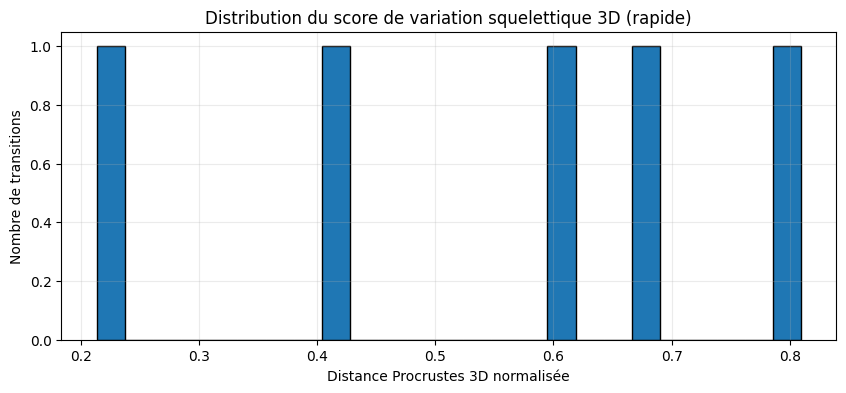

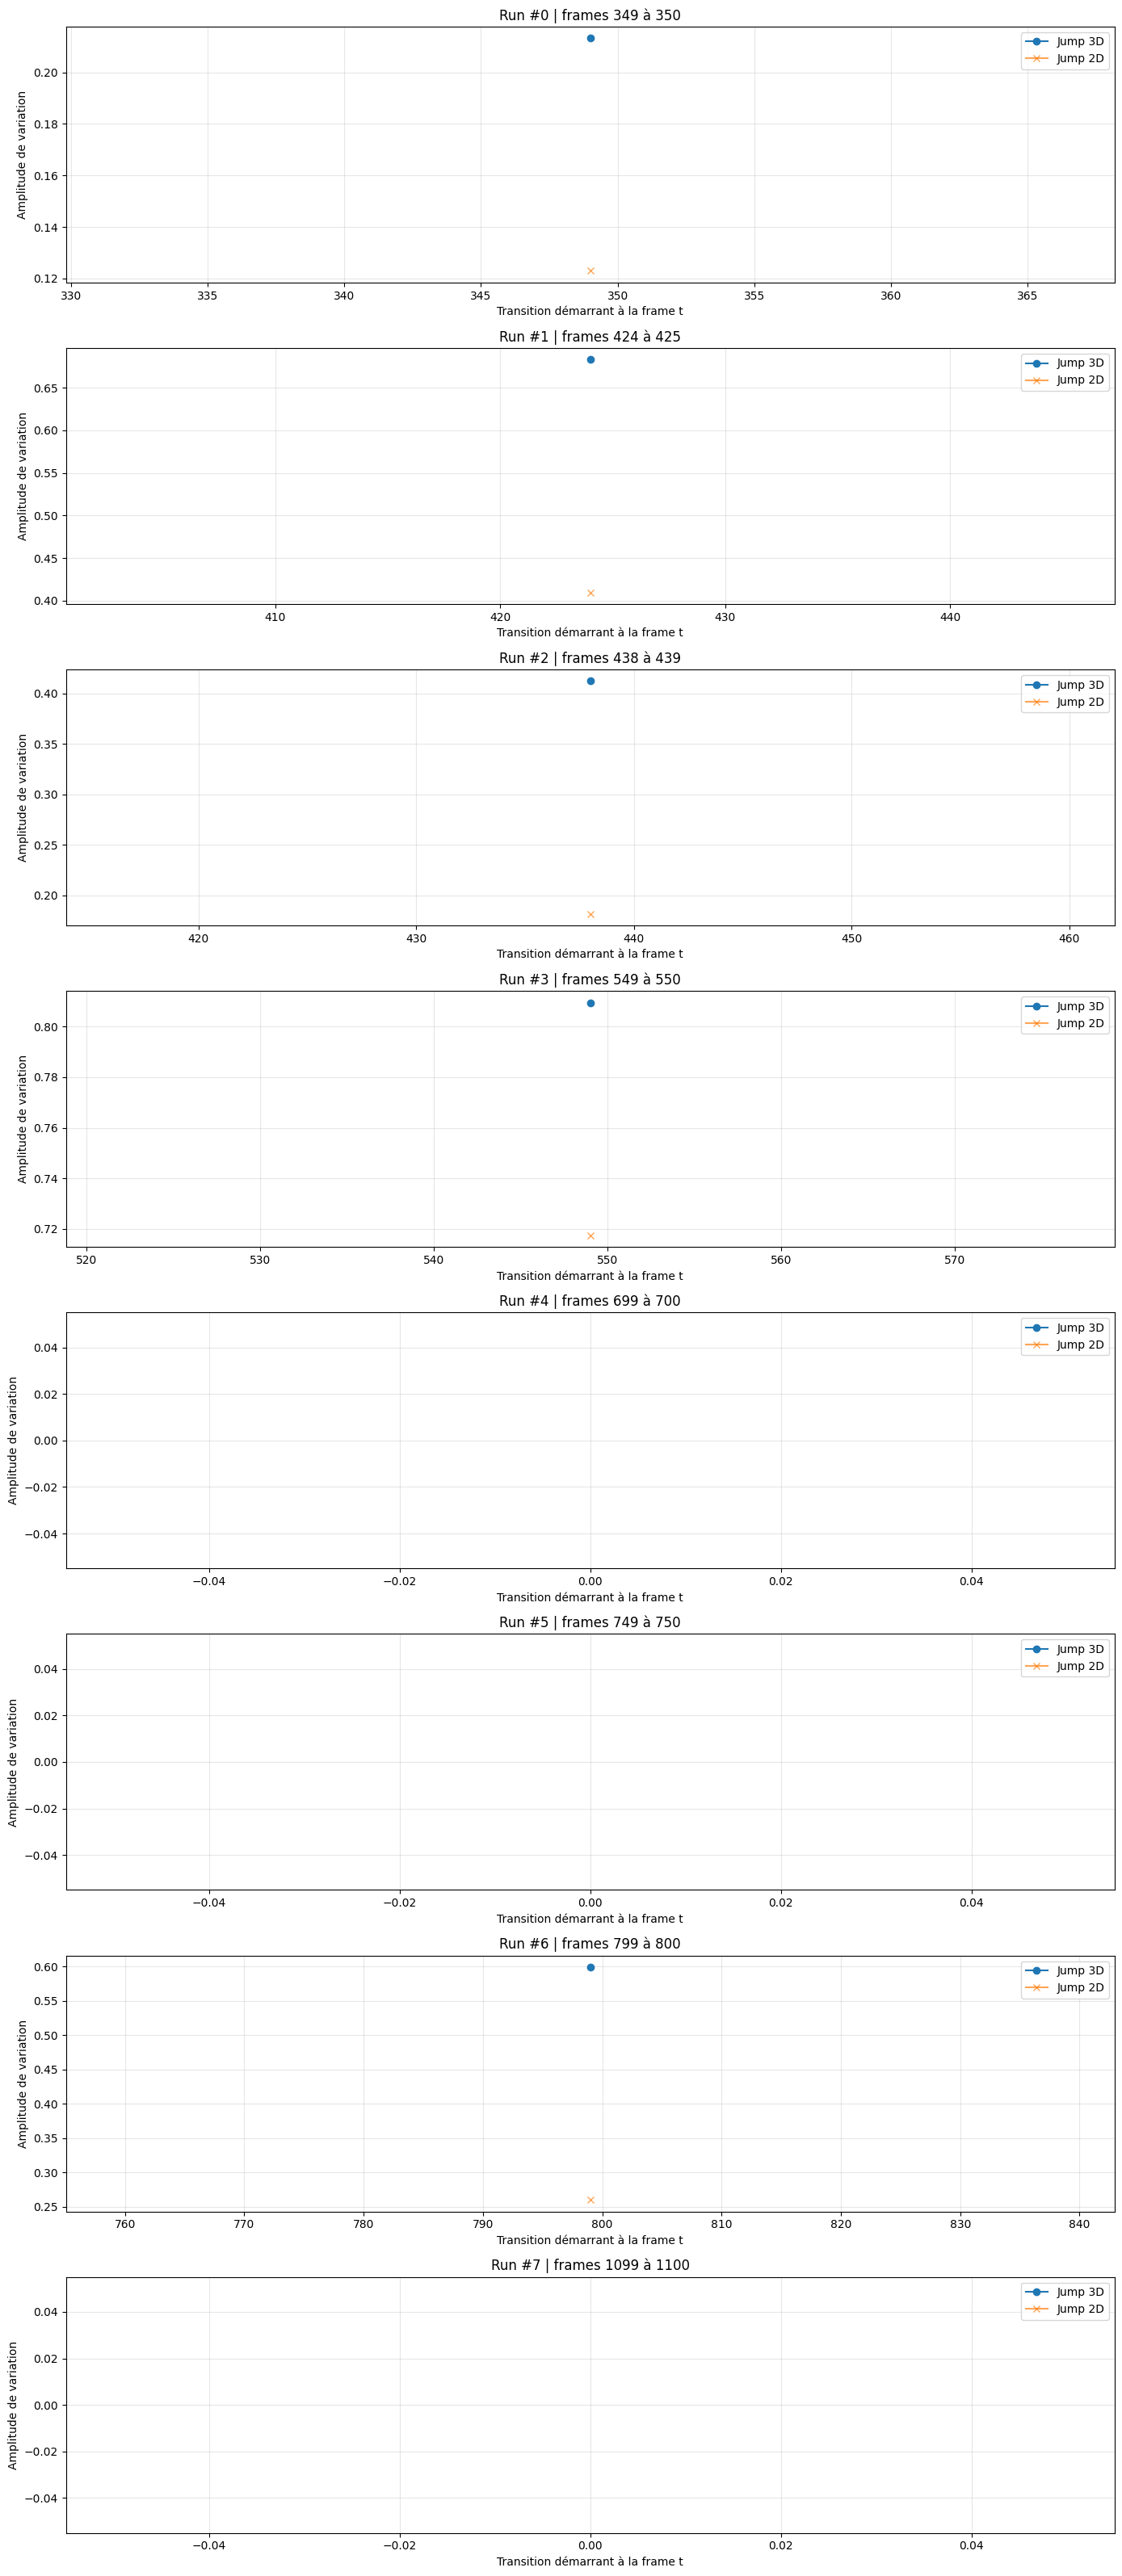


Transition rapide n°1
Run #3 | 549 -> 550
Score 3D : 0.809540
Score 2D : 0.717363


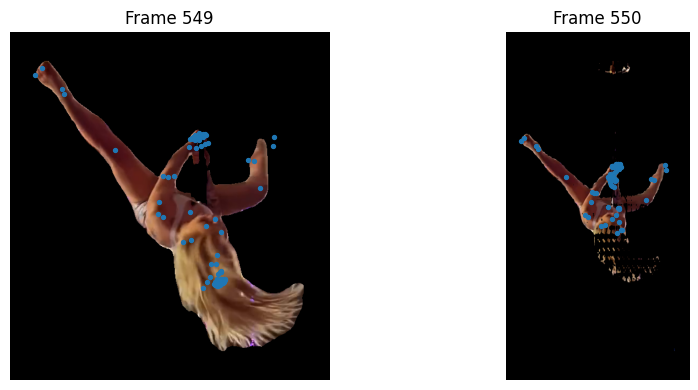


Transition rapide n°2
Run #1 | 424 -> 425
Score 3D : 0.683053
Score 2D : 0.409862


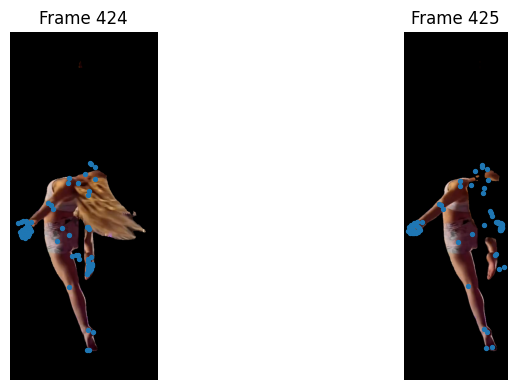


Transition rapide n°3
Run #6 | 799 -> 800
Score 3D : 0.599298
Score 2D : 0.260288


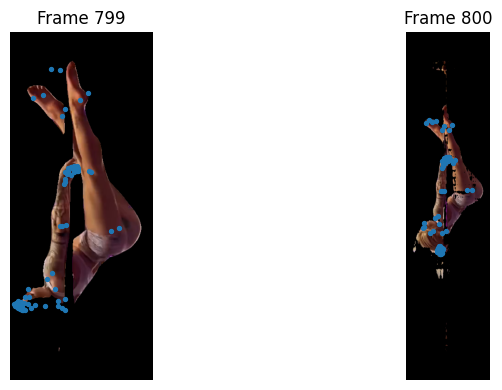

In [ ]:
error_runs_simple_fast = frame_runs_from_transition_indices(bad_frames_simple)

results_simple_fast = run_skeleton_metric_experiment_fast(
    error_runs_simple_fast,
    run_label="simple rapide",
    min_run_length=2,
    use_cache=True,
    force_recompute=False,
    show_plots=True,
    top_k=3,
)

skeleton_transitions_simple_fast = results_simple_fast["transitions"]
skeleton_cache_simple_fast = results_simple_fast["cache"]
skeleton_summary_simple_fast = results_simple_fast["summary"]

##### <u>Exécution 3 (via vérité terrain humaine) :</u>

Runs d'erreurs à partir de la vérité terrain humaine.

Succès : 1329 frames annotées chargées.
Runs d'erreurs (vérité terrain rapide) : [(0, 0), (50, 50), (57, 57), (70, 71), (73, 76), (100, 100), (108, 108), (117, 117), (128, 129), (150, 150)]
Nombre total de frames à traiter par SAM 3D Body : 477


SAM 3D Body inference (fast):   0%|          | 0/477 [00:00<?, ?it/s]

frame_00070 = Found boxes: [[ 26.82  80.01 300.19 896.27]]
frame_00071 = Found boxes: [[ 27.15  79.6  301.28 900.95]]
frame_00073 = Found boxes: [[ 26.82  80.57 292.72 911.29]]
frame_00074 = Found boxes: [[ 25.26  82.33 279.99 918.31]]
frame_00075 = Found boxes: [[ 24.11  83.57 266.56 927.69]]
frame_00076 = Found boxes: [[ 22.38  82.26 248.83 931.48]]
frame_00128 = Found boxes: [[ 32.93  80.24 366.37 897.88]]
frame_00129 = Found boxes: [[ 32.78  81.99 343.9  906.05]]
frame_00239 = Found boxes: [[ 65.34  71.2  743.68 790.11]]
frame_00240 = Found boxes: [[ 63.26 279.92 724.58 999.18]]
frame_00241 = Found boxes: [[ 59.34  69.58 687.14 790.33]]
frame_00242 = Found boxes: [[ 61.88 272.47 716.58 993.03]]
frame_00243 = Found boxes: [[ 57.75 280.02 654.57 999.99]]
frame_00244 = Found boxes: [[ 53.42 278.98 606.91 991.7 ]]
frame_00329 = Found boxes: [[ 39.15 330.67 453.53 970.42]]
frame_00330 = Found boxes: [[ 43.77  62.63 500.94 693.56]]
frame_00350 = cache hit
frame_00351 = Found boxes: [[ 15

,run_id,run_start,run_end,n_transitions,mean_jump_3d,max_jump_3d,mean_jump_2d,max_jump_2d,peak_transition_starts_at
0,3,70,71,1,0.493030,0.493030,0.042692,0.042692,70
1,4,73,76,3,0.093110,0.159833,0.035360,0.037991,74
2,8,128,129,1,0.146481,0.146481,0.043432,0.043432,128
3,11,239,244,5,0.208991,0.288821,0.052224,0.062636,243
4,17,329,330,1,0.128526,0.128526,0.072998,0.072998,329
5,18,350,401,51,0.404391,1.208939,0.222111,0.849096,367
6,20,415,416,1,0.188171,0.188171,0.026162,0.026162,415
7,21,425,426,1,0.319558,0.319558,0.096510,0.096510,425
8,22,436,437,1,0.455581,0.455581,0.262528,0.262528,436
9,23,439,442,3,0.417722,0.624816,0.274772,0.405051,441


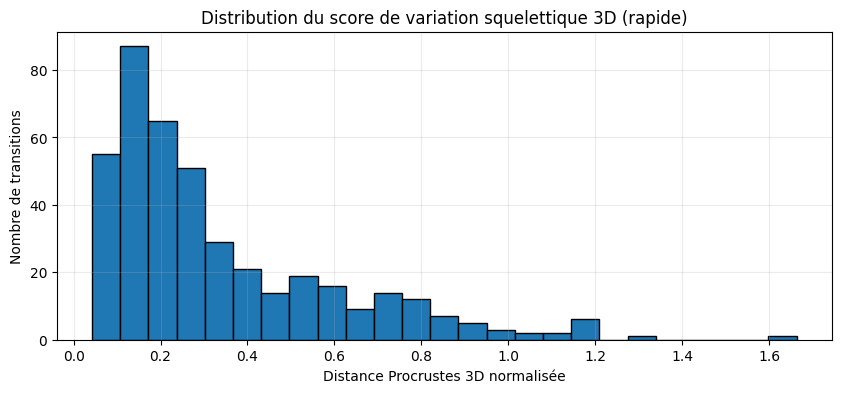

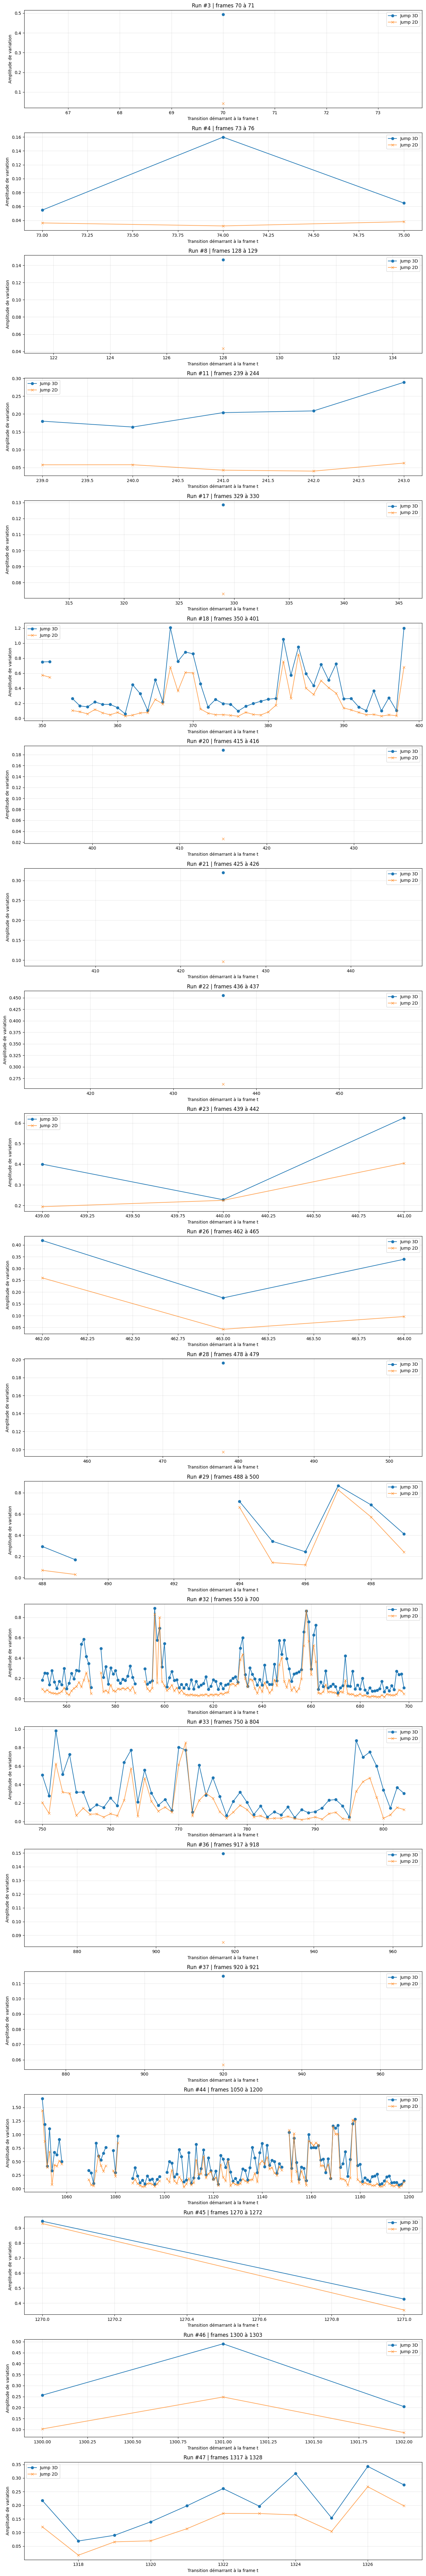


Transition rapide n°1
Run #44 | 1050 -> 1051
Score 3D : 1.663381
Score 2D : 1.442032


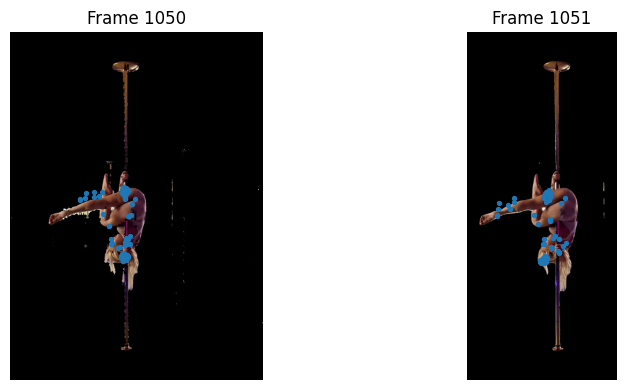


Transition rapide n°2
Run #44 | 1178 -> 1179
Score 3D : 1.286475
Score 2D : 1.247488


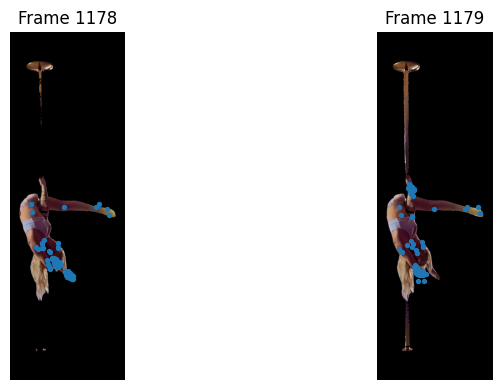


Transition rapide n°3
Run #18 | 367 -> 368
Score 3D : 1.208939
Score 2D : 0.678531


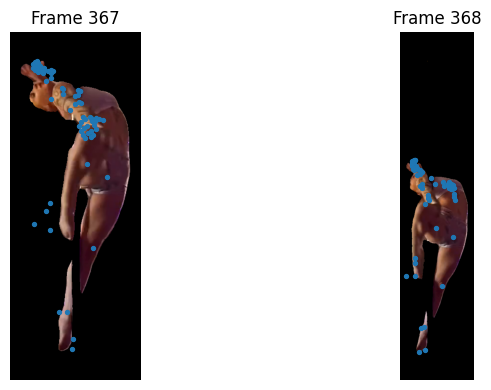

In [ ]:
ground_truth_fast = load_annotations_csv(ANNOTATIONS_PATH)
error_runs_gt_fast = frame_runs_from_annotations(ground_truth_fast, error_value=0) if ground_truth_fast is not None else []

results_gt_fast = run_skeleton_metric_experiment_fast(
    error_runs_gt_fast,
    run_label="vérité terrain rapide",
    min_run_length=2,
    use_cache=True,
    force_recompute=False,
    show_plots=True,
    top_k=3,
)

skeleton_transitions_gt_fast = results_gt_fast["transitions"]
skeleton_cache_gt_fast = results_gt_fast["cache"]
skeleton_summary_gt_fast = results_gt_fast["summary"]

#### D. Calcul et visualisation de la variation du squelette sur des runs d'erreurs (version longue)

##### <u>Fonctions utilitaires :</u>

In [ ]:
SKELETON_TRANSITION_COLUMNS = [
    "set_name",
    "run_id",
    "frame_t",
    "frame_t1",
    "skeleton_jump_3d",
    "skeleton_jump_2d",
    "valid_joint_ratio_t",
    "valid_joint_ratio_t1",
    "validity_jump",
    "num_valid_joints_3d",
    "num_valid_joints_2d",
    "mask_area_t",
    "mask_area_t1",
    "has_skeleton_t",
    "has_skeleton_t1",
    "transition_has_both_skeletons",
    "transition_missing_skeleton",
]

def empty_skeleton_transitions_df():
    return pd.DataFrame(columns=SKELETON_TRANSITION_COLUMNS)

def build_control_transition_indices(num_frames, error_runs, max_samples=200, random_state=0):
    """
    Construit un petit ensemble témoin de transitions hors runs d'erreurs.
    Sert uniquement à évaluer si la métrique sépare ou non les zones d'erreurs
    du reste de la vidéo.
    """
    if num_frames < 2:
        return []

    forbidden = np.zeros(num_frames - 1, dtype=bool)

    for start, end in error_runs:
        if end - start + 1 < 2:
            continue
        forbidden[start:end] = True

    available = np.where(~forbidden)[0].tolist()

    if len(available) == 0:
        return []

    if len(available) <= max_samples:
        return available

    rng = np.random.default_rng(random_state)
    return sorted(rng.choice(available, size=max_samples, replace=False).tolist())

def compute_skeleton_metric_on_transition_indices(
    transition_indices,
    run_lookup=None,
    set_name="error",
    use_cache=True,
    force_recompute=False,
):
    """
    Calcule la métrique de variation squelettique sur une liste de transitions t -> t+1.
    Retourne :
      - transitions_df : un DataFrame détaillé transition par transition
      - cache : résultats intermédiaires par frame
    """
    transition_indices = sorted(set(int(t) for t in transition_indices if int(t) >= 0))

    if len(transition_indices) == 0:
        return empty_skeleton_transitions_df(), {}

    frame_indices = set()
    for t in transition_indices:
        frame_indices.add(int(t))
        frame_indices.add(int(t) + 1)

    frame_indices = sorted(frame_indices)

    cache = {}

    print(f"Nombre total de frames à traiter par SAM 3D Body : {len(frame_indices)}")

    for frame_idx in tqdm(frame_indices, desc="SAM 3D Body inference"):
        crop_rgb, meta = build_cutout_crop_from_index(frame_idx)

        if crop_rgb is None:
            cache[frame_idx] = {
                "crop_rgb": None,
                "meta": meta,
                "skeleton": None,
            }
            continue

        try:
            skeleton = infer_skeleton_on_cutout_rgb(
                crop_rgb,
                frame_idx=frame_idx,
                use_cache=use_cache,
                force_recompute=force_recompute,
            )
        except Exception as e:
            print(f"Erreur d'inférence sur la frame {frame_idx} : {e}")
            skeleton = None

        cache[frame_idx] = {
            "crop_rgb": crop_rgb,
            "meta": meta,
            "skeleton": skeleton,
        }

    rows = []

    for t in transition_indices:
        s_t = cache.get(t, {}).get("skeleton", None)
        s_t1 = cache.get(t + 1, {}).get("skeleton", None)

        has_skeleton_t = s_t is not None
        has_skeleton_t1 = s_t1 is not None
        transition_has_both_skeletons = bool(has_skeleton_t and has_skeleton_t1)
        transition_missing_skeleton = bool(not transition_has_both_skeletons)

        k3d_t = None if s_t is None else s_t.get("pred_keypoints_3d", None)
        k3d_t1 = None if s_t1 is None else s_t1.get("pred_keypoints_3d", None)

        k2d_t = None if s_t is None else s_t.get("pred_keypoints_2d", None)
        k2d_t1 = None if s_t1 is None else s_t1.get("pred_keypoints_2d", None)

        score_3d, per_joint_3d = procrustes_distance_3d(k3d_t, k3d_t1)
        score_2d, per_joint_2d = normalized_distance_2d(k2d_t, k2d_t1)

        valid_ratio_t = valid_joint_ratio(k3d_t)
        valid_ratio_t1 = valid_joint_ratio(k3d_t1)

        validity_jump = (
            np.nan
            if (np.isnan(valid_ratio_t) or np.isnan(valid_ratio_t1))
            else float(abs(valid_ratio_t - valid_ratio_t1))
        )

        rows.append({
            "set_name": set_name,
            "run_id": np.nan if run_lookup is None else run_lookup.get(int(t), np.nan),
            "frame_t": int(t),
            "frame_t1": int(t + 1),
            "skeleton_jump_3d": score_3d,
            "skeleton_jump_2d": score_2d,
            "valid_joint_ratio_t": valid_ratio_t,
            "valid_joint_ratio_t1": valid_ratio_t1,
            "validity_jump": validity_jump,
            "num_valid_joints_3d": None if per_joint_3d is None else int(len(per_joint_3d)),
            "num_valid_joints_2d": None if per_joint_2d is None else int(len(per_joint_2d)),
            "mask_area_t": None if cache.get(t, {}).get("meta", None) is None else int(cache[t]["meta"]["mask_area_px"]),
            "mask_area_t1": None if cache.get(t + 1, {}).get("meta", None) is None else int(cache[t + 1]["meta"]["mask_area_px"]),
            "has_skeleton_t": has_skeleton_t,
            "has_skeleton_t1": has_skeleton_t1,
            "transition_has_both_skeletons": transition_has_both_skeletons,
            "transition_missing_skeleton": transition_missing_skeleton,
        })

    if len(rows) == 0:
        return empty_skeleton_transitions_df(), cache

    transitions_df = pd.DataFrame(rows, columns=SKELETON_TRANSITION_COLUMNS)
    return transitions_df, cache

def compute_skeleton_metric_on_runs(
    error_runs,
    min_run_length=2,
    use_cache=True,
    force_recompute=False,
):
    """
    Pour chaque run d'erreurs (start, end), calcule les scores de variation
    squelettique sur chaque transition consécutive t -> t+1.
    """
    transition_indices, run_lookup = transition_indices_from_runs(
        error_runs,
        min_run_length=min_run_length,
    )

    return compute_skeleton_metric_on_transition_indices(
        transition_indices,
        run_lookup=run_lookup,
        set_name="error",
        use_cache=use_cache,
        force_recompute=force_recompute,
    )

def summarize_skeleton_metric(transitions_df):
    """
    Résume la métrique run par run, en rendant explicites
    les transitions où le squelette n'a pas pu être reconstruit.
    """
    out_cols = [
        "run_id",
        "start_frame",
        "end_frame",
        "num_transitions",
        "num_missing_skeleton",
        "missing_skeleton_rate",
        "num_valid_scores_3d",
        "num_valid_scores_2d",
        "mean_jump_3d",
        "median_jump_3d",
        "max_jump_3d",
        "mean_jump_2d",
        "median_jump_2d",
        "max_jump_2d",
        "peak_transition_starts_at",
    ]

    if transitions_df is None or len(transitions_df) == 0:
        return pd.DataFrame(columns=out_cols)

    if "run_id" not in transitions_df.columns:
        return pd.DataFrame(columns=out_cols)

    rows = []

    for run_id, sub in transitions_df.groupby("run_id", dropna=False):
        sub = sub.sort_values("frame_t").copy()

        valid3d = sub["skeleton_jump_3d"].dropna()
        valid2d = sub["skeleton_jump_2d"].dropna()

        if len(valid3d) > 0:
            peak_idx = sub["skeleton_jump_3d"].astype(float).idxmax()
            peak_transition = int(sub.loc[peak_idx, "frame_t"])
            max_jump_3d = float(sub.loc[peak_idx, "skeleton_jump_3d"])
        else:
            peak_transition = np.nan
            max_jump_3d = np.nan

        rows.append({
            "run_id": run_id,
            "start_frame": int(sub["frame_t"].min()),
            "end_frame": int(sub["frame_t1"].max()),
            "num_transitions": int(len(sub)),
            "num_missing_skeleton": int(sub["transition_missing_skeleton"].sum()) if "transition_missing_skeleton" in sub.columns else 0,
            "missing_skeleton_rate": float(sub["transition_missing_skeleton"].mean()) if "transition_missing_skeleton" in sub.columns else np.nan,
            "num_valid_scores_3d": int(valid3d.shape[0]),
            "num_valid_scores_2d": int(valid2d.shape[0]),
            "mean_jump_3d": float(valid3d.mean()) if len(valid3d) > 0 else np.nan,
            "median_jump_3d": float(np.median(valid3d)) if len(valid3d) > 0 else np.nan,
            "max_jump_3d": max_jump_3d,
            "mean_jump_2d": float(valid2d.mean()) if len(valid2d) > 0 else np.nan,
            "median_jump_2d": float(np.median(valid2d)) if len(valid2d) > 0 else np.nan,
            "max_jump_2d": float(valid2d.max()) if len(valid2d) > 0 else np.nan,
            "peak_transition_starts_at": peak_transition,
        })

    return pd.DataFrame(rows, columns=out_cols)

def compare_error_vs_control(error_df, control_df, score_col="skeleton_jump_3d"):
    """
    Compare la distribution de la métrique sur les runs d'erreurs
    à un petit échantillon témoin hors runs.
    """
    out_cols = [
        "set_name",
        "n",
        "mean",
        "median",
        "std",
        "q90",
        "error_above_control_q90",
        "cohen_d_error_vs_control",
    ]

    rows = []

    for set_name, df in [("error", error_df), ("control", control_df)]:
        if df is None or len(df) == 0 or score_col not in df.columns:
            continue

        vals = df[score_col].dropna().to_numpy(dtype=float)
        if len(vals) == 0:
            continue

        rows.append({
            "set_name": set_name,
            "n": int(len(vals)),
            "mean": float(vals.mean()),
            "median": float(np.median(vals)),
            "std": float(vals.std()),
            "q90": float(np.quantile(vals, 0.90)),
            "error_above_control_q90": np.nan,
            "cohen_d_error_vs_control": np.nan,
        })

    summary = pd.DataFrame(rows, columns=out_cols)

    if len(summary) == 0:
        return summary

    has_error = (
        error_df is not None and len(error_df) > 0 and score_col in error_df.columns
    )
    has_control = (
        control_df is not None and len(control_df) > 0 and score_col in control_df.columns
    )

    if has_error and has_control:
        error_vals = error_df[score_col].dropna().to_numpy(dtype=float)
        control_vals = control_df[score_col].dropna().to_numpy(dtype=float)

        if len(error_vals) > 0 and len(control_vals) > 0:
            q90_control = float(np.quantile(control_vals, 0.90))
            error_above_control_q90 = float((error_vals > q90_control).mean())

            pooled_std = (
                np.sqrt((error_vals.var() + control_vals.var()) / 2.0)
                if len(error_vals) > 1 and len(control_vals) > 1
                else np.nan
            )

            cohen_d = (
                np.nan
                if (not np.isfinite(pooled_std) or pooled_std < 1e-12)
                else float((error_vals.mean() - control_vals.mean()) / pooled_std)
            )

            summary.loc[summary["set_name"] == "error", "error_above_control_q90"] = error_above_control_q90
            summary.loc[summary["set_name"] == "error", "cohen_d_error_vs_control"] = cohen_d

    return summary

def plot_skeleton_metric(error_df, control_df=None, score_col="skeleton_jump_3d"):
    """
    Affiche :
      - la série temporelle des scores sur les transitions d'erreur
      - la comparaison erreur / témoin
    Les transitions sans squelette sont marquées explicitement.
    """
    if error_df is None or len(error_df) == 0 or score_col not in error_df.columns:
        print("Aucune donnée d'erreur à afficher.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # (1) Série temporelle
    ax = axes[0]
    df_e = error_df.sort_values("frame_t").copy()

    valid = df_e[score_col].notna()

    if valid.any():
        ax.plot(
            df_e.loc[valid, "frame_t"],
            df_e.loc[valid, score_col],
            linewidth=2,
            label="Erreur (score valide)",
        )
        ax.scatter(
            df_e.loc[valid, "frame_t"],
            df_e.loc[valid, score_col],
            s=30,
        )

    if "transition_missing_skeleton" in df_e.columns:
        missing_mask = df_e["transition_missing_skeleton"].astype(bool)
        missing_x = df_e.loc[missing_mask, "frame_t"].to_numpy(dtype=int)

        if len(missing_x) > 0:
            y0 = 0.0
            if valid.any():
                ymin = float(df_e.loc[valid, score_col].min())
                ymax = float(df_e.loc[valid, score_col].max())
                y0 = ymin - 0.08 * max(ymax - ymin, 1e-6)

            ax.scatter(
                missing_x,
                np.full(len(missing_x), y0),
                marker="x",
                s=80,
                color="crimson",
                label="Transition sans squelette",
            )

    ax.set_xlabel("frame_t")
    ax.set_ylabel(score_col)
    ax.set_title(f"Sauts du squelette ({score_col})")
    ax.grid(True, alpha=0.25)
    ax.legend()

    # (2) Comparaison erreur / témoin
    ax = axes[1]

    data = []
    labels = []

    vals_e = error_df[score_col].dropna().to_numpy(dtype=float)
    if len(vals_e) > 0:
        data.append(vals_e)
        labels.append("Erreur")

    if control_df is not None and len(control_df) > 0 and score_col in control_df.columns:
        vals_c = control_df[score_col].dropna().to_numpy(dtype=float)
        if len(vals_c) > 0:
            data.append(vals_c)
            labels.append("Témoin")

    if len(data) > 0:
        ax.boxplot(data, tick_labels=labels)
        ax.set_title("Comparaison erreur / témoin")
        ax.set_ylabel(score_col)
        ax.grid(True, axis="y", alpha=0.25)
    else:
        ax.set_title("Aucune comparaison disponible")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

def plot_skeleton_metric_per_run(transitions_df):
    if transitions_df is None or len(transitions_df) == 0:
        print("Aucune transition disponible.")
        return

    run_groups = list(transitions_df.groupby("run_id", dropna=False))
    n = len(run_groups)

    fig, axes = plt.subplots(n, 1, figsize=(14, 4 * n), squeeze=False)

    for ax, (run_id, group) in zip(axes[:, 0], run_groups):
        group = group.sort_values("frame_t")

        ax.plot(group["frame_t"], group["skeleton_jump_3d"], marker="o", label="Jump 3D")
        ax.plot(group["frame_t"], group["skeleton_jump_2d"], marker="x", alpha=0.7, label="Jump 2D")

        ax.set_title(
            f"Run #{int(run_id) if pd.notna(run_id) else 'NA'} | "
            f"frames {int(group['frame_t'].min())} à {int(group['frame_t1'].max())}"
        )
        ax.set_xlabel("Transition démarrant à la frame t")
        ax.set_ylabel("Amplitude de variation")
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()

def visualize_top_skeletal_jumps(transitions_df, cache, top_k=5, show_vertices=True):
    if transitions_df is None or len(transitions_df) == 0:
        print("Aucune transition à visualiser.")
        return

    df = transitions_df.dropna(subset=["skeleton_jump_3d"]).copy()
    if len(df) == 0:
        print("Aucun score 3D valide.")
        return

    df = df.sort_values("skeleton_jump_3d", ascending=False).head(top_k)

    for rank, row in enumerate(df.itertuples(index=False), start=1):
        t = int(row.frame_t)
        t1 = int(row.frame_t1)

        crop_t = cache.get(t, {}).get("crop_rgb", None)
        crop_t1 = cache.get(t1, {}).get("crop_rgb", None)

        skel_t = cache.get(t, {}).get("skeleton", None)
        skel_t1 = cache.get(t1, {}).get("skeleton", None)

        k2d_t = None if skel_t is None else skel_t.get("pred_keypoints_2d", None)
        k2d_t1 = None if skel_t1 is None else skel_t1.get("pred_keypoints_2d", None)

        print(f"\nTransition anormale n°{rank}")
        print(f"Run #{row.run_id} | {t} -> {t1}")
        print(f"Score 3D      : {row.skeleton_jump_3d:.6f}")
        print(f"Score 2D      : {row.skeleton_jump_2d:.6f}")
        print(
            f"Validity jump : {row.validity_jump:.6f}"
            if pd.notna(row.validity_jump)
            else "Validity jump : NaN"
        )

        fig = plt.figure(figsize=(14, 10))

        ax1 = fig.add_subplot(2, 2, 1)
        ax2 = fig.add_subplot(2, 2, 2)
        ax3 = fig.add_subplot(2, 2, 3, projection="3d")
        ax4 = fig.add_subplot(2, 2, 4, projection="3d")

        if crop_t is not None:
            draw_keypoints_2d(ax1, crop_t, k2d_t, title=f"Frame {t} (2D)")
        else:
            ax1.set_title(f"Frame {t} (crop absent)")
            ax1.axis("off")

        if crop_t1 is not None:
            draw_keypoints_2d(ax2, crop_t1, k2d_t1, title=f"Frame {t1} (2D)")
        else:
            ax2.set_title(f"Frame {t1} (crop absent)")
            ax2.axis("off")

        draw_skeleton_3d(
            ax3,
            skel_t,
            title=f"Frame {t} (3D)",
            show_vertices=show_vertices,
        )
        draw_skeleton_3d(
            ax4,
            skel_t1,
            title=f"Frame {t1} (3D)",
            show_vertices=show_vertices,
        )

        plt.tight_layout()
        plt.show()

def plot_skeleton_metric_distributions(
    error_df,
    control_df=None,
    score_col="skeleton_jump_3d",
    bins=25,
):
    """
    Affiche la distribution de la métrique sur les transitions d'erreur
    et, si disponible, sur un jeu témoin.
    """
    if error_df is None or len(error_df) == 0 or score_col not in error_df.columns:
        print("Aucune donnée d'erreur disponible pour l'histogramme.")
        return

    error_vals = error_df[score_col].dropna().to_numpy(dtype=float)

    if len(error_vals) == 0:
        print("Aucune valeur valide côté erreur.")
        return

    plt.figure(figsize=(12, 5))

    plt.hist(
        error_vals,
        bins=bins,
        alpha=0.55,
        density=True,
        label="Erreur",
        edgecolor="black",
    )

    plt.axvline(
        error_vals.mean(),
        linestyle="--",
        linewidth=2,
        label=f"Moyenne erreur ({error_vals.mean():.4f})",
    )

    if control_df is not None and len(control_df) > 0 and score_col in control_df.columns:
        control_vals = control_df[score_col].dropna().to_numpy(dtype=float)

        if len(control_vals) > 0:
            plt.hist(
                control_vals,
                bins=bins,
                alpha=0.45,
                density=True,
                label="Témoin",
                edgecolor="black",
            )

            plt.axvline(
                control_vals.mean(),
                linestyle=":",
                linewidth=2,
                label=f"Moyenne témoin ({control_vals.mean():.4f})",
            )

    plt.xlabel(score_col)
    plt.ylabel("Densité")
    plt.title(f"Distribution de {score_col} : erreurs vs témoin")
    plt.legend()
    plt.grid(True, alpha=0.25)
    plt.show()


def plot_skeleton_3d_vs_2d(
    error_df,
    control_df=None,
    x_col="skeleton_jump_2d",
    y_col="skeleton_jump_3d",
):
    """
    Scatterplot comparant la variation 2D et 3D du squelette.
    """
    has_error = (
        error_df is not None
        and len(error_df) > 0
        and x_col in error_df.columns
        and y_col in error_df.columns
    )

    has_control = (
        control_df is not None
        and len(control_df) > 0
        and x_col in control_df.columns
        and y_col in control_df.columns
    )

    if not has_error and not has_control:
        print("Aucune donnée disponible pour le scatterplot 2D vs 3D.")
        return

    plt.figure(figsize=(8, 6))

    if has_error:
        df_e = error_df[[x_col, y_col]].dropna()
        if len(df_e) > 0:
            plt.scatter(
                df_e[x_col],
                df_e[y_col],
                s=28,
                alpha=0.7,
                label="Erreur",
            )

    if has_control:
        df_c = control_df[[x_col, y_col]].dropna()
        if len(df_c) > 0:
            plt.scatter(
                df_c[x_col],
                df_c[y_col],
                s=28,
                alpha=0.5,
                label="Témoin",
            )

    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title("Comparaison variation 2D / variation 3D")
    plt.legend()
    plt.grid(True, alpha=0.25)
    plt.show()


def plot_skeleton_metric_heatmap_per_run(
    error_df,
    score_col="skeleton_jump_3d",
):
    """
    Affichage adaptatif :
    - si les runs sont très courts, on affiche un bar chart
    - sinon, on garde la heatmap
    """
    if error_df is None or len(error_df) == 0 or score_col not in error_df.columns:
        print("Aucune donnée disponible pour la visualisation par run.")
        return

    df = error_df.copy()

    if "run_id" not in df.columns:
        print("La colonne 'run_id' est absente.")
        return

    df = df.dropna(subset=["run_id"]).copy()
    if len(df) == 0:
        print("Aucune valeur valide.")
        return

    run_sizes = df.groupby("run_id").size()

    # Si les runs sont très courts, un bar chart est plus compréhensible
    if run_sizes.max() <= 2:
        df_bar = df.dropna(subset=[score_col]).copy()

        if len(df_bar) == 0:
            print("Aucune valeur valide pour le bar chart.")
            return

        labels = [
            f"run {int(r.run_id)}\n{int(r.frame_t)}->{int(r.frame_t1)}"
            for r in df_bar.itertuples(index=False)
        ]
        values = df_bar[score_col].to_numpy(dtype=float)
        colors = [
            "crimson" if ("transition_missing_skeleton" in df_bar.columns and bool(v))
            else "steelblue"
            for v in df_bar.get("transition_missing_skeleton", [False] * len(df_bar))
        ]

        plt.figure(figsize=(12, 5))
        plt.bar(np.arange(len(values)), values, color=colors)

        plt.xticks(np.arange(len(values)), labels, rotation=45, ha="right")
        plt.ylabel(score_col)
        plt.title(f"{score_col} par run / transition")
        plt.grid(True, axis="y", alpha=0.25)
        plt.tight_layout()
        plt.show()
        return

    # Sinon : vraie heatmap
    df = df.dropna(subset=[score_col]).copy()
    if len(df) == 0:
        print("Aucune valeur valide pour la heatmap.")
        return

    df["run_id"] = df["run_id"].astype(int)
    df = df.sort_values(by=["run_id", "frame_t"]).reset_index(drop=True)
    df["local_transition_idx"] = df.groupby("run_id").cumcount()

    pivot = df.pivot(
        index="run_id",
        columns="local_transition_idx",
        values=score_col
    )

    mat = pivot.to_numpy(dtype=float)

    plt.figure(figsize=(12, max(4, 0.6 * len(pivot))))
    plt.imshow(mat, aspect="auto", interpolation="nearest")
    plt.colorbar(label=score_col)

    plt.xlabel("Index local de transition dans le run")
    plt.ylabel("run_id")
    plt.title(f"Heatmap de {score_col} par run")

    plt.yticks(
        ticks=np.arange(len(pivot.index)),
        labels=[str(r) for r in pivot.index]
    )

    plt.tight_layout()
    plt.show()

def plot_skeleton_metric_timeline_full_video(
    transitions_df,
    num_frames,
    score_col="skeleton_jump_3d",
    title_suffix="",
    show_points=True,
):
    """
    Affiche la métrique sur l'axe complet de la vidéo.
    Les transitions non analysées restent à NaN.
    """
    if transitions_df is None or len(transitions_df) == 0 or score_col not in transitions_df.columns:
        print("Aucune donnée disponible pour la timeline.")
        return

    y = np.full(num_frames - 1, np.nan, dtype=float)

    df = transitions_df.dropna(subset=["frame_t"]).copy()
    if len(df) == 0:
        print("Aucune valeur valide dans transitions_df.")
        return

    for row in df.itertuples(index=False):
        t = int(row.frame_t)
        if 0 <= t < len(y):
            val = getattr(row, score_col)
            y[t] = np.nan if pd.isna(val) else float(val)

    plt.figure(figsize=(16, 5))
    plt.plot(np.arange(len(y)), y, linewidth=1.5, alpha=0.9)

    if show_points:
        valid = np.isfinite(y)
        plt.scatter(np.arange(len(y))[valid], y[valid], s=18, label="Score valide")

    # Marquage explicite des transitions sans squelette
    if "transition_missing_skeleton" in df.columns:
        missing_rows = df[df["transition_missing_skeleton"].astype(bool)]
        if len(missing_rows) > 0:
            missing_x = missing_rows["frame_t"].astype(int).to_numpy()

            y0 = 0.0
            valid = np.isfinite(y)
            if valid.any():
                ymin = float(np.nanmin(y))
                ymax = float(np.nanmax(y))
                y0 = ymin - 0.08 * max(ymax - ymin, 1e-6)

            plt.scatter(
                missing_x,
                np.full(len(missing_x), y0),
                marker="x",
                s=70,
                color="crimson",
                label="Transition sans squelette",
            )

    # Mise en évidence des runs étudiés
    if "run_id" in df.columns:
        for run_id, sub in df.groupby("run_id"):
            xmin = int(sub["frame_t"].min())
            xmax = int(sub["frame_t"].max())
            plt.axvspan(xmin - 0.5, xmax + 0.5, alpha=0.10)

    plt.xlabel("Transition t -> t+1 (index t)")
    plt.ylabel(score_col)
    plt.title(f"{score_col} sur la vidéo complète {title_suffix}")
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
def run_skeleton_metric_experiment(
    error_runs,
    run_label="exp",
    min_run_length=2,
    num_control_samples=200,
    use_cache=True,
    force_recompute=False,
    show_plots=True,
):
    """
    Exécute toute la chaîne de la métrique squelettique à partir d'une liste de runs d'erreurs.

    Retourne un dictionnaire contenant :
      - error_runs
      - skeleton_transitions
      - skeleton_cache
      - control_transitions
      - control_skeleton
      - skeleton_summary
      - skeleton_compare
    """
    print(f"Runs d'erreurs ({run_label}) :", error_runs[:10] if error_runs is not None else [])

    if error_runs is None or len(error_runs) == 0:
        print(f"Aucun run d'erreurs détecté pour {run_label}.")
        print("On saute donc le calcul SAM 3D Body pour cet exemple.")

        results = {
            "error_runs": [],
            "skeleton_transitions": empty_skeleton_transitions_df(),
            "skeleton_cache": {},
            "control_transitions": [],
            "control_skeleton": empty_skeleton_transitions_df(),
            "skeleton_summary": pd.DataFrame(),
            "skeleton_compare": pd.DataFrame(),
        }

        display(results["skeleton_summary"])
        display(results["skeleton_compare"])
        return results

    skeleton_transitions, skeleton_cache = compute_skeleton_metric_on_runs(
        error_runs,
        min_run_length=min_run_length,
        use_cache=use_cache,
        force_recompute=force_recompute,
    )

    control_transitions = build_control_transition_indices(
        num_frames=len(ORIGINAL_FRAME_FILES),
        error_runs=error_runs,
        max_samples=num_control_samples,
        random_state=0,
    )

    control_skeleton, _ = compute_skeleton_metric_on_transition_indices(
        control_transitions,
        run_lookup=None,
        set_name="control",
        use_cache=use_cache,
        force_recompute=force_recompute,
    )

    skeleton_summary = summarize_skeleton_metric(skeleton_transitions)
    skeleton_compare = compare_error_vs_control(
        skeleton_transitions,
        control_skeleton,
        score_col="skeleton_jump_3d",
    )

    display(skeleton_summary)
    display(skeleton_compare)

    if show_plots:
        plot_skeleton_metric(skeleton_transitions, control_skeleton)
        plot_skeleton_metric_per_run(skeleton_transitions)
        visualize_top_skeletal_jumps(skeleton_transitions, skeleton_cache, top_k=5)

        plot_skeleton_metric_distributions(
            skeleton_transitions,
            control_skeleton,
            score_col="skeleton_jump_3d",
        )

        plot_skeleton_3d_vs_2d(
            skeleton_transitions,
            control_skeleton,
            x_col="skeleton_jump_2d",
            y_col="skeleton_jump_3d",
        )

        plot_skeleton_metric_heatmap_per_run(
            skeleton_transitions,
            score_col="skeleton_jump_3d",
        )

    return {
        "error_runs": error_runs,
        "skeleton_transitions": skeleton_transitions,
        "skeleton_cache": skeleton_cache,
        "control_transitions": control_transitions,
        "control_skeleton": control_skeleton,
        "skeleton_summary": skeleton_summary,
        "skeleton_compare": skeleton_compare,
    }

##### <u>Exécution 1 (frames jugées erronées) :</u>

Runs d'erreurs à partir des frames jugées erronées (`bad_frames_overlay`).

In [ ]:
error_runs_overlay = frame_runs_from_frame_indices(bad_frames_overlay)

results_overlay = run_skeleton_metric_experiment(
    error_runs_overlay,
    run_label="overlay",
    min_run_length=2,
    num_control_samples=80,
    use_cache=True,
    force_recompute=False,
    show_plots=True,
)

skeleton_transitions_overlay = results_overlay["skeleton_transitions"]
skeleton_cache_overlay = results_overlay["skeleton_cache"]
control_skeleton_overlay = results_overlay["control_skeleton"]
skeleton_summary_overlay = results_overlay["skeleton_summary"]
skeleton_compare_overlay = results_overlay["skeleton_compare"]

Runs d'erreurs (overlay) : []
Aucun run d'erreurs détecté pour overlay.
On saute donc le calcul SAM 3D Body pour cet exemple.


""


""


##### <u>Exécution 2 (transitions jugées anormales) :</u>

Runs d'erreurs à partir des transitions jugées anormales (`bad_frames_simple`).

Runs d'erreurs (simple) : [(349, 350), (424, 425), (438, 439), (549, 550), (699, 700), (749, 750), (799, 800), (1099, 1100)]
Nombre total de frames à traiter par SAM 3D Body : 16


SAM 3D Body inference:   0%|          | 0/16 [00:00<?, ?it/s]

frame_00349 = cache hit
frame_00350 = cache hit
frame_00424 = cache hit
frame_00425 = cache hit
frame_00438 = cache hit
frame_00439 = cache hit
frame_00549 = cache hit
frame_00550 = cache hit
frame_00699 = cache hit
frame_00700 = no box detected
frame_00749 = no box detected
frame_00750 = cache hit
frame_00799 = cache hit
frame_00800 = cache hit
frame_01099 = cache hit
frame_01100 = no box detected
Nombre total de frames à traiter par SAM 3D Body : 374


SAM 3D Body inference:   0%|          | 0/374 [00:00<?, ?it/s]

frame_00003 = Found boxes: [[ 28.79  76.74 326.3  850.38]]
frame_00004 = Found boxes: [[ 29.08  77.3  338.9  852.64]]
frame_00006 = Found boxes: [[ 29.03  77.61 360.22 856.17]]
frame_00007 = Found boxes: [[ 33.44  78.01 377.95 858.32]]
frame_00009 = Found boxes: [[ 34.3   79.15 387.13 874.72]]
frame_00010 = Found boxes: [[ 32.1   79.19 380.75 880.29]]
frame_00018 = Found boxes: [[ 22.99  79.7  263.93 905.72]]
frame_00019 = Found boxes: [[ 23.28  81.29 264.1  906.14]]
frame_00020 = Found boxes: [[ 18.71  81.9  259.2  906.03]]
frame_00021 = Found boxes: [[ 22.12  81.57 264.9  908.75]]
frame_00025 = Found boxes: [[ 21.9   84.37 265.29 915.59]]
frame_00026 = Found boxes: [[ 22.93  83.18 263.82 915.68]]
frame_00032 = Found boxes: [[ 28.41  85.31 309.07 916.55]]
frame_00033 = Found boxes: [[ 28.9   85.54 313.62 915.15]]
frame_00038 = Found boxes: [[ 28.11  82.83 314.28 897.08]]
frame_00039 = Found boxes: [[ 27.89  82.48 309.87 891.79]]
frame_00046 = Found boxes: [[ 21.06  74.66 229.01 839.9 

,run_id,start_frame,end_frame,num_transitions,num_missing_skeleton,missing_skeleton_rate,num_valid_scores_3d,num_valid_scores_2d,mean_jump_3d,median_jump_3d,max_jump_3d,mean_jump_2d,median_jump_2d,max_jump_2d,peak_transition_starts_at
0,0,349,350,1,0,0.0,1,1,0.213290,0.213290,0.213290,0.122971,0.122971,0.122971,349.0
1,1,424,425,1,0,0.0,1,1,0.683053,0.683053,0.683053,0.409862,0.409862,0.409862,424.0
2,2,438,439,1,0,0.0,1,1,0.412146,0.412146,0.412146,0.181472,0.181472,0.181472,438.0
3,3,549,550,1,0,0.0,1,1,0.809540,0.809540,0.809540,0.717363,0.717363,0.717363,549.0
4,4,699,700,1,1,1.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,5,749,750,1,1,1.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,6,799,800,1,0,0.0,1,1,0.599298,0.599298,0.599298,0.260288,0.260288,0.260288,799.0
7,7,1099,1100,1,1,1.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,set_name,n,mean,median,std,q90,error_above_control_q90,cohen_d_error_vs_control
0,error,5,0.543465,0.599298,0.209599,0.758946,0.2,0.997309
1,control,187,0.306934,0.210874,0.261853,0.732589,NaN,NaN


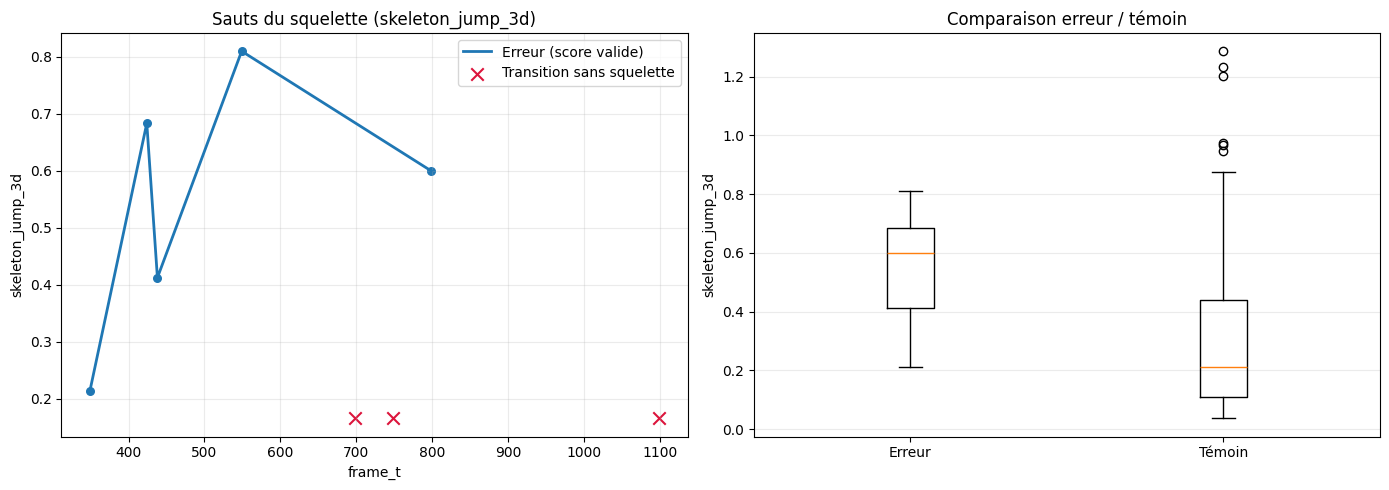

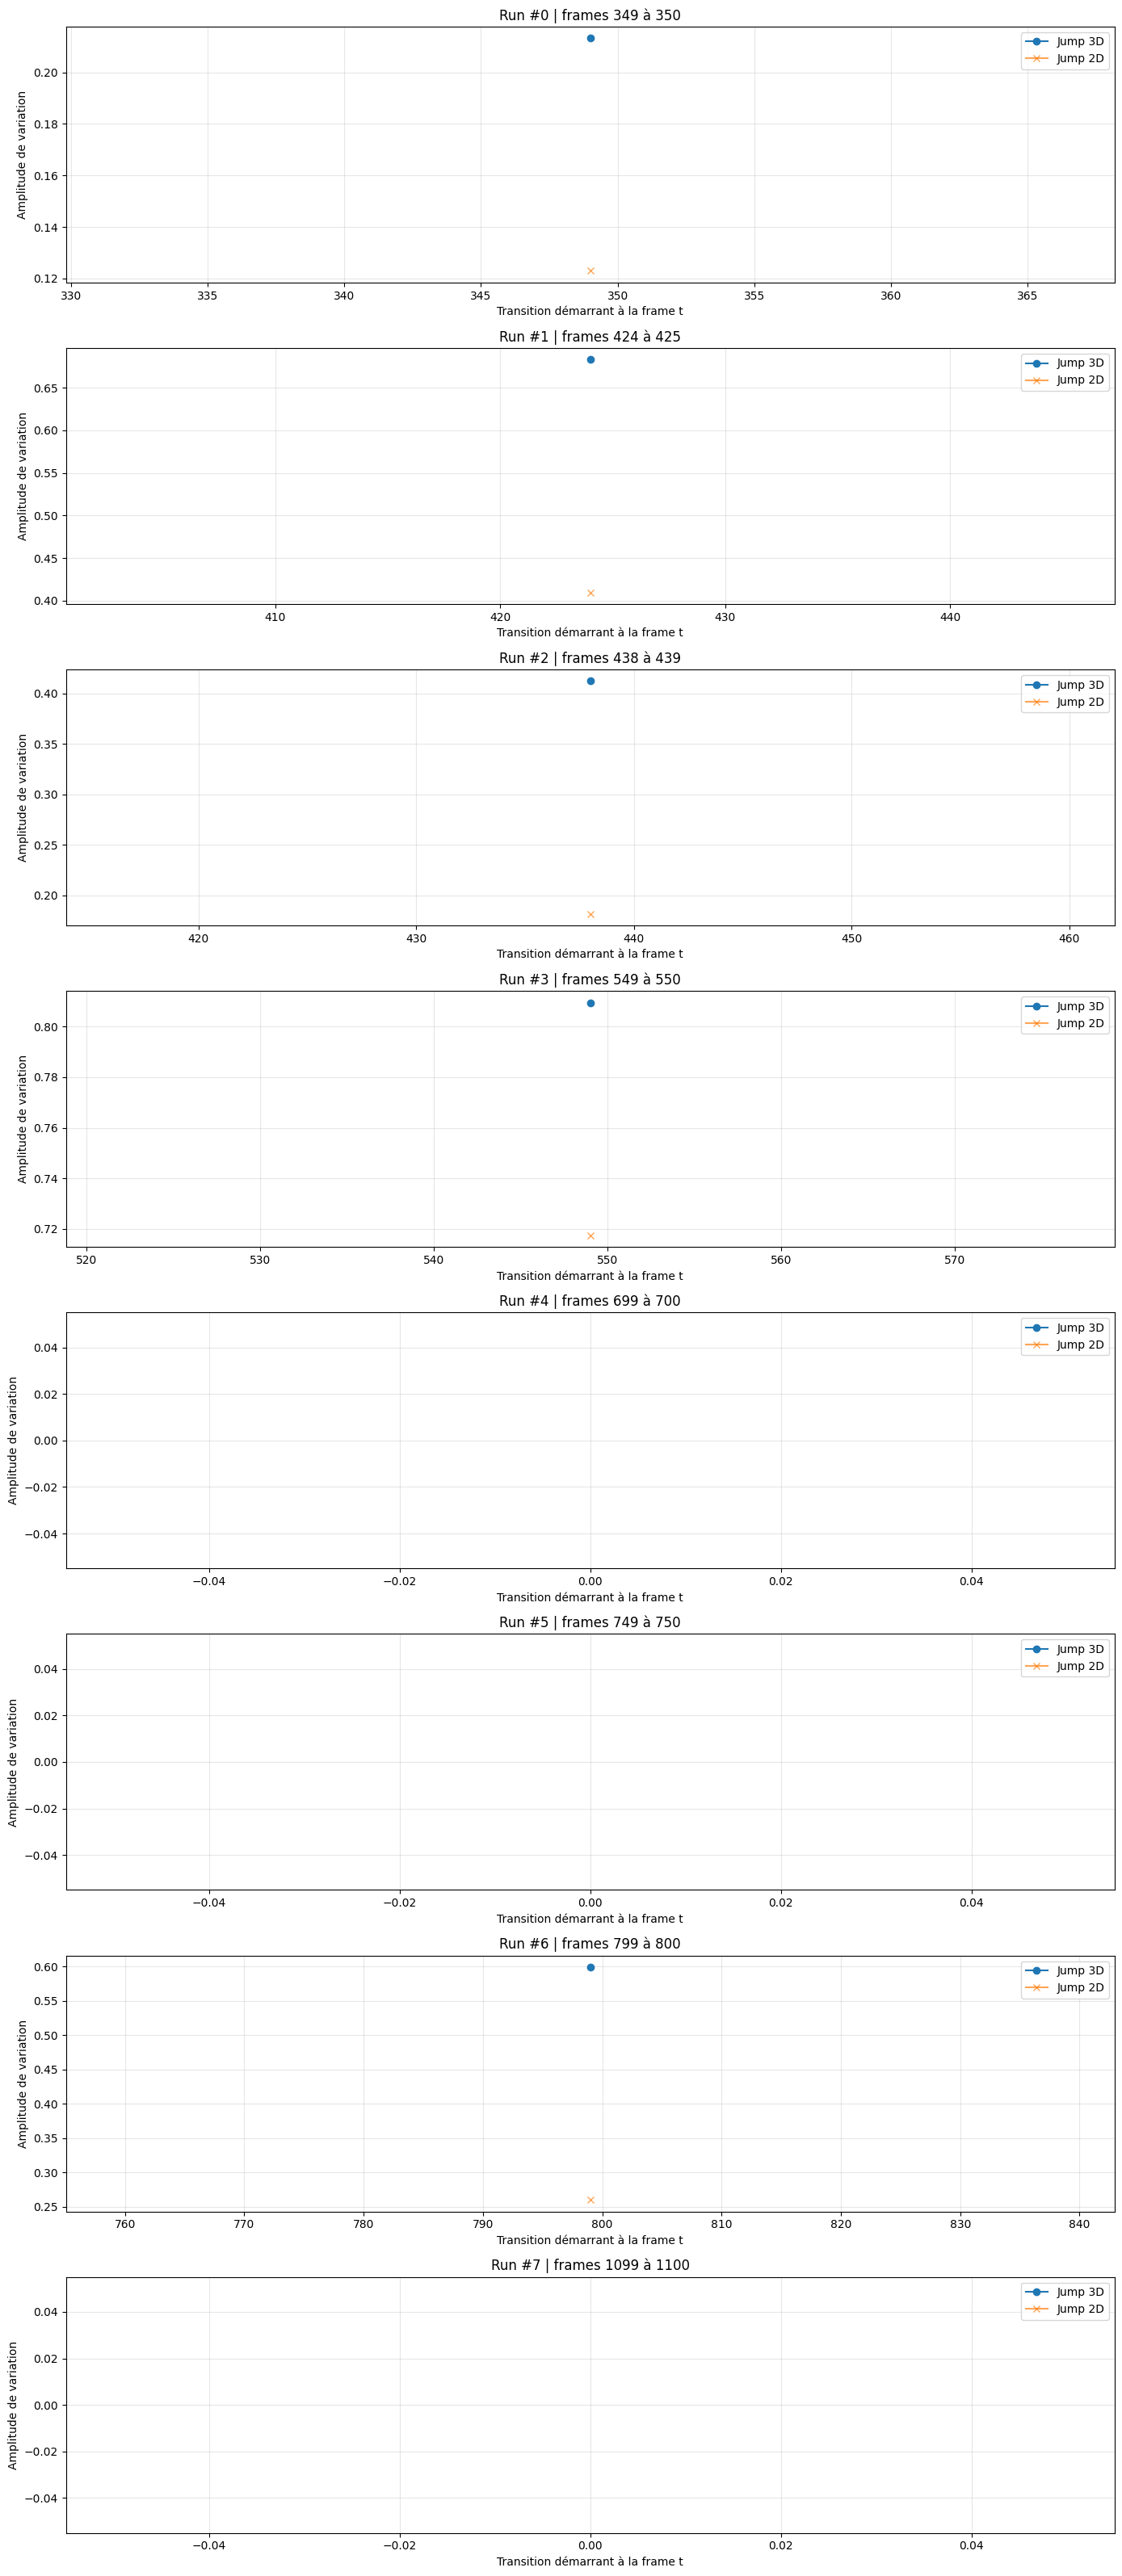


Transition anormale n°1
Run #3 | 549 -> 550
Score 3D      : 0.809540
Score 2D      : 0.717363
Validity jump : 0.000000


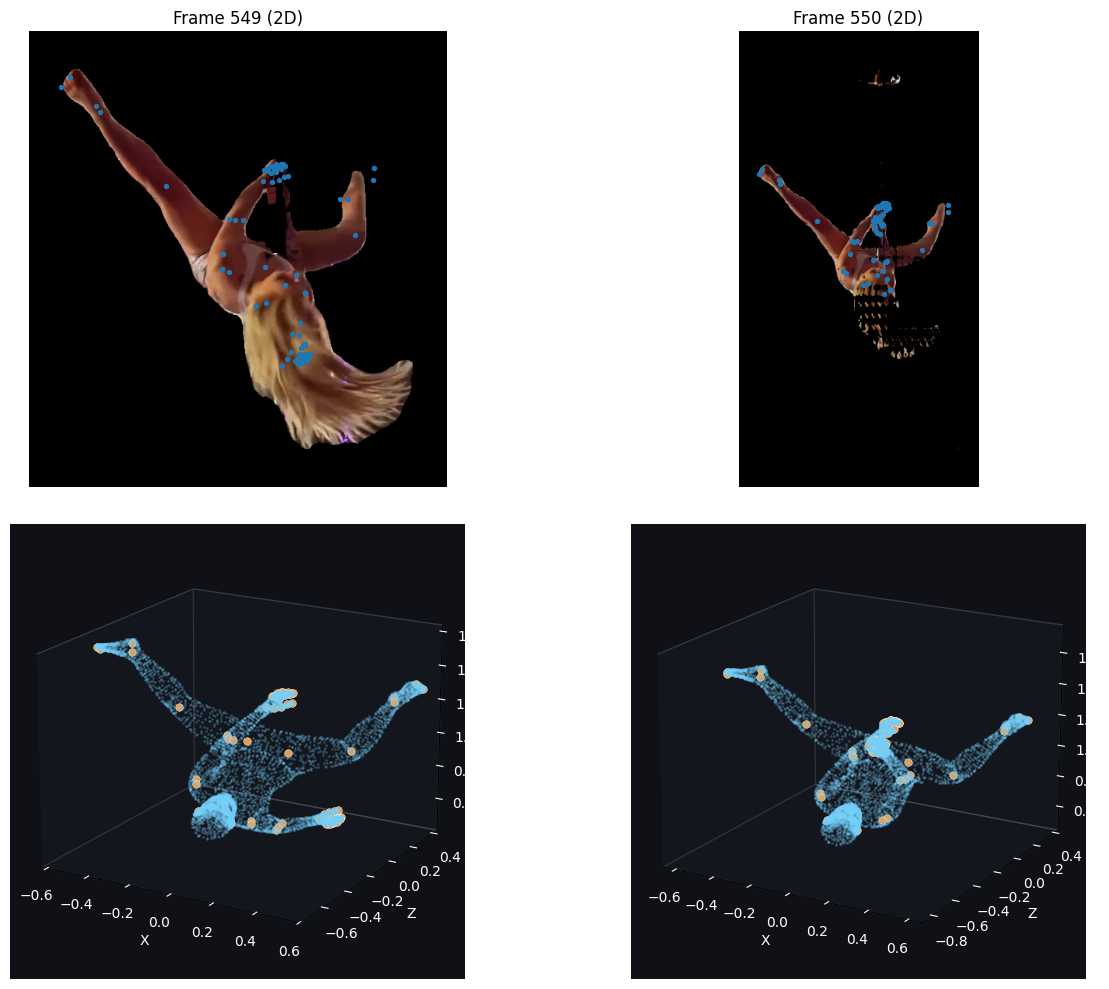


Transition anormale n°2
Run #1 | 424 -> 425
Score 3D      : 0.683053
Score 2D      : 0.409862
Validity jump : 0.000000


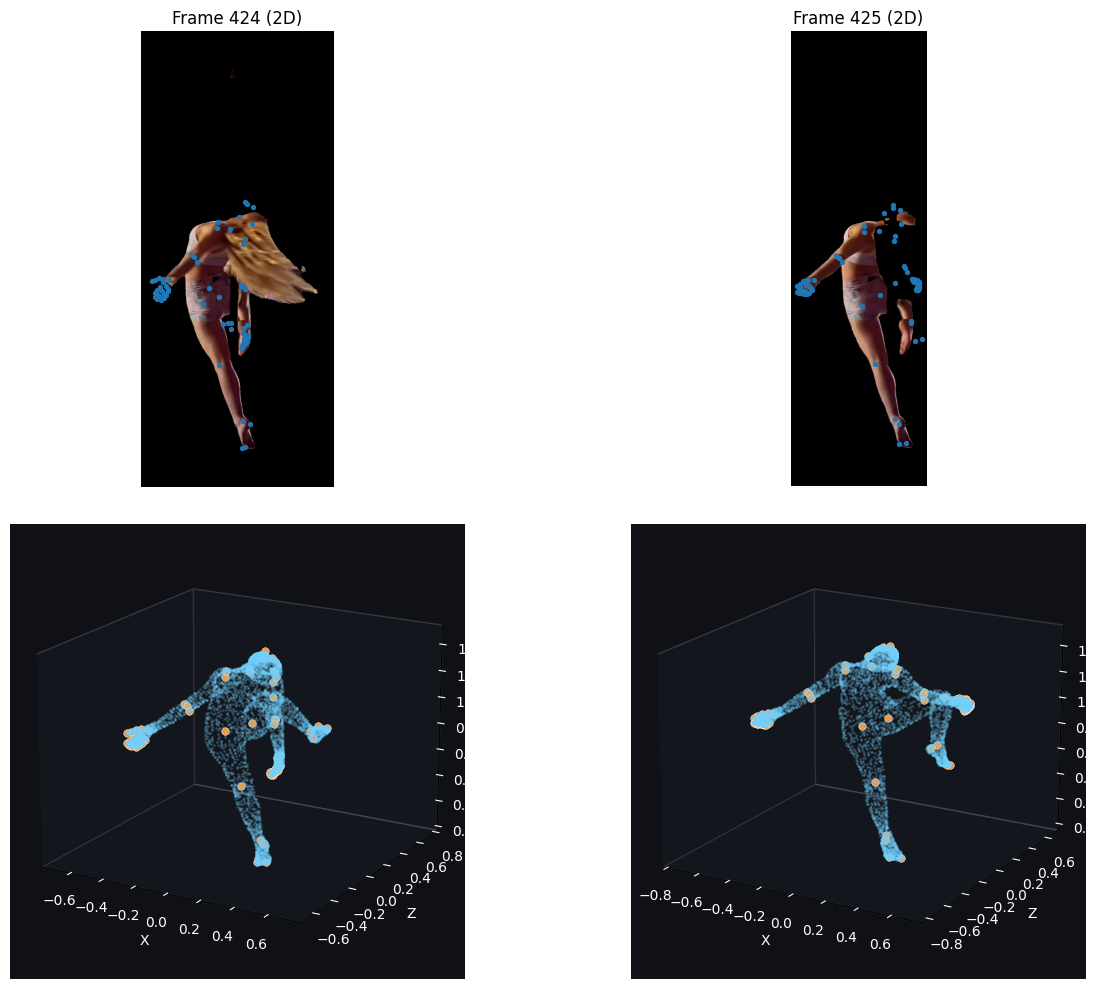


Transition anormale n°3
Run #6 | 799 -> 800
Score 3D      : 0.599298
Score 2D      : 0.260288
Validity jump : 0.000000


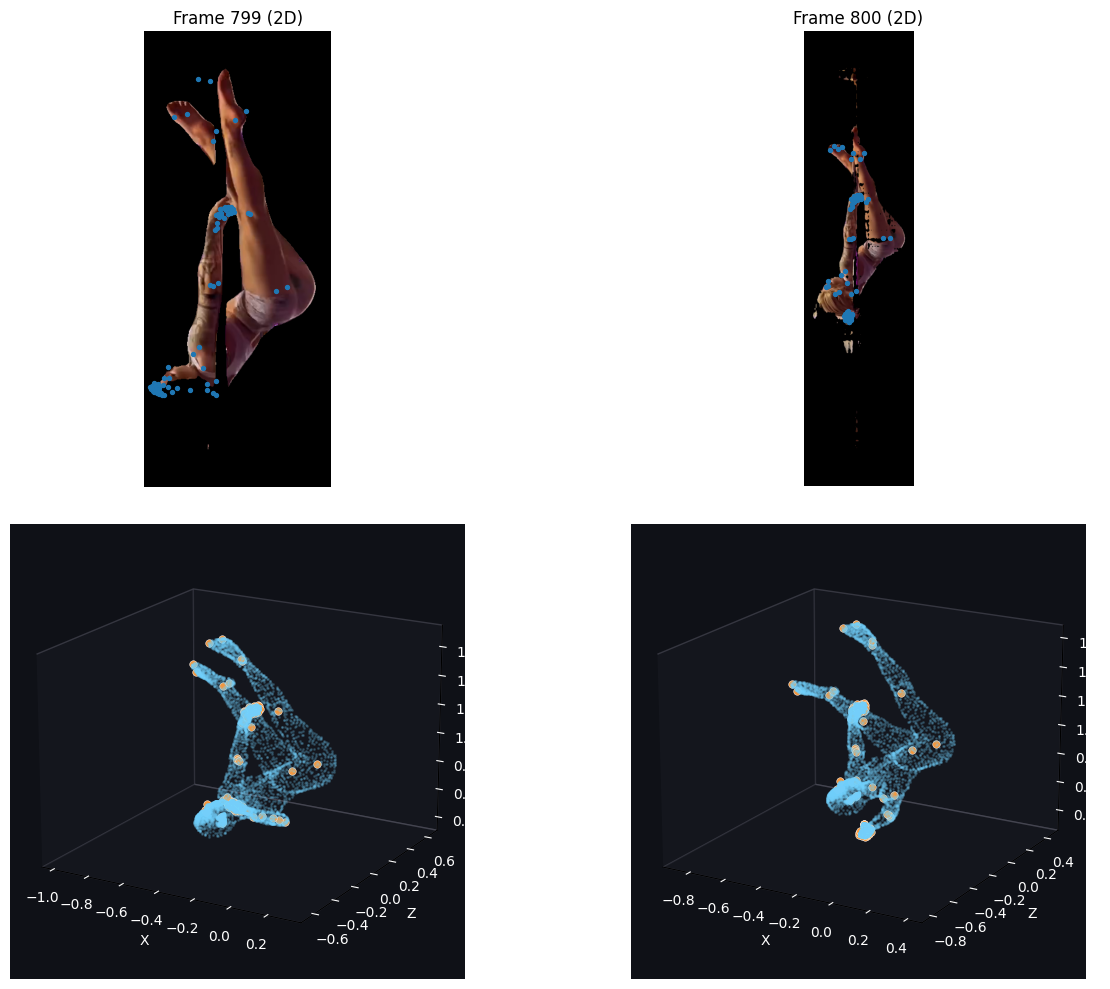


Transition anormale n°4
Run #2 | 438 -> 439
Score 3D      : 0.412146
Score 2D      : 0.181472
Validity jump : 0.000000


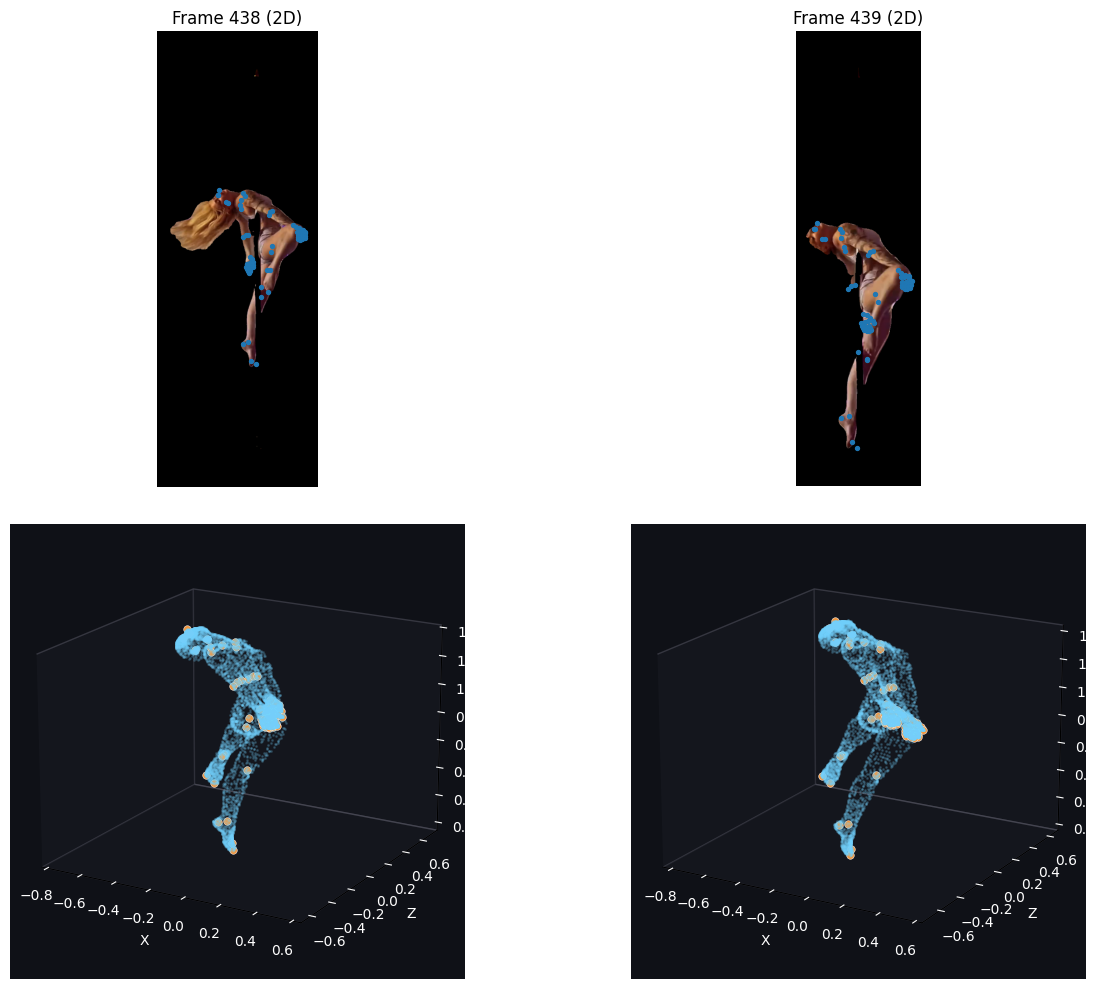


Transition anormale n°5
Run #0 | 349 -> 350
Score 3D      : 0.213290
Score 2D      : 0.122971
Validity jump : 0.000000


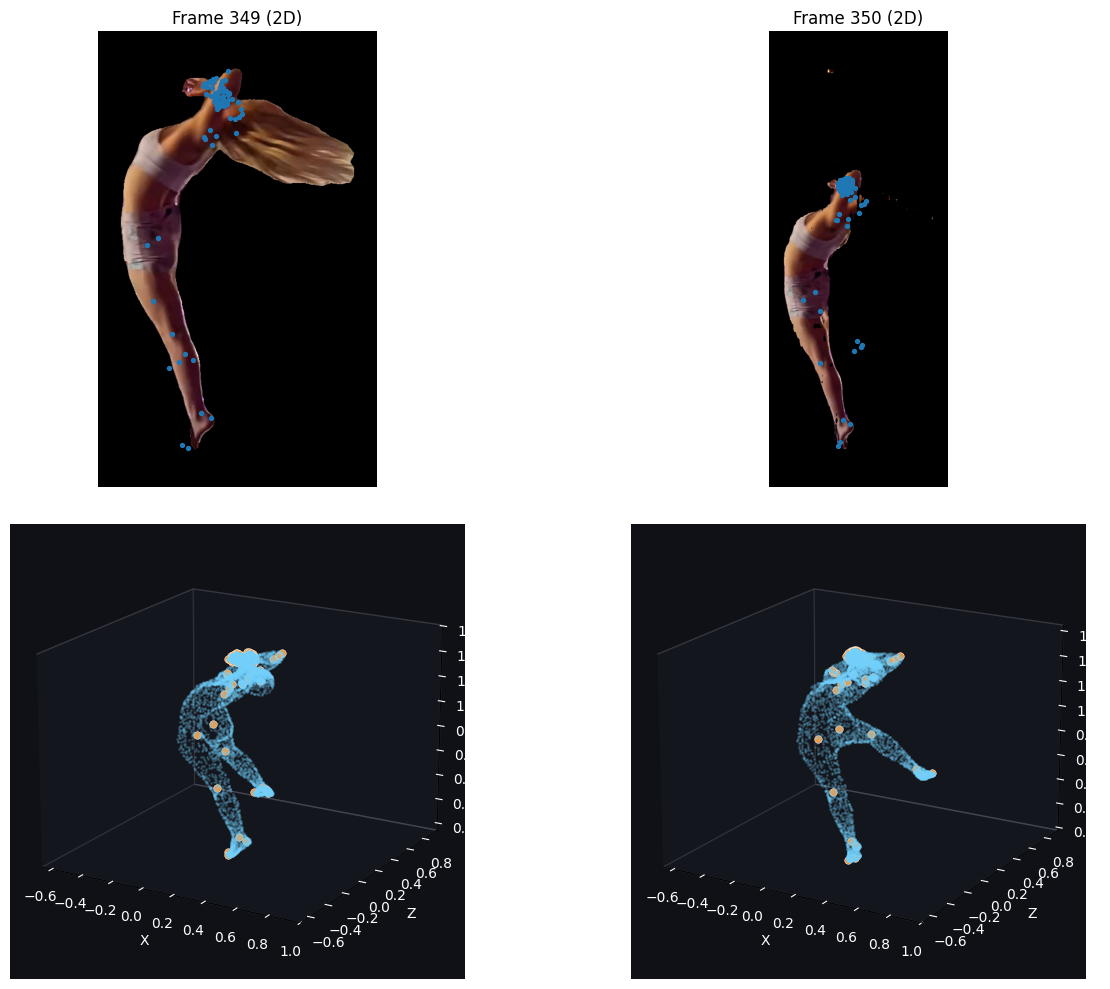

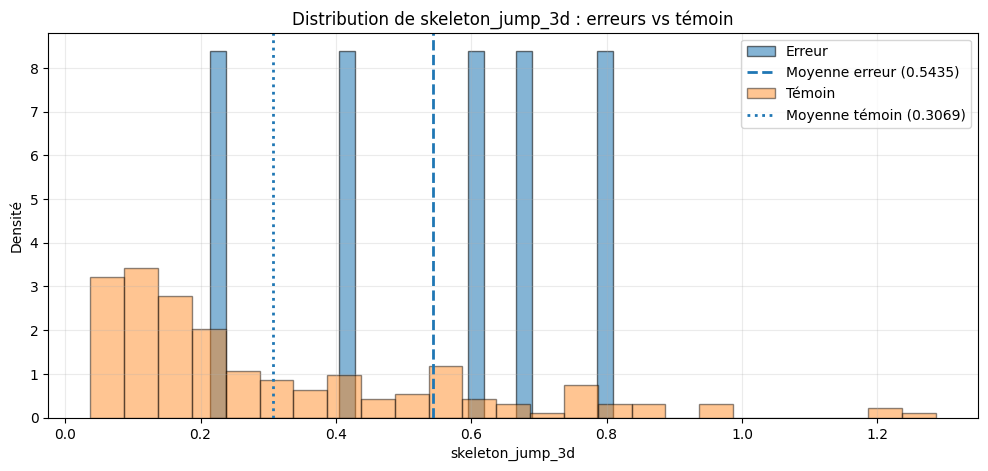

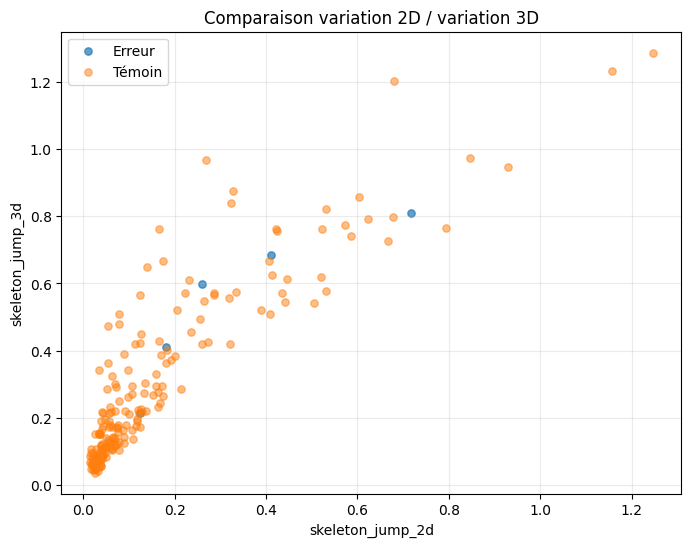

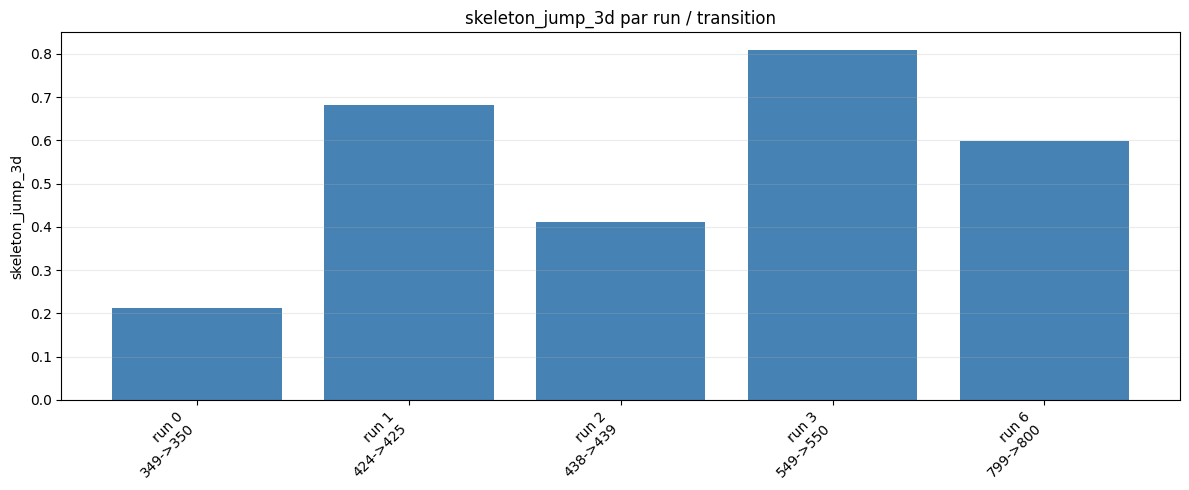

In [ ]:
error_runs_simple = frame_runs_from_transition_indices(bad_frames_simple)

results_simple = run_skeleton_metric_experiment(
    error_runs_simple,
    run_label="simple",
    min_run_length=2,
    num_control_samples=200,
    use_cache=True,
    force_recompute=False,
    show_plots=True,
)

skeleton_transitions_simple = results_simple["skeleton_transitions"]
skeleton_cache_simple = results_simple["skeleton_cache"]
control_skeleton_simple = results_simple["control_skeleton"]
skeleton_summary_simple = results_simple["skeleton_summary"]
skeleton_compare_simple = results_simple["skeleton_compare"]

##### <u>Exécution 3 (via vérité terrain humaine) :</u>

Runs d'erreurs à partir de la vérité terrain humaine.

In [ ]:
ground_truth = load_annotations_csv(ANNOTATIONS_PATH)

if ground_truth is not None:
    error_runs_gt = frame_runs_from_annotations(ground_truth, error_value=0)
else:
    error_runs_gt = []

results_gt = run_skeleton_metric_experiment(
    error_runs_gt,
    run_label="vérité terrain",
    min_run_length=2,
    num_control_samples=200,
    use_cache=True,
    force_recompute=False,
    show_plots=True,
)

skeleton_transitions_gt = results_gt["skeleton_transitions"]
skeleton_cache_gt = results_gt["skeleton_cache"]
control_skeleton_gt = results_gt["control_skeleton"]
skeleton_summary_gt = results_gt["skeleton_summary"]
skeleton_compare_gt = results_gt["skeleton_compare"]

Succès : 1329 frames annotées chargées.
Runs d'erreurs (vérité terrain) : [(0, 0), (50, 50), (57, 57), (70, 71), (73, 76), (100, 100), (108, 108), (117, 117), (128, 129), (150, 150)]
Nombre total de frames à traiter par SAM 3D Body : 477


SAM 3D Body inference:   0%|          | 0/477 [00:00<?, ?it/s]

frame_00070 = cache hit
frame_00071 = cache hit
frame_00073 = cache hit
frame_00074 = cache hit
frame_00075 = cache hit
frame_00076 = cache hit
frame_00128 = cache hit
frame_00129 = cache hit
frame_00239 = cache hit
frame_00240 = cache hit
frame_00241 = cache hit
frame_00242 = cache hit
frame_00243 = cache hit
frame_00244 = cache hit
frame_00329 = cache hit
frame_00330 = cache hit
frame_00350 = cache hit
frame_00351 = cache hit
frame_00352 = cache hit
frame_00353 = no box detected
frame_00354 = cache hit
frame_00355 = cache hit
frame_00356 = cache hit
frame_00357 = cache hit
frame_00358 = cache hit
frame_00359 = cache hit
frame_00360 = cache hit
frame_00361 = cache hit
frame_00362 = cache hit
frame_00363 = cache hit
frame_00364 = cache hit
frame_00365 = cache hit
frame_00366 = cache hit
frame_00367 = cache hit
frame_00368 = cache hit
frame_00369 = cache hit
frame_00370 = cache hit
frame_00371 = cache hit
frame_00372 = cache hit
frame_00373 = cache hit
frame_00374 = cache hit
frame_0037

SAM 3D Body inference:   0%|          | 0/357 [00:00<?, ?it/s]

frame_00001 = Found boxes: [[ 24.44  76.4  292.32 845.03]]
frame_00002 = Found boxes: [[ 27.65  77.06 311.68 850.22]]
frame_00003 = cache hit
frame_00004 = cache hit
frame_00005 = Found boxes: [[ 29.73  77.01 349.19 854.59]]
frame_00006 = cache hit
frame_00011 = Found boxes: [[ 33.31  79.04 371.7  884.11]]
frame_00012 = Found boxes: [[ 31.84  79.48 357.3  886.27]]
frame_00013 = Found boxes: [[ 31.35  78.66 335.2  886.36]]
frame_00014 = Found boxes: [[ 29.62  79.45 313.08 886.28]]
frame_00015 = Found boxes: [[ 26.17  79.05 285.09 890.83]]
frame_00016 = Found boxes: [[ 21.91  81.49 260.92 895.62]]
frame_00020 = cache hit
frame_00021 = cache hit
frame_00023 = Found boxes: [[ 22.34  81.93 266.73 914.5 ]]
frame_00024 = Found boxes: [[ 20.58  83.11 264.16 915.16]]
frame_00027 = Found boxes: [[ 24.16  84.58 268.34 916.64]]
frame_00028 = Found boxes: [[ 24.99  84.76 279.25 916.28]]
frame_00037 = Found boxes: [[ 28.12  84.49 315.03 903.76]]
frame_00038 = cache hit
frame_00039 = cache hit
frame_

### 4. Métrique : Groupes de pixels et distances

...

In [ ]:
...

### 5. Calcul de la fonction de score final

...

In [ ]:
...

---

## VII. Conclusion

Nous avons encore 2 problèmes :
- Les cheuveux de la danseuses ne sont pas tous les temps inclus dans le découpage, il faudra trouver une logique pour les inclure.
- La méthode de replacement de la danseuse est fonctionnelle mais fastidieuse (calcul à la main des points). De plus, elle ne marche que dans le cadre des vidéos de pole dance.
  - Il faudrait donc trouver une méthode "plus générale et plus automatique" pour correctement replacer la danseuse.